# ECON 398 Project Workbook

Authors: *William Clinton Co, Jerrold Huang, Jae Park, Kaiyan Zhang, Irene Berezin*

### Package Loading

In [37]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(haven)
library(lubridate)
library(stargazer)
library(units)
library(broom)
library(sf)
library(fixest)
library(patchwork)
library(lmtest)
library(pscl)
library(vcd)
library(tableone)
library(car)
library(tidyr)
library(knitr)
library(kableExtra)



载入程序包：'kableExtra'


The following object is masked from 'package:dplyr':

    group_rows




### Data Preprocessing (Pulling Data for 2021 Census)

In [2]:
# reading in cancensus data for 2021
census2021 <- read_csv("census2021_raw.csv")|>
    glimpse()


Rows: 1016 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Type
dbl (12): GeoUID, Region Name, Area (sq km), Population, Dwellings, Househol...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1,016
Columns: 13
$ GeoUID                                                                <dbl> …
$ Type                                                                  <chr> …
$ `Region Name`                                                         <dbl> …
$ `Area (sq km)`                                                        <dbl> …
$ Population                                                            <dbl> …
$ Dwellings                                                             <dbl> …
$ Households                                                            <dbl> …
$ `v_CA21_1: Population, 2021`                                          <dbl> …
$ `v_CA21_6: Population density per square kilometre`                   <dbl> …
$ `v_CA21_386: Average age`                                             <dbl> …
$ `v_CA21_906: Median total income of household in 2020 ($)`            <dbl> …
$ `v_CA21_5853: University certificate or diploma above bachelor level` <dbl> …
$ `v_CA21_4410: 

In [3]:
census2021_clean <- census2021|>
    rename(name = `GeoUID`,
        households = Households, 
        dwellings = Dwellings, 
        population =  `v_CA21_1: Population, 2021`,
        population_density = `v_CA21_6: Population density per square kilometre`, 
        region = `Region Name`, 
        area_sq_km = `Area (sq km)`, 
        age =  `v_CA21_386: Average age`, 
        income = `v_CA21_906: Median total income of household in 2020 ($)`,
        education = `v_CA21_5853: University certificate or diploma above bachelor level`,
        immigrant = `v_CA21_4410: Immigrants`)|>
    mutate(immigrant_prop = immigrant/population) |>
    mutate(university_prop = education / population)|>
    mutate(income = income / 100000)|>
    select(name, households, dwellings, population,population_density, area_sq_km, age, income, immigrant_prop, university_prop)|>
    glimpse()

census2021_clean$name <- as.character(census2021_clean$name)

Rows: 1,016
Columns: 10
$ name               <dbl> 59150307, 59150308, 59150309, 59150310, 59150311, 5…
$ households         <dbl> 266, 218, 282, 389, 187, 201, 355, 169, 350, 209, 3…
$ dwellings          <dbl> 297, 229, 299, 411, 202, 218, 368, 177, 369, 221, 3…
$ population         <dbl> 677, 541, 761, 748, 537, 555, 1003, 508, 966, 544, …
$ population_density <dbl> 2263.5, 4936.1, 6800.7, 6837.3, 6637.8, 6372.0, 580…
$ area_sq_km         <dbl> 0.2991, 0.1096, 0.1119, 0.1094, 0.0809, 0.0871, 0.1…
$ age                <dbl> 42.8, 43.0, 43.3, 37.0, 41.0, 40.6, 45.6, 41.4, 42.…
$ income             <dbl> 1.14, 1.14, 0.94, 0.67, 0.92, 0.96, 0.90, 0.95, 0.8…
$ immigrant_prop     <dbl> 0.2806499, 0.2957486, 0.2759527, 0.2606952, 0.28864…
$ university_prop    <dbl> 0.01477105, 0.04621072, 0.03285151, 0.01336898, 0.0…


### Data Exploration

In [4]:
# Read in the 2016 census data
census2016 <- read_sf("census_index_crime.geojson")|>
    select(- c(crime_count, crime_rate))|>
    rename("university_prop" = "education_prop")|>
    mutate(income = as.double(income),
    immigrant_prop = as.double(immigrant_prop),
    university_prop = as.double(university_prop))|>
    glimpse()

Warning message:
"There were 3 warnings in `stopifnot()`.
The first warning was:
ℹ In argument: `income = as.double(income)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings."


Rows: 993
Columns: 17
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

In [5]:
# Read in the crime data
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, neighbourhood, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2024)|>
    glimpse()

Rows: 351,457
Columns: 6
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ year          <int> 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2014, 2014, 20…
$ month         <int> 3, 8, 4, 8, 7, 11, 1, 4, 9, 1, 11, 11, 3, 6, 9, 6, 2, 2,…
$ name          <int> 59153689, 59153483, 59153483, 59153483, 59153483, 591534…
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


In [6]:

crime_data <- crime_data|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 193,067
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


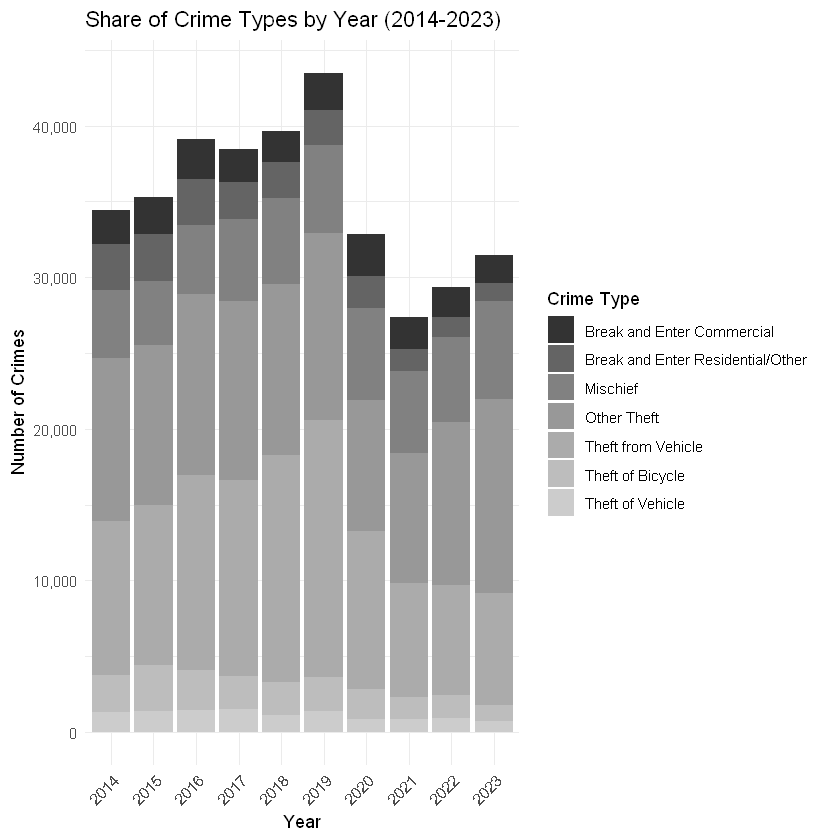

In [7]:
# Visualize the distribution of different types of crimes each year
crime_summary <- crime_data|>
  group_by(year, type)|>
  summarise(total_crimes = sum(crime_count, na.rm = TRUE), .groups = "drop")|>
  ungroup()

# Create the visualization
ggplot(crime_summary, aes(x = factor(year), y = total_crimes, fill = type)) +
  scale_fill_grey() + 
  geom_col(position = "stack") +
  labs(title = "Share of Crime Types by Year (2014-2023)",
       x = "Year",
       y = "Number of Crimes",
       fill = "Crime Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right") +
  scale_y_continuous(labels = scales::comma)

The visualization showed some promise in heterogeneous analysis by different crime types, but let's first focus on crime overall, we remove "Mischief" because it is something not so interesting for our study.

In [8]:
# Create a data summarizing all types of crimes together
crime_trend <- crime_data|>
    filter(type != "Mischief")|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 104,703
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 1, 1, 4, 2, 1, 2, 1, 1, 3, 1, 2, 3, 1, 2, 3, 2, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [9]:
crime_trend_complete <- crime_trend |>
  complete(name, time_category, date = seq.Date(min(date), max(date), by = "month"),
           fill = list(crime_count = 0))|>
           mutate(year = ifelse(is.na(year), year(date), year),
           month = ifelse(is.na(month), month(date), month))|>
           glimpse()


Rows: 238,320
Columns: 6
$ name          <int> 59150307, 59150307, 59150307, 59150307, 59150307, 591503…
$ time_category <chr> "day", "day", "day", "day", "day", "day", "day", "day", …
$ date          <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-05…
$ year          <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6,…
$ crime_count   <int> 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1,…


#### Converting into Panel

In [10]:
neighborhood <- read_sf("Boundary_data/local-area-boundary.geojson")|>
    rename("neighborhood" = "name")|>
    st_sf()

neighborhood_valid <- st_make_valid(neighborhood)
census2016 <- st_make_valid(census2016)


# Compute centroids for census divisions
census2016_centroids <- st_centroid(census2016)

# Perform a spatial join based on whether the census centroid is within the neighborhood boundary
census2016_centroids_joined <- st_join(census2016_centroids, neighborhood_valid[, "neighborhood"], join = st_within)

census2016$neighborhood <- census2016_centroids_joined$neighborhood

glimpse(census2016)

Warning message:
"st_centroid assumes attributes are constant over geometries"


Rows: 993
Columns: 18
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

Warning message:
"package 'ggmap' was built under R version 4.4.2"
ℹ Google's Terms of Service: <https://mapsplatform.google.com>
  Stadia Maps' Terms of Service: <https://stadiamaps.com/terms-of-service/>
  OpenStreetMap's Tile Usage Policy: <https://operations.osmfoundation.org/policies/tiles/>
ℹ Please cite ggmap if you use it! Use `citation("ggmap")` for details.
ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.

ℹ 42 tiles needed, this may take a while (try a smaller zoom?)



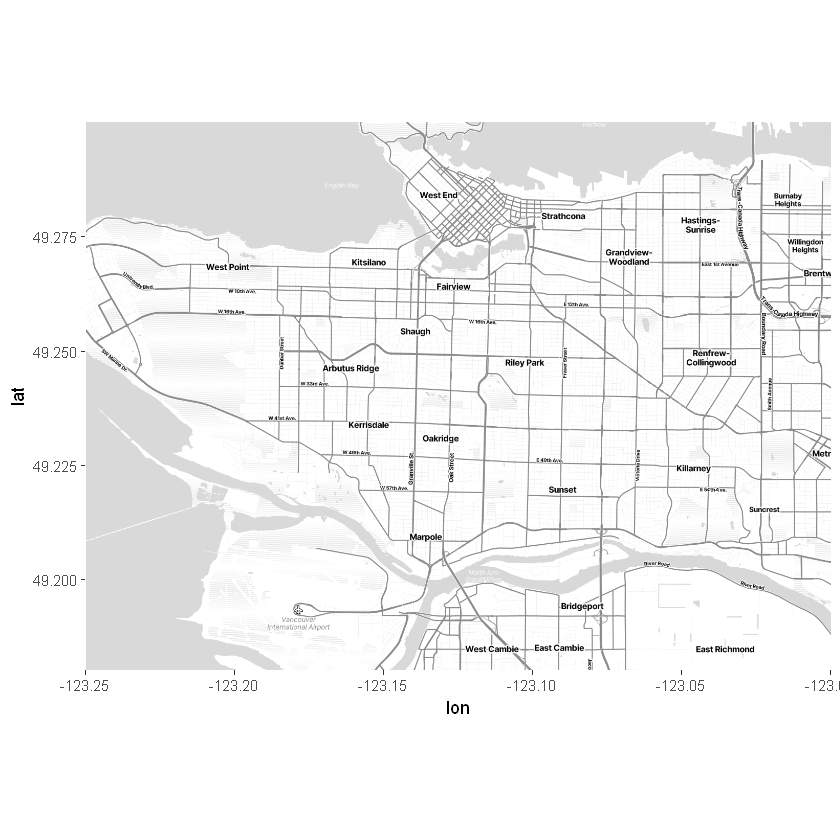

In [11]:
library(ggmap)

key = '953a00a4-1c69-45b1-a0e4-b3492abdf92b'

register_stadiamaps(key, write = FALSE)

bbox <- c(left = -123.25, bottom = 49.18, right = -123.0, top = 49.3)

base <- get_stadiamap(bbox = bbox, zoom = 13, maptype = "stamen_toner_lite", filetype = "svg")
ggmap(base)

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


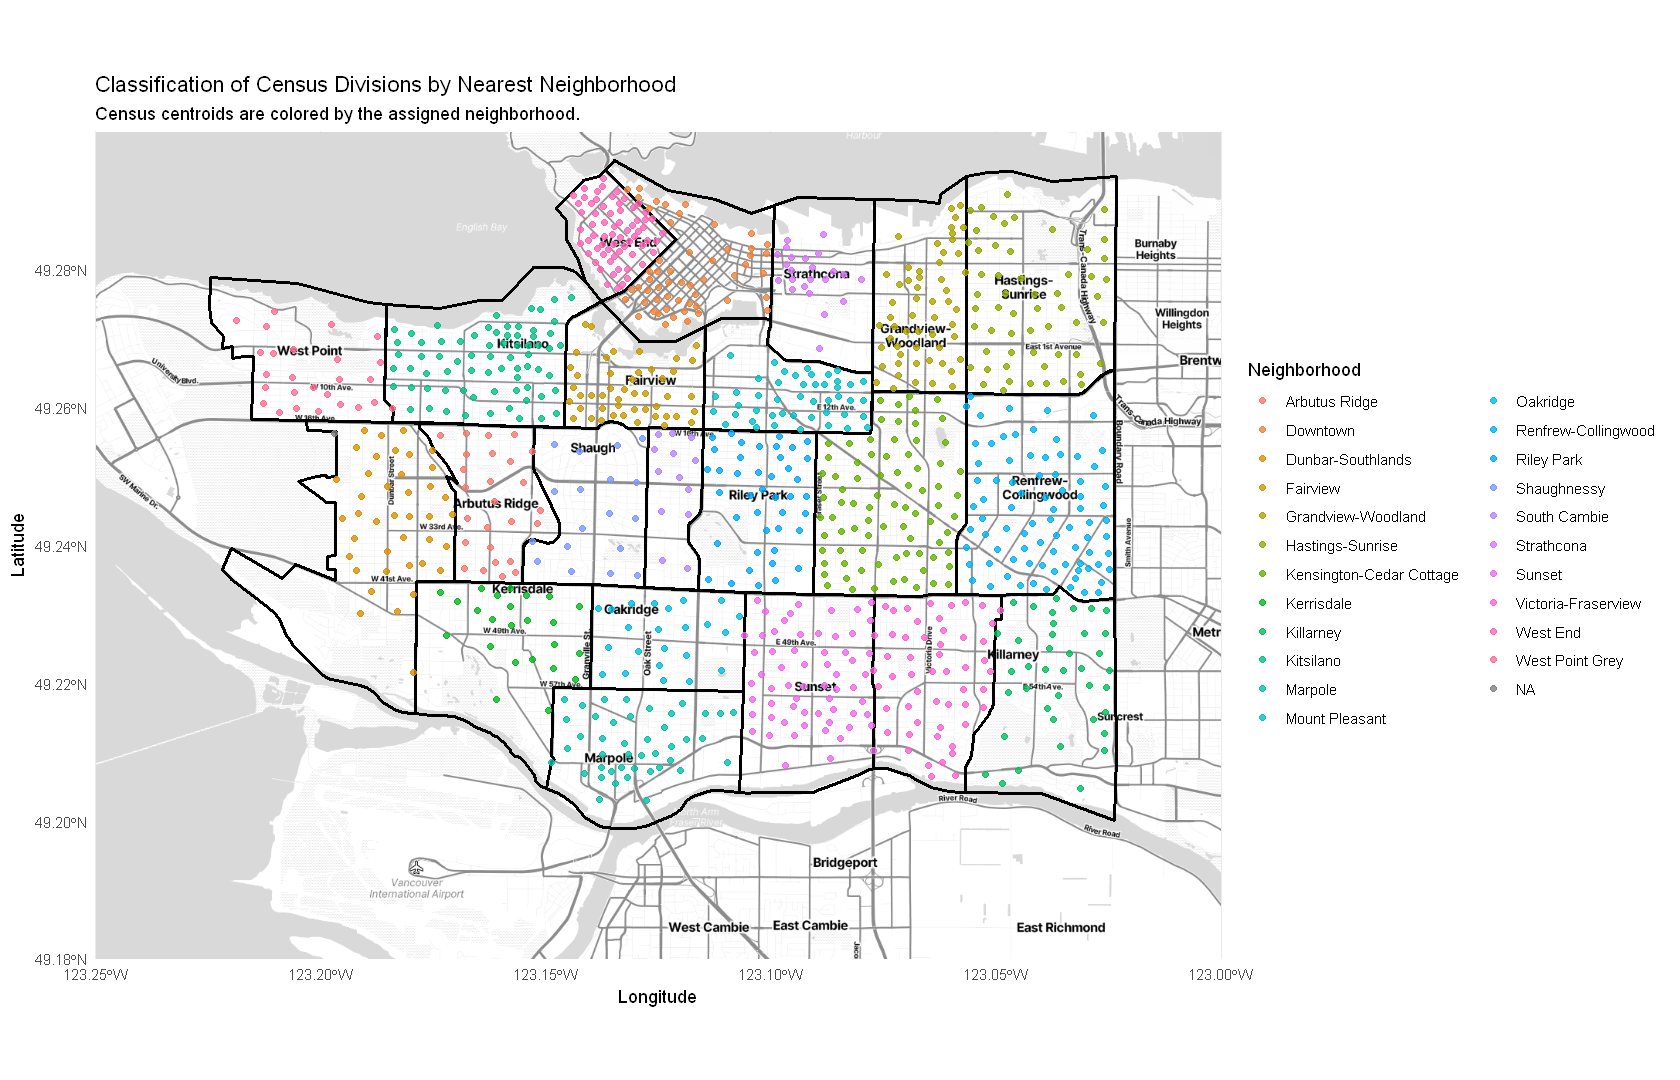

In [12]:
census2016_centroids <- census2016_centroids %>%
  mutate(neighborhood = census2016$neighborhood)

neighborhood_valid <- st_transform(neighborhood_valid, 4326)
census2016_centroids <- st_transform(census2016_centroids, 4326)

options(repr.plot.width = 14, repr.plot.height = 9)

# Create the plot of neighborhood
ggmap(base) +
  geom_sf(data = neighborhood_valid, inherit.aes = FALSE, fill = NA, color = "black", lwd = 1) +
  geom_sf(data = census2016_centroids,inherit.aes = FALSE, aes(color = neighborhood), size = 1.5, alpha = 0.8) +
  coord_sf(crs = st_crs(4326)) +
  labs(title = "Classification of Census Divisions by Nearest Neighborhood",
       subtitle = "Census centroids are colored by the assigned neighborhood.",
       color = "Neighborhood",
       x = "Longitude", y = "Latitude") +
  theme_minimal()

In [13]:
census2016_panel <- merge(census2016, crime_trend_complete, by = "name")|>
    arrange(year, month)|>
    glimpse()

Rows: 238,320
Columns: 23
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <int> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <int> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <int> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <int> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [14]:
census2016_2021_panel <- census2016_panel %>%
  left_join(census2021_clean, by = "name", suffix = c("", ".new")) |>
  mutate(
    # For each variable, if the date is on or after 2019-01-01, use the new (2021) data; otherwise keep the original
    households = if_else(date >= as.Date("2019-01-01"), households.new, households),
    dwellings = if_else(date >= as.Date("2019-01-01"), dwellings.new, dwellings),
    population = if_else(date >= as.Date("2019-01-01"), population.new, population),
    population_density = if_else(date >= as.Date("2019-01-01"), population_density.new, population_density),
    area_sq_km = if_else(date >= as.Date("2019-01-01"), area_sq_km.new, area_sq_km),
    age = if_else(date >= as.Date("2019-01-01"), age.new, age),
    income = if_else(date >= as.Date("2019-01-01"), income.new, income),
    immigrant_prop = if_else(date >= as.Date("2019-01-01"), immigrant_prop.new, immigrant_prop),
    university_prop = if_else(date >= as.Date("2019-01-01"), university_prop.new, university_prop)
  ) |>
  select(-ends_with(".new"))|>
  glimpse()


Rows: 238,320
Columns: 23
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [15]:
select <- dplyr::select

In [16]:


# Read in the NASA NTL data
ntl_data <- read_csv("NTL_data/NASA_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    select(!c(population, population_density))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    glimpse()

ntl_data$name <- as.character(ntl_data$name)

Rows: 154908 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (7): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 141,792
Columns: 6
$ name               <dbl> 59150307, 59150309, 59150311, 59150313, 59150328, 5…
$ ntl_mean           <dbl> 3.710000, 3.020000, 3.971038, 4.609642, 4.880000, 4…
$ n_pixels           <dbl> 5, 4, 4, 4, 3, 8, 4, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ n_non_na_pixels    <dbl> 1, 1, 2, 2, 1, 4, 4, 3, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ prop_non_na_pixels <dbl> 0.2000000, 0.2500000, 0.5000000, 0.5000000, 0.33333…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [17]:
sum(census2016_2021_panel$crime_count == 0)

[1] 133617

In [18]:
# Merge 2 dataframes
census2016_2021_panel <- census2016_2021_panel|>
    left_join(ntl_data, by = c("name", "date"))|>
    glimpse()

Rows: 238,320
Columns: 27
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [19]:
crime_summary <- census2016_2021_panel|>
    st_drop_geometry()|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
1.249324,22.24452,0,198


Since the crime data is highly volatile and affected by a lot of empty bins, and apparently it has a much larger variance comparing to its mean value. So instead of using the raw variable, we would employ a negative binomial regression to find its expected value given fixed effects of year, month, division, time_category, and we are using population density as an offset variable. 

In [20]:
census2016_2021_panel <- census2016_2021_panel|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    glimpse()

Rows: 238,320
Columns: 28
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [21]:
census2016_2021_panel <- census2016_2021_panel|>
    filter(!is.na(population_density), !is.na(year), !is.na(month), !is.na(time_category), !is.na(neighborhood))|>
    glimpse()

Rows: 234,600
Columns: 28
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

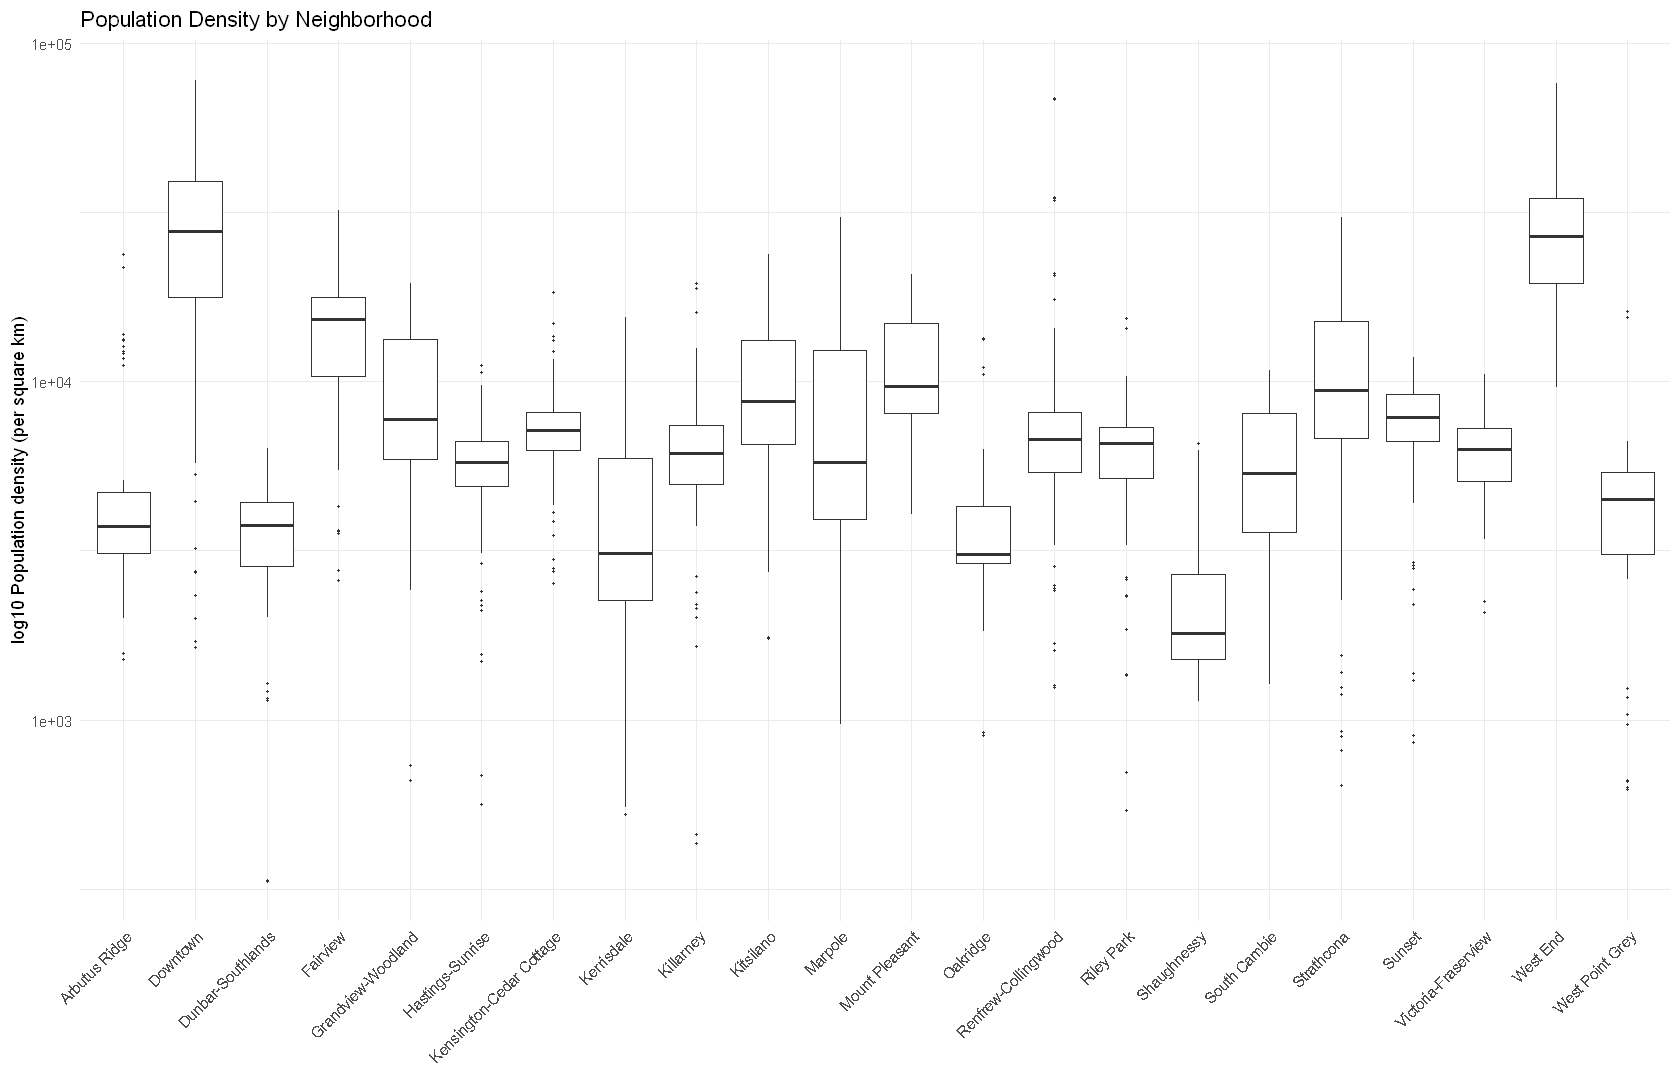

In [22]:
populationDensityDBC <- ggplot(census2016_2021_panel,
             aes(x = neighborhood, y = population_density)) +
  geom_boxplot(outlier.size = 0.5) +
  scale_y_log10() +
  labs(title = "Population Density by Neighborhood",
       x = NULL, y = "log10 Population density (per square km)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

  populationDensityDBC

Warning message:
"Removed 1080 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


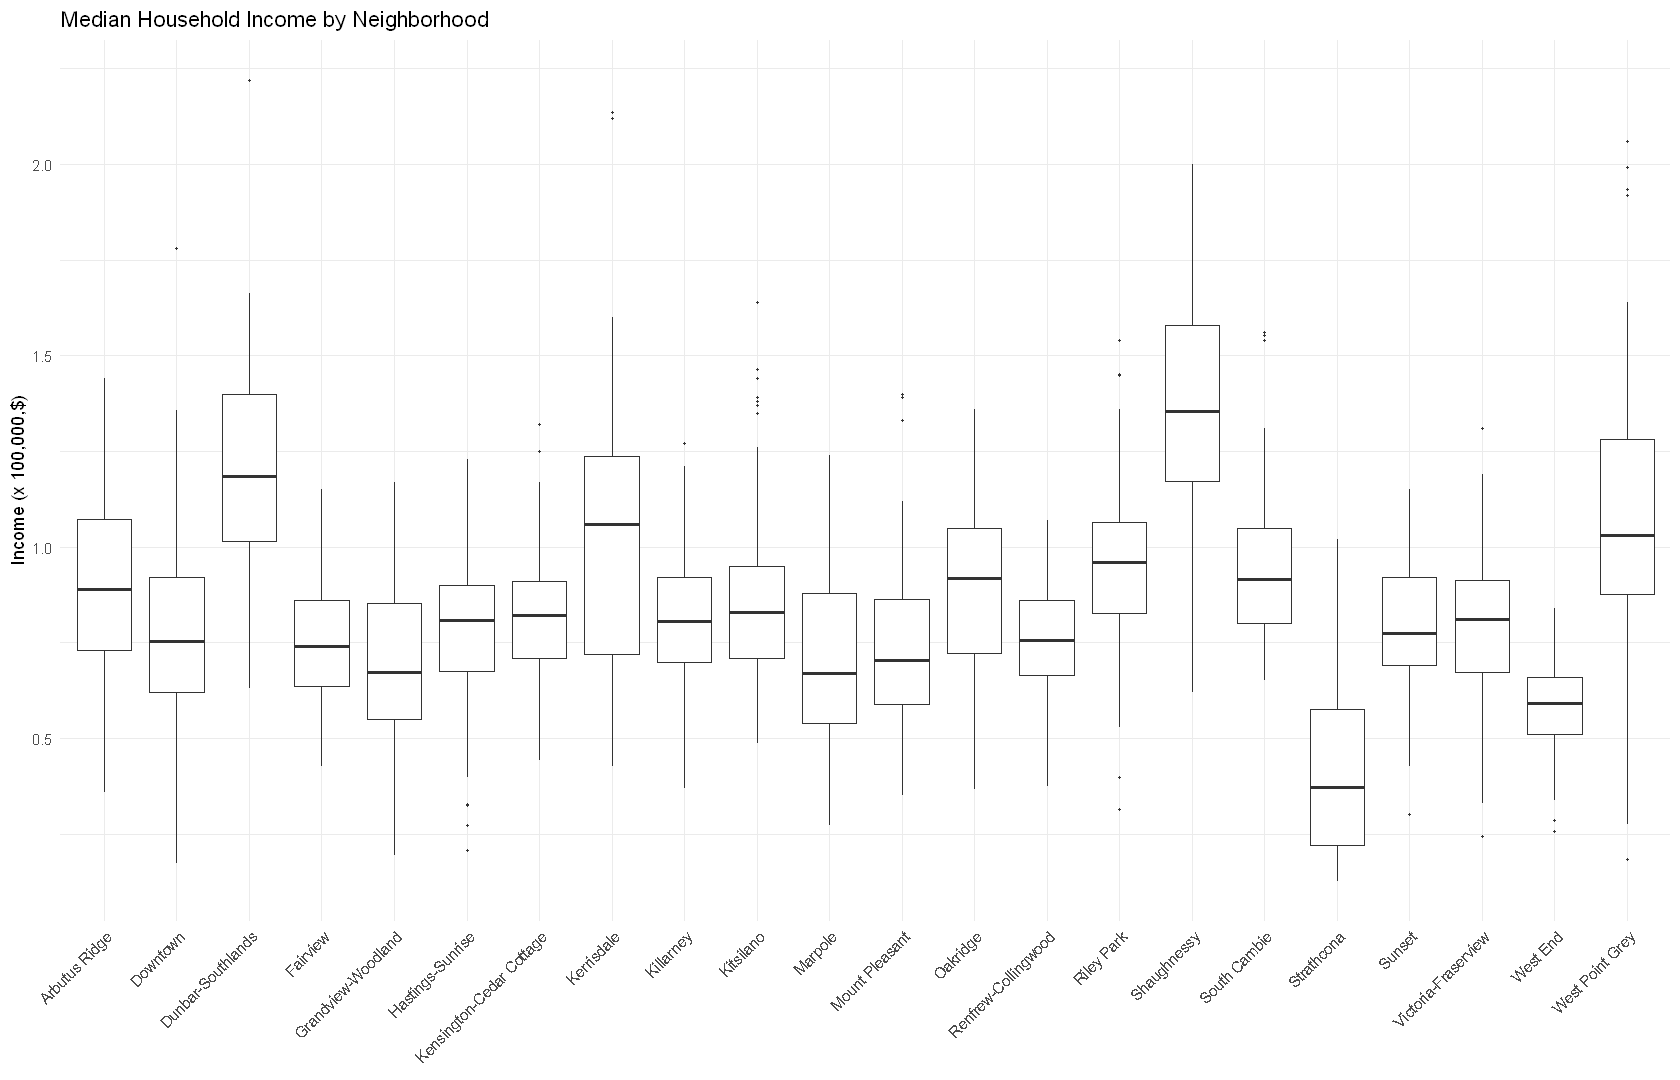

In [23]:
incomeDBC <- ggplot(census2016_2021_panel,
             aes(x = neighborhood, y = income)) +
  geom_boxplot(outlier.size = 0.5) +
  labs(title = "Median Household Income by Neighborhood",
       x = NULL, y = "Income (x 100,000,$)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

incomeDBC

Warning message:
"Removed 1080 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


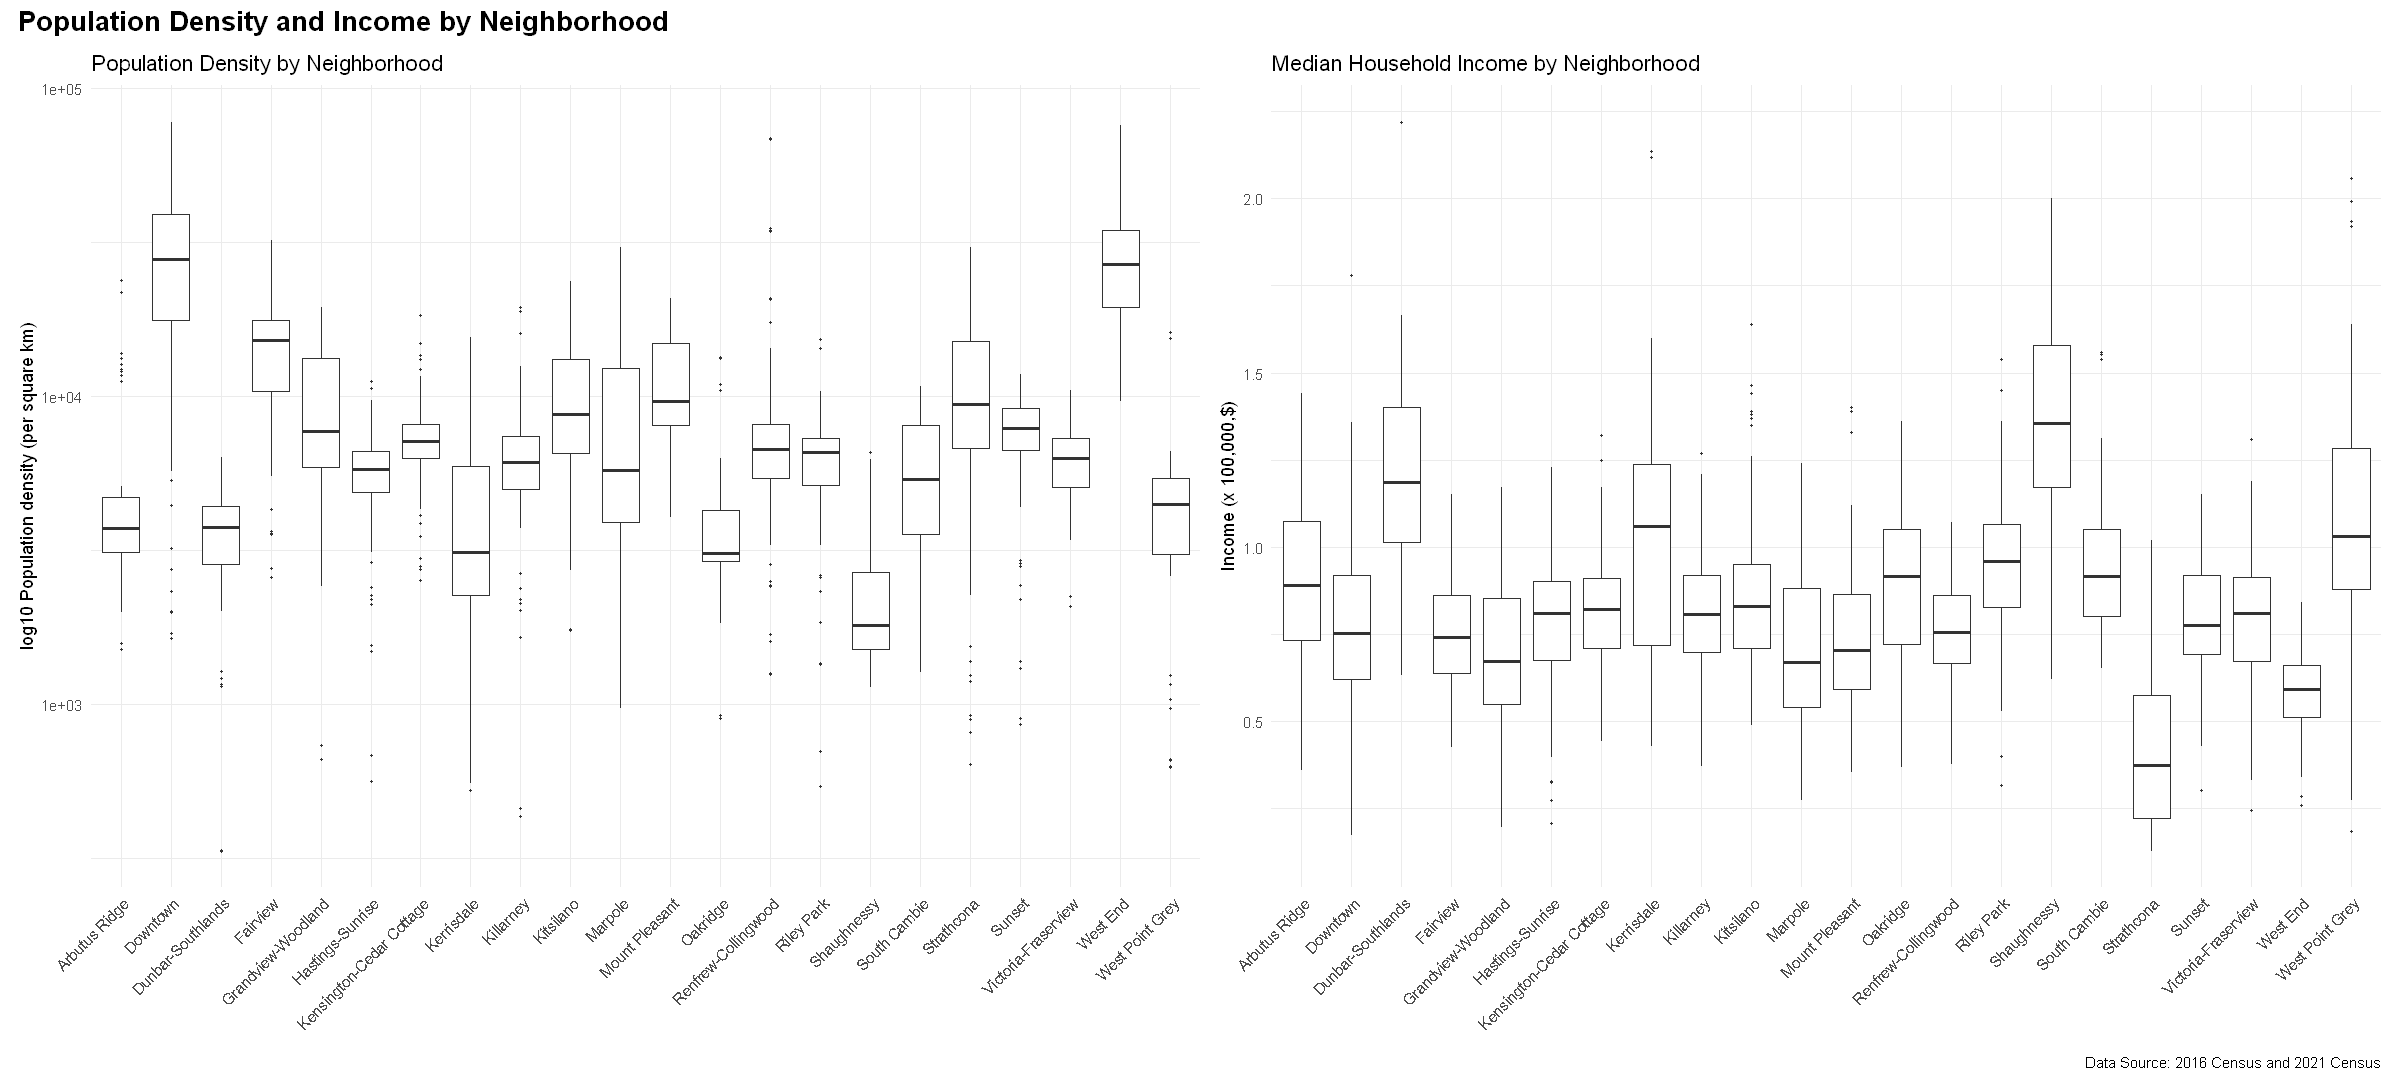

In [24]:
options(repr.plot.width = 20, repr.plot.height = 9)


wrap_plots(populationDensityDBC, incomeDBC, ncol = 2) +
  plot_annotation(title = "Population Density and Income by Neighborhood",
                  theme = theme(plot.title = element_text(size = 16, face = "bold")),
                  caption = "Data Source: 2016 Census and 2021 Census")

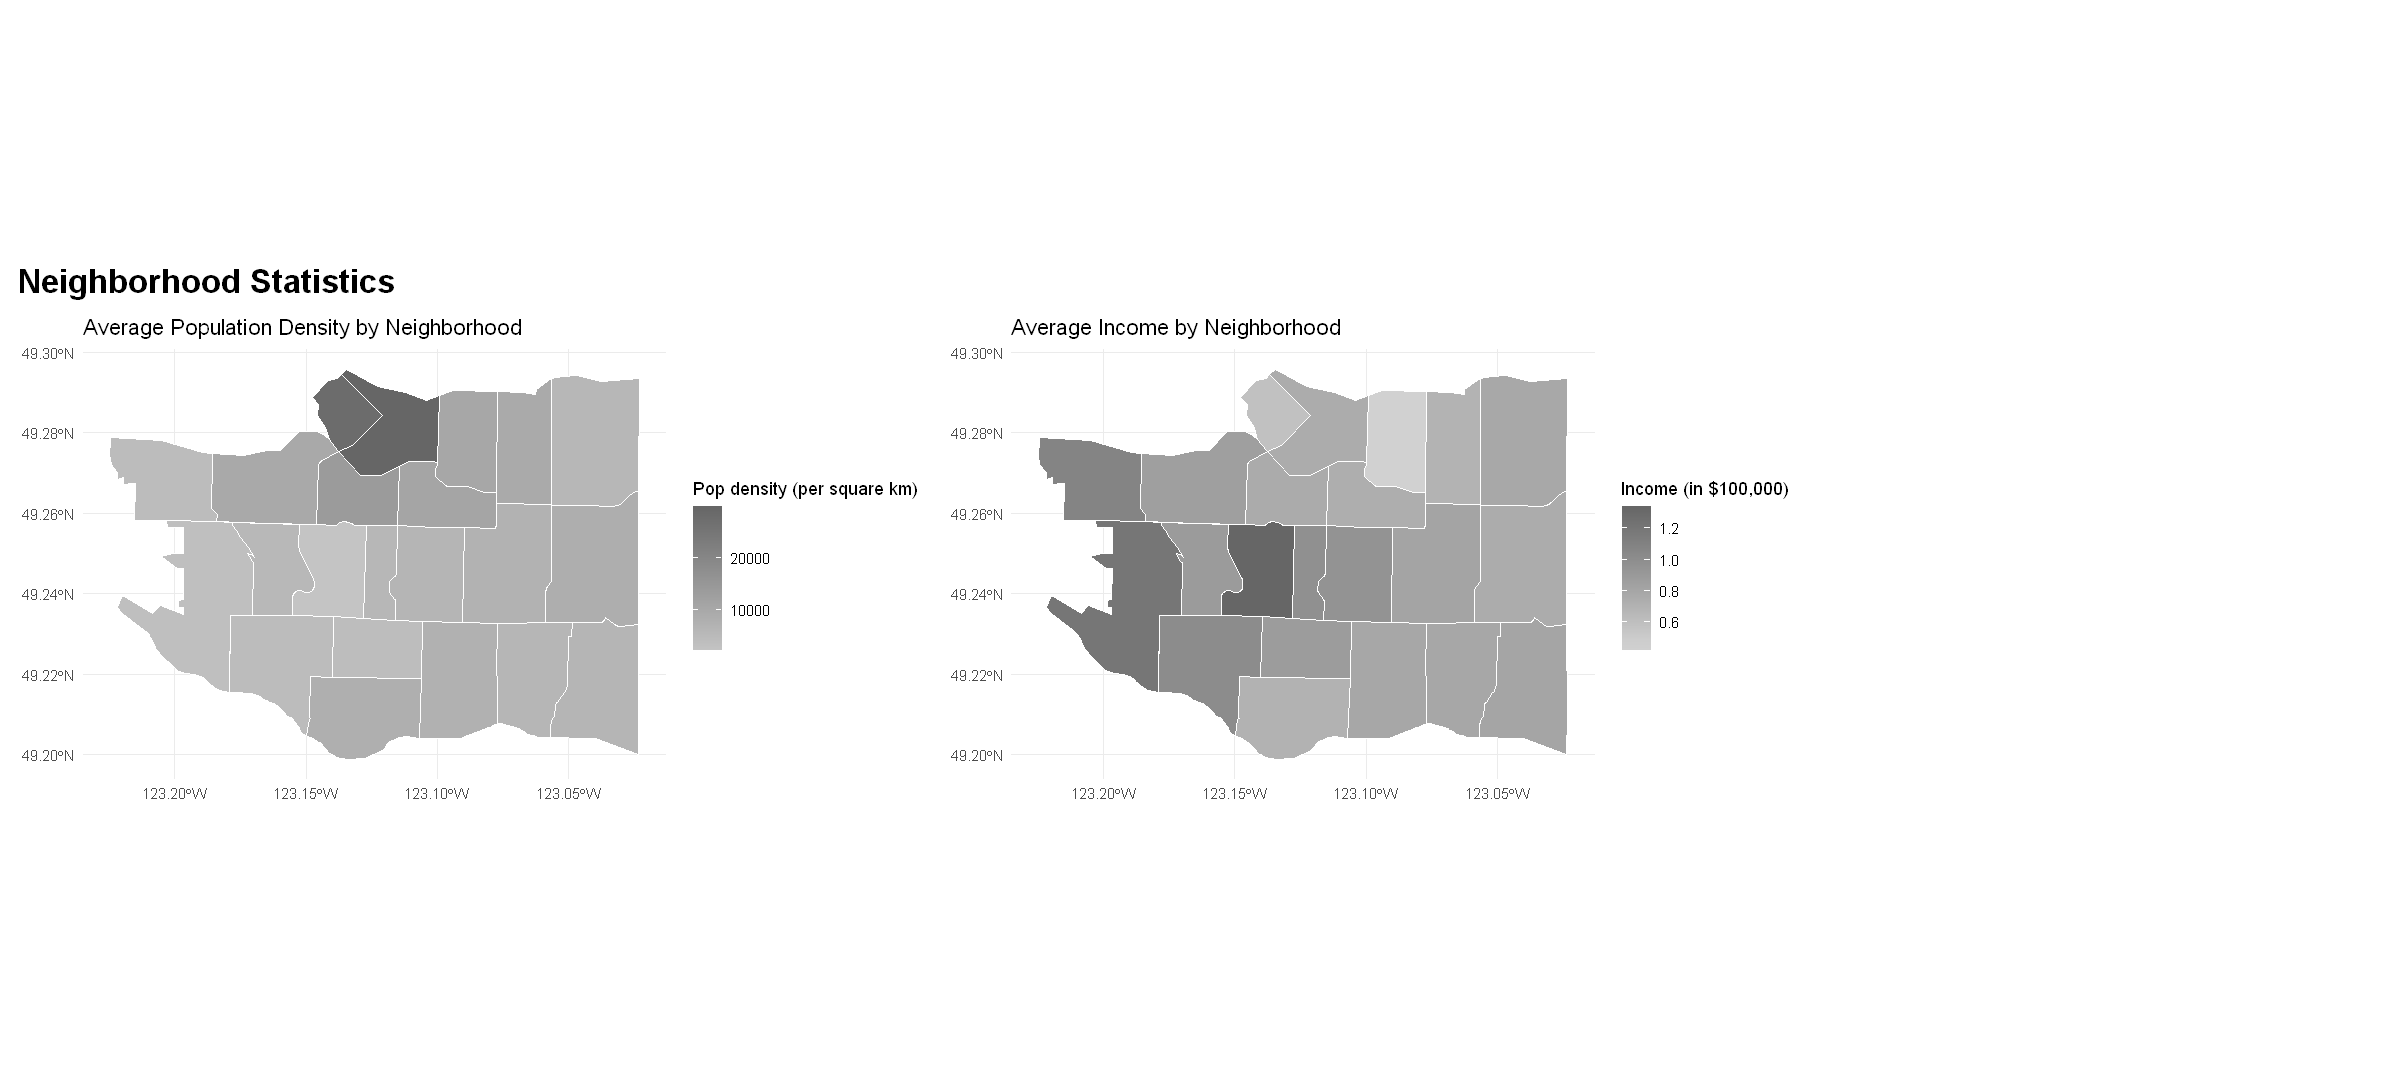

In [25]:
neighborhoodStats <- census2016_2021_panel %>%
  st_drop_geometry() %>%
  group_by(neighborhood) %>%
  summarize(
    avg_pop_density = mean(population_density, na.rm = TRUE),
    avg_income      = mean(income, na.rm = TRUE),
    prop_downtown   = mean(is_downtown, na.rm = TRUE)
  )

neighborhoodMap <- neighborhood_valid %>%
  left_join(neighborhoodStats, by = "neighborhood")

populationDensityMap <- ggplot(neighborhoodMap) +
  geom_sf(aes(fill = avg_pop_density), color="white", size=0.2) +
  scale_fill_gradient2(midpoint = 0.5, low = "white", mid = "grey80", high = "grey40") +
  labs(
    title = "Average Population Density by Neighborhood",
    fill  = "Pop density (per square km)"
  ) +
  theme_minimal()

incomeMap <- ggplot(neighborhoodMap) +
  geom_sf(aes(fill = avg_income), color="white", size=0.2) +
  scale_fill_gradient2(midpoint = 0.5, low = "white", mid = "grey80", high = "grey40") +
  labs(
    title = "Average Income by Neighborhood",
    fill  = "Income (in $100,000)"
  ) +
  theme_minimal()

donwtownMap <- ggplot(neighborhoodMap) +
  geom_sf(aes(fill = prop_downtown), color="white", size=0.2) +
  scale_fill_gradient2(midpoint = 0.5, low ="grey80", high = "grey40") + 
  labs(
    title = "Proportion of Census Divisions in Downtown",
    fill  = "Proportion"
  ) +
  theme_minimal()

wrap_plots(populationDensityMap, incomeMap, ncol = 3) +
  plot_annotation(title = "Neighborhood Statistics",
                  theme = theme(plot.title = element_text(size = 20, face = "bold")))

In [26]:
# Coverting fixed effects as factors
census2016_2021_panel$name <- as.factor(census2016_2021_panel$name)
census2016_2021_panel$year <- as.factor(census2016_2021_panel$year)
census2016_2021_panel$month <- as.factor(census2016_2021_panel$month)
census2016_2021_panel$time_category <- as.factor(census2016_2021_panel$time_category)
census2016_2021_panel$neighborhood <- as.factor(census2016_2021_panel$neighborhood)

In [ ]:
# Load necessary packages
library(MASS)

### 1. Fit different models

# 1.1 Poisson model (intercept only)
fit_pois <- glm(crime_count ~ 1,
                data = crime_trend_complete,
                family = poisson())

# 1.2 Negative Binomial model
fit_nb <- glm.nb(crime_count ~ 1,
                 data = crime_trend_complete)

# 1.3 Zero-Inflated Poisson (ZIP) model
# Format crime_count ~ 1 | 1 means count part and zero-inflation part only include intercepts
fit_zip <- zeroinfl(crime_count ~ 1 | 1,
                    data = crime_trend_complete,
                    dist = "poisson")

# 1.4 Zero-Inflated Negative Binomial (ZINB) model
fit_zinb <- zeroinfl(crime_count ~ 1 | 1,
                     data = crime_trend_complete,
                     dist = "negbin")

# 1.5 Hurdle Poisson model
fit_hurdle_pois <- hurdle(crime_count ~ 1,
                          data = crime_trend_complete,
                          dist = "poisson")

# 1.6 Hurdle Negative Binomial model
fit_hurdle_nb <- hurdle(crime_count ~ 1,
                        data = crime_trend_complete,
                        dist = "negbin")

### 2. Model comparison
# We use AIC and BIC to evaluate the goodness of fit for each model

model_names <- c("Poisson", "NegBin", "ZIP", "ZINB", "Hurdle_Poisson", "Hurdle_NegBin")
aic_values <- c(AIC(fit_pois),
                AIC(fit_nb),
                AIC(fit_zip),
                AIC(fit_zinb),
                AIC(fit_hurdle_pois),
                AIC(fit_hurdle_nb))
bic_values <- c(BIC(fit_pois),
                BIC(fit_nb),
                BIC(fit_zip),
                BIC(fit_zinb),
                BIC(fit_hurdle_pois),
                BIC(fit_hurdle_nb))

model_comparison <- data.frame(Model = model_names,
                               AIC = aic_values,
                               BIC = bic_values)
print(model_comparison)

### 3. Non-nested model comparison: Vuong test
# Vuong test helps us compare zero-inflated models with their non-zero-inflated counterparts (e.g., ZIP vs Poisson, ZINB vs NegBin)
vuong_zip_pois   <- vuong(fit_zip, fit_pois)
vuong_zinb_nb    <- vuong(fit_zinb, fit_nb)
# We can also compare ZIP with Hurdle Poisson, and ZINB with Hurdle NB
vuong_zip_hurdle <- vuong(fit_zip, fit_hurdle_pois)
vuong_zinb_hurdle<- vuong(fit_zinb, fit_hurdle_nb)

cat("Vuong test: ZIP vs Poisson\n")
print(vuong_zip_pois)

cat("Vuong test: ZINB vs Negative Binomial\n")
print(vuong_zinb_nb)

cat("Vuong test: ZIP vs Hurdle Poisson\n")
print(vuong_zip_hurdle)

cat("Vuong test: ZINB vs Hurdle Negative Binomial\n")
print(vuong_zinb_hurdle)

### 4. View summaries for each model
cat("\nPoisson model summary:\n")
summary(fit_pois)

cat("\nNegative Binomial model summary:\n")
summary(fit_nb)

cat("\nZero-Inflated Poisson model summary (ZIP):\n")
summary(fit_zip)

cat("\nZero-Inflated Negative Binomial model summary (ZINB):\n")
summary(fit_zinb)

cat("\nHurdle Poisson model summary:\n")
summary(fit_hurdle_pois)

cat("\nHurdle Negative Binomial model summary:\n")
summary(fit_hurdle_nb)


Warning message:
"package 'MASS' was built under R version 4.4.2"



Attaching package: 'MASS'


The following object is masked _by_ '.GlobalEnv':

    select


The following object is masked from 'package:patchwork':

    area


The following object is masked from 'package:dplyr':

    select




Based on the result above, we choose to use a negative binomial regression to account for an expected crime.

In [ ]:
# Making necessary changes to the data
census2016_2021_panel_night <- census2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(year = as.factor(year))|>
    mutate(neighborhood = as.factor(neighborhood))|>
    mutate(income = as.numeric(income), immigrant_prop = as.numeric(immigrant_prop), university_prop = as.numeric(university_prop))|>
    mutate(is_downtown = ifelse(is.na(is_downtown), 0, is_downtown))|>
    filter(!is.na(income), !is.na(university_prop), !is.na(immigrant_prop))|>
    dplyr::select(-time_category)|>
    st_drop_geometry()|>
    glimpse()

Rows: 117,000
Columns: 26
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,~
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,~
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,~
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506~
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6~
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver~
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08~
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510~
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74~
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404~
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253~
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,~
$ light_index 

In [ ]:
# Adding day crime as a control
census2016_2021_panel_day <- census2016_2021_panel|>
    filter(time_category == "day")|>
    rename(day_crime_count = crime_count)|>
    dplyr::select(name, date, day_crime_count)|>
    st_drop_geometry()

census2016_2021_panel_night <- census2016_2021_panel_night|>
    left_join(census2016_2021_panel_day, by = c("name", "date"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    glimpse()

Rows: 117,000
Columns: 27
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,~
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,~
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,~
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506~
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6~
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver~
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08~
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510~
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74~
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404~
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253~
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,~
$ light_index 

In [ ]:
# Implementing the negative binomial regression
library(MASS)
model_nb <- glm.nb(crime_count ~ name + year + month + offset(log(population_density)),
                            data = census2016_2021_panel_night)

# Summarize the fitted model to inspect the results
summary(model_nb)


Attaching package: 'MASS'


The following object is masked _by_ '.GlobalEnv':

    select


The following object is masked from 'package:patchwork':

    area


The following object is masked from 'package:dplyr':

    select




In [ ]:
census2016_2021_panel_night$expected_crime <- predict(model_nb, type = "response")

glimpse(census2016_2021_panel_night)

Rows: 117,000
Columns: 28
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [ ]:
# Implementing the negative binomial regression
model_nb_day <- glm.nb(day_crime_count ~ name + year + month + offset(log(population_density)),
                            data = census2016_2021_panel_night)

# Summarize the fitted model to inspect the results
summary(model_nb_day)

In [ ]:
census2016_2021_panel_night$expected_day_crime <- predict(model_nb_day, type = "response")

glimpse(census2016_2021_panel_night)

Rows: 117,000
Columns: 29
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [ ]:
summary(census2016_2021_panel_night$expected_crime)
summary(census2016_2021_panel_night$expected_day_crime)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
  0.08399   0.50293   0.73476   1.38060   1.14057 128.50900 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
  0.02545   0.21987   0.34415   0.91956   0.61806 128.44451 

`geom_smooth()` using formula = 'y ~ x'


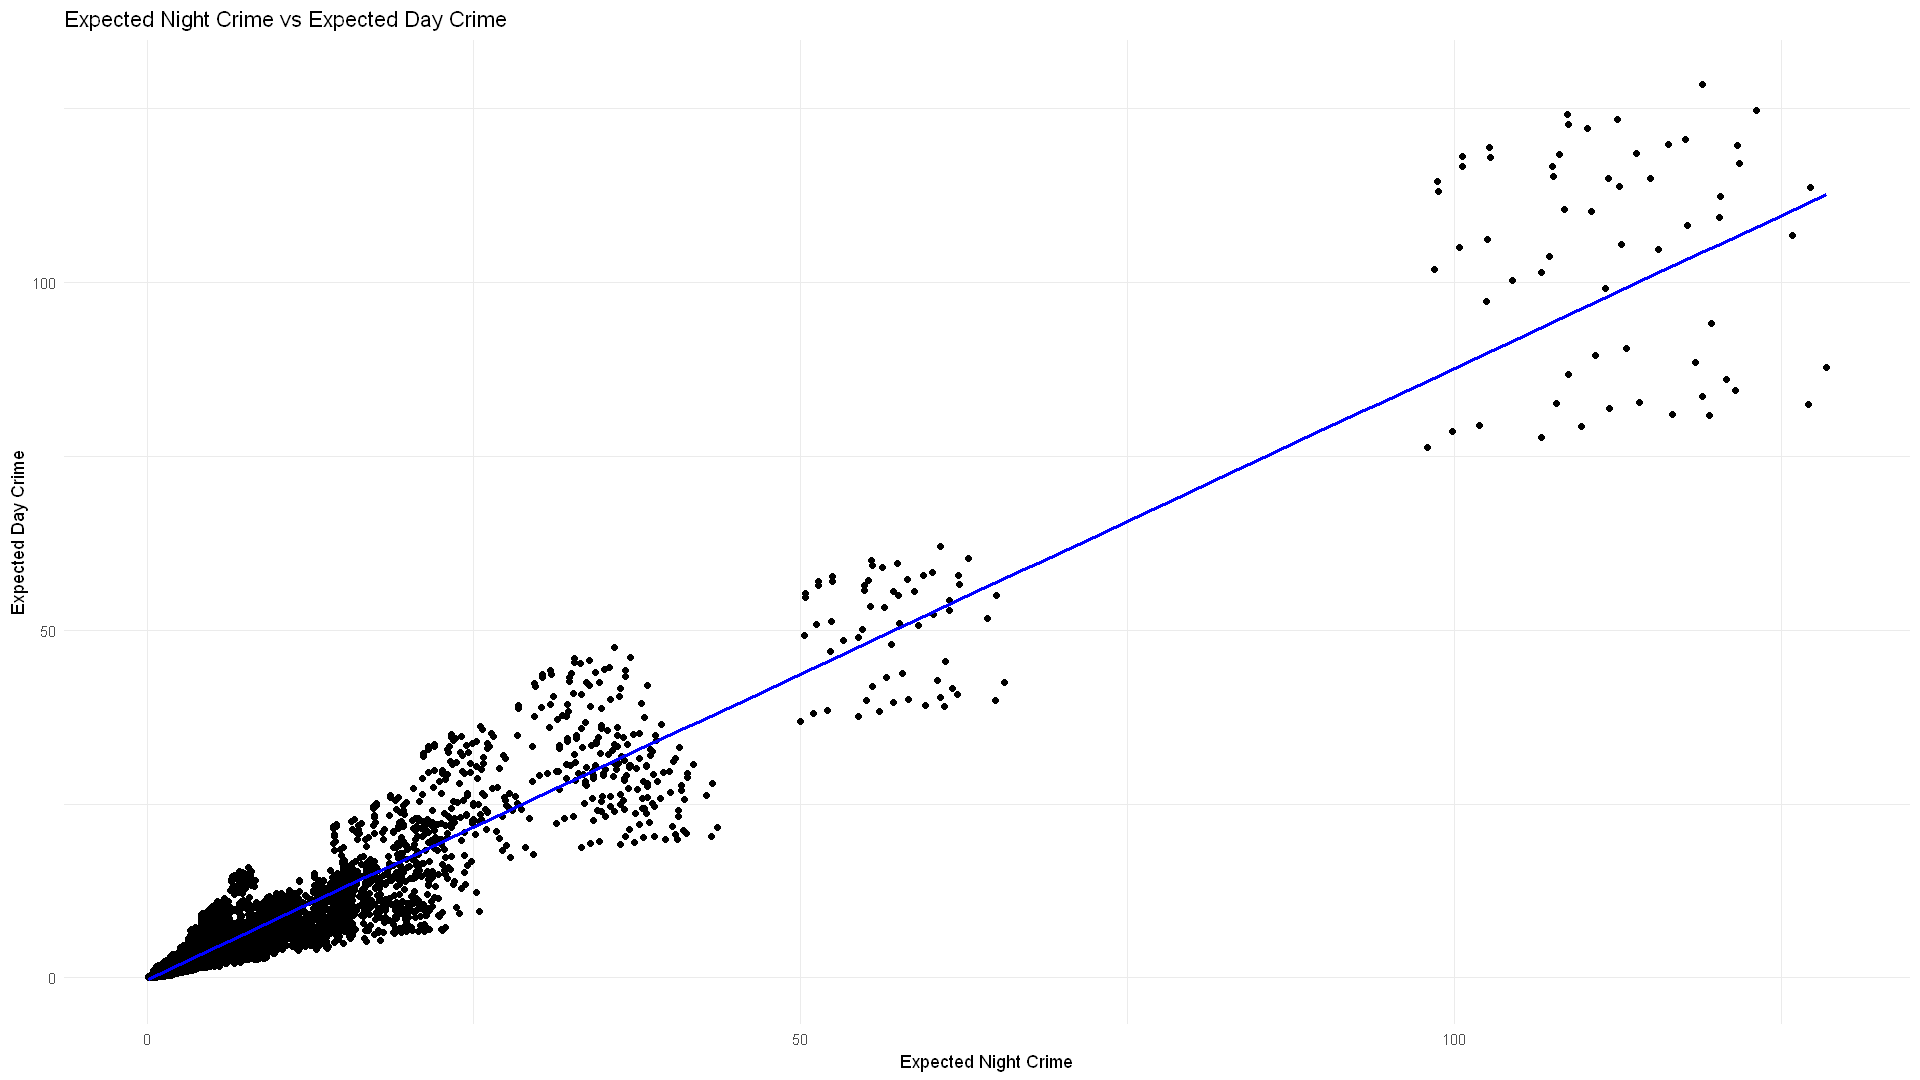

In [ ]:
ggplot(data = census2016_2021_panel_night, aes(x = expected_crime, y = expected_day_crime)) +
  geom_point() +
  labs(title = "Expected Night Crime vs Expected Day Crime",
       x = "Expected Night Crime",
       y = "Expected Day Crime") +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  theme_minimal()

In [ ]:
# Read in data for electric price index
electric_index <- read_csv("electric_price_index.csv")|>
    dplyr::select(REF_DATE, Index, VALUE)|>
    filter(Index == "Electric power selling price under 5000kw")|>
    mutate(date = as.Date(paste0(REF_DATE, "-01")))|>
    rename("electric_index" = "VALUE")|>
    dplyr::select(date, electric_index)|>
    glimpse()

Rows: 264 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): REF_DATE, GEO, DGUID, Index, UOM, SCALAR_FACTOR, VECTOR
dbl (5): UOM_ID, SCALAR_ID, COORDINATE, VALUE, DECIMALS
lgl (3): STATUS, SYMBOL, TERMINATED

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 132
Columns: 2
$ date           <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-0…
$ electric_index <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7, 10…


In [ ]:
census2016_2021_panel_night <- census2016_2021_panel_night|>
    left_join(electric_index, by = "date")|>
    glimpse()

Rows: 117,000
Columns: 30
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [ ]:
# Save the data so we can start from here next time
census2016_2021_panel_night <- census2016_2021_panel_night|>
    select(-c(households, dwellings, region))

write_csv(census2016_2021_panel_night, "census2016_2021_panel.csv")

ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `households` doesn't exist.


#### Wrapping neighborhood data

In [ ]:
# Generate the dataset on 22 neighborhood
neighborhood2016_2021_panel <- census2016_2021_panel|>
    st_drop_geometry()|>
    filter(name != "59153586") |>  # Remove Stanley Park
    mutate(income = as.double(income)) |>
    filter(!is.na(income)) |>
    # Create separate month and year columns
    group_by(neighborhood, year, month, time_category) |>
    summarise(
        population = sum(population),
        area_sq_km = sum(area_sq_km),
        population_density = population / area_sq_km,
        income = mean(income),
        crime_count = sum(crime_count),
        electric_index = mean(electric_index, na.rm = TRUE),
        .groups = "drop"
    ) |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Warning message:
"There were 5520 warnings in `summarise()`.
The first warning was:
ℹ In argument: `electric_index = mean(electric_index, na.rm = TRUE)`.
ℹ In group 1: `neighborhood = Arbutus Ridge`, `year = 2014`, `month = 1`,
  `time_category = day`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5519 remaining warnings."


Rows: 5,520
Columns: 11
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…


In [ ]:
neighborhood_ntl <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    rename("neighborhood" = "name")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    dplyr::select(!geo_point_2d)|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 6
$ neighborhood       <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [ ]:
neighborhood2016_2021_panel <- neighborhood2016_2021_panel|>
    left_join(neighborhood_ntl, by = c("neighborhood", "date"))|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    filter(!is.na(neighborhood))|>
    glimpse()

Rows: 5,280
Columns: 16
$ neighborhood       <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge", …
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [ ]:
neighborhood_crime_summary <- neighborhood2016_2021_panel|>
    group_by(time_category)|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

neighborhood_crime_summary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<int>,<int>
day,39.99470,3414.761,0,523
night,60.56591,5733.233,3,668


In [ ]:
write_csv(neighborhood2016_2021_panel, "neighborhood2016_2021_panel.csv")

### Panel Fixed Effect Model

#### Explorations on 989 Census Divisions

With the data ready, we can run our first panel fixed effect model.

In [38]:
census2016_2021_panel_night <- read_csv("census2016_2021_panel.csv")|>
    drop_na(expected_crime, ntl_mean, population_density, income)|>
    glimpse()

Rows: 117000 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): neighborhood
dbl  (25): name, population, population_density, area_sq_km, age, income, im...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 107,249
Columns: 27
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_va

In [39]:
census_division_crime_summary <- census2016_2021_panel_night|>
    group_by(name)|>
    summarise(count = n(),
    mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

census_division_crime_summary

name,count,mean,variance,min,max
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
59150307,110,1.0446502,0.03444858,0.7280437,1.4225324
59150308,110,0.8710167,0.02362261,0.6090565,1.1900421
59150309,110,1.3757951,0.06763985,0.9330244,1.8230464
59150310,110,1.9625492,0.11731032,1.5662691,3.0603500
59150311,110,0.8174248,0.02452339,0.5513363,1.0772619
59150312,110,0.6963788,0.01893601,0.4639182,0.9064548
59150313,110,1.1453287,0.06304929,0.7329629,1.5243441
59150328,110,0.7798727,0.02999594,0.4966118,1.0416356
59150329,110,1.1182238,0.04635708,0.7526847,1.4706787


In [40]:
sum(census_division_crime_summary$count <110)

[1] 35

In [41]:
# A balancing table of census panel
covariates <- c("is_downtown", "electric_index", "income", "expected_day_crime",
                "population_density", "immigrant_prop", "university_prop", 
                "school_index", "bus_index", "cultural_space_index", 
                "mean_land_value")

# Here we assign "High" if above the median and "Low" otherwise.
census2016_2021_panel_night$treated <- ifelse(
  census2016_2021_panel_night$ntl_mean > median(census2016_2021_panel_night$ntl_mean, na.rm = TRUE), 
  "High", 
  "Low"
)

# Generate the balancing table using the CreateTableOne function.
bal_table <- CreateTableOne(vars = covariates, strata = "treated", 
                            data = census2016_2021_panel_night, test = TRUE)

# Print the table with standardized mean differences (SMD)
print(bal_table, smd = TRUE)

                                  Stratified by treated
                                   High                Low               p     
  n                                   53624              53625                 
  is_downtown (mean (SD))              0.10 (0.30)        0.00 (0.03)    <0.001
  electric_index (mean (SD))         115.39 (7.27)      114.81 (7.17)    <0.001
  income (mean (SD))                   0.73 (0.23)        0.90 (0.27)    <0.001
  expected_day_crime (mean (SD))       1.41 (4.62)        0.40 (0.70)    <0.001
  population_density (mean (SD))   13567.03 (11995.65) 6638.29 (5007.72) <0.001
  immigrant_prop (mean (SD))           0.38 (0.14)        0.45 (0.14)    <0.001
  university_prop (mean (SD))          0.18 (0.20)        0.18 (0.17)     0.002
  school_index (mean (SD))             2.75 (0.75)        2.49 (0.85)    <0.001
  bus_index (mean (SD))                3.14 (0.73)        2.68 (0.77)    <0.001
  cultural_space_index (mean (SD))     2.63 (0.98)        1.79 (

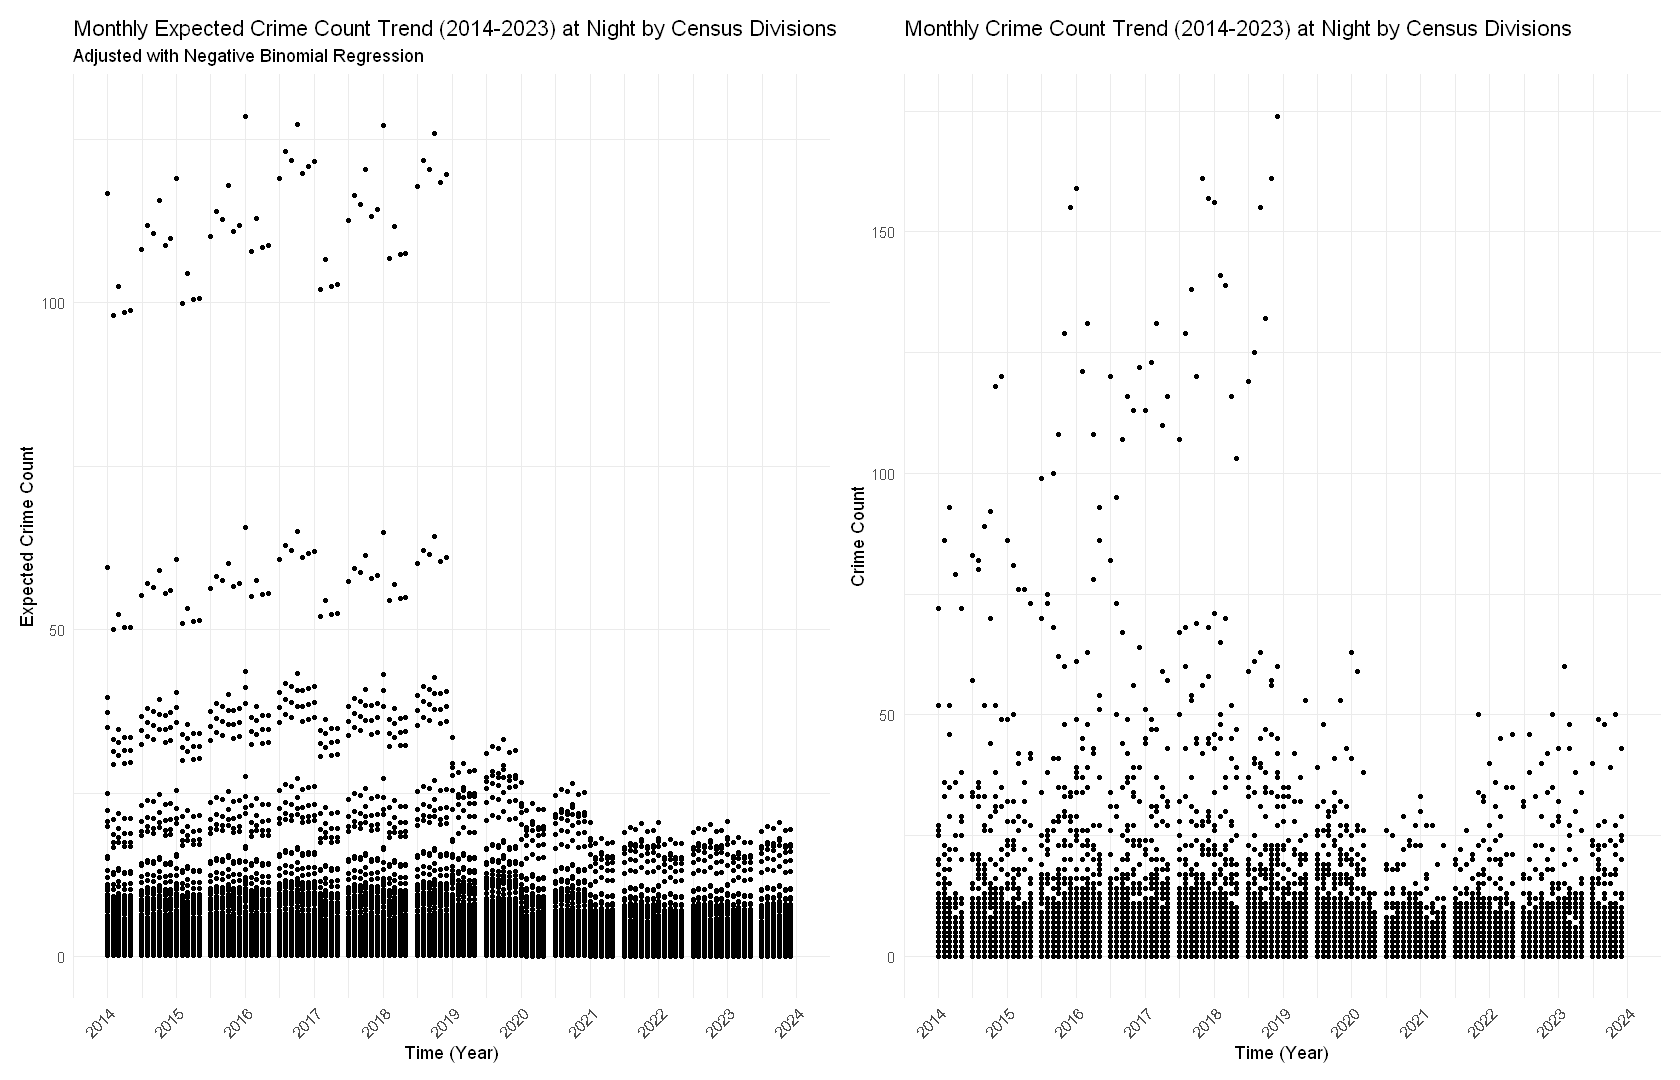

In [42]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

census_night_expected_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) at Night by Census Divisions",
       subtitle = "Adjusted with Negative Binomial Regression") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
census_night_count_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) at Night by Census Divisions") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
census_night_expected_dist + census_night_count_dist

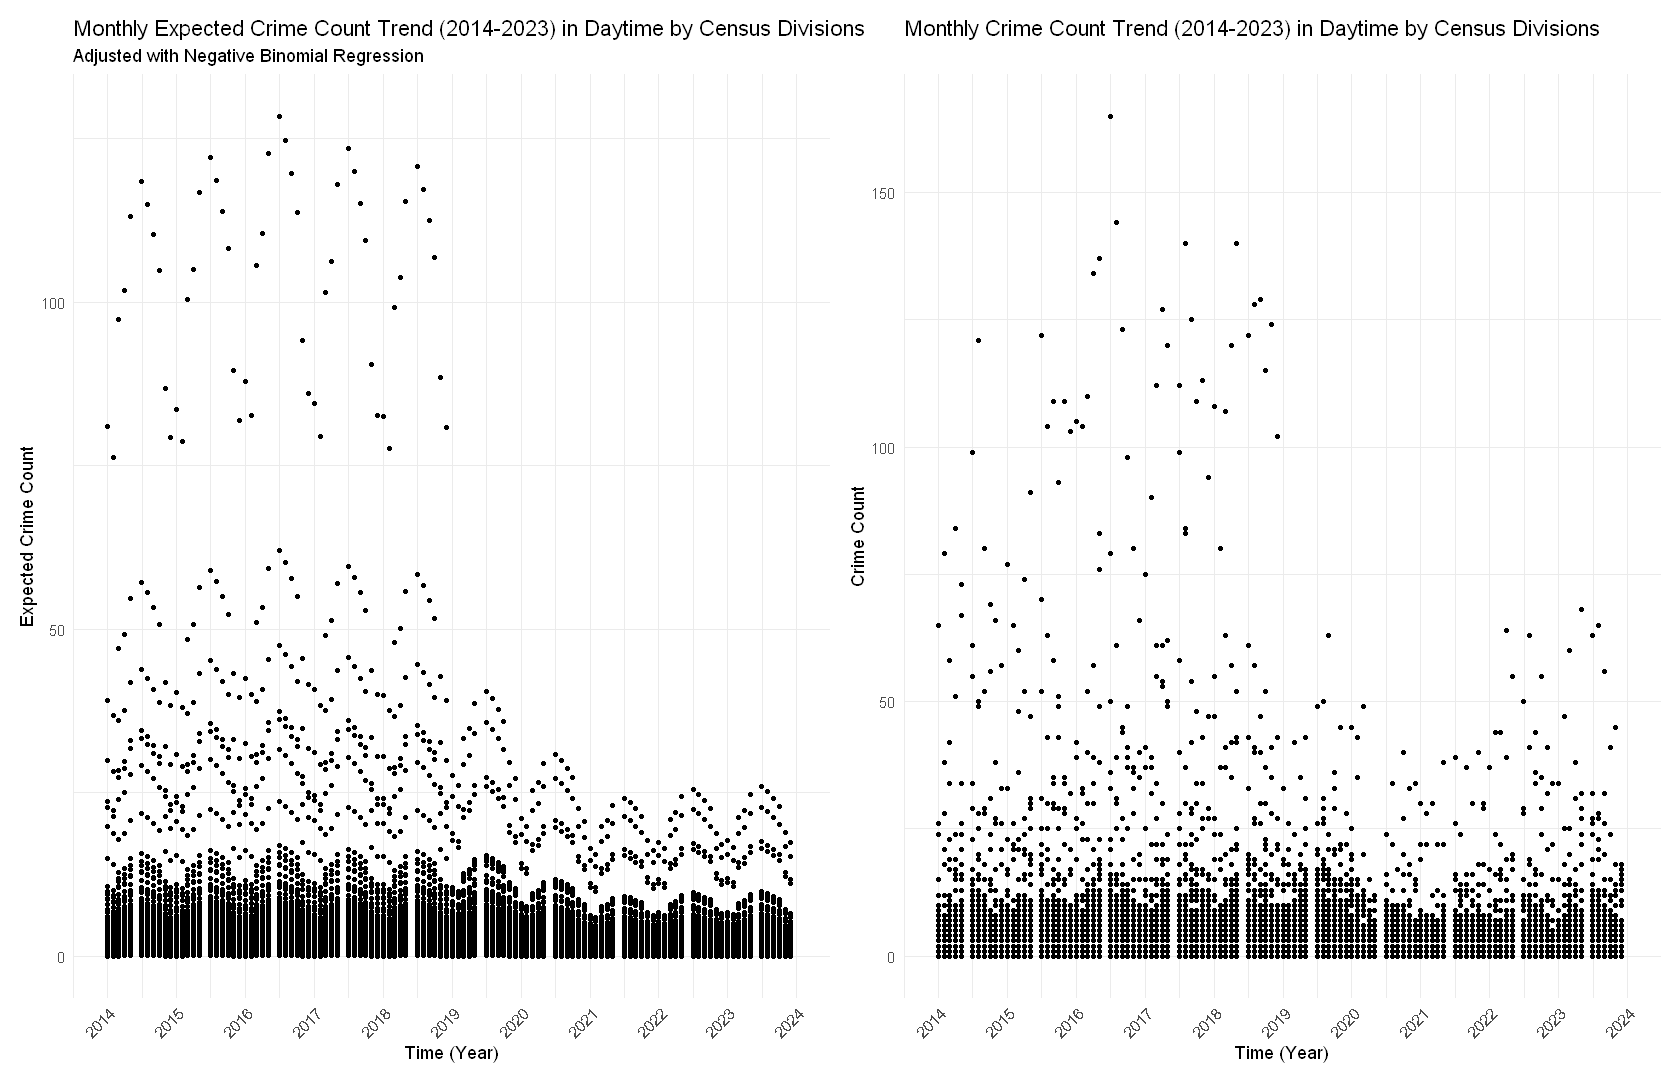

In [43]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

census_day_expected_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) in Daytime by Census Divisions", 
       subtitle = "Adjusted with Negative Binomial Regression") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
census_day_count_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = day_crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) in Daytime by Census Divisions") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
census_day_expected_dist + census_day_count_dist

`geom_smooth()` using formula = 'y ~ x'


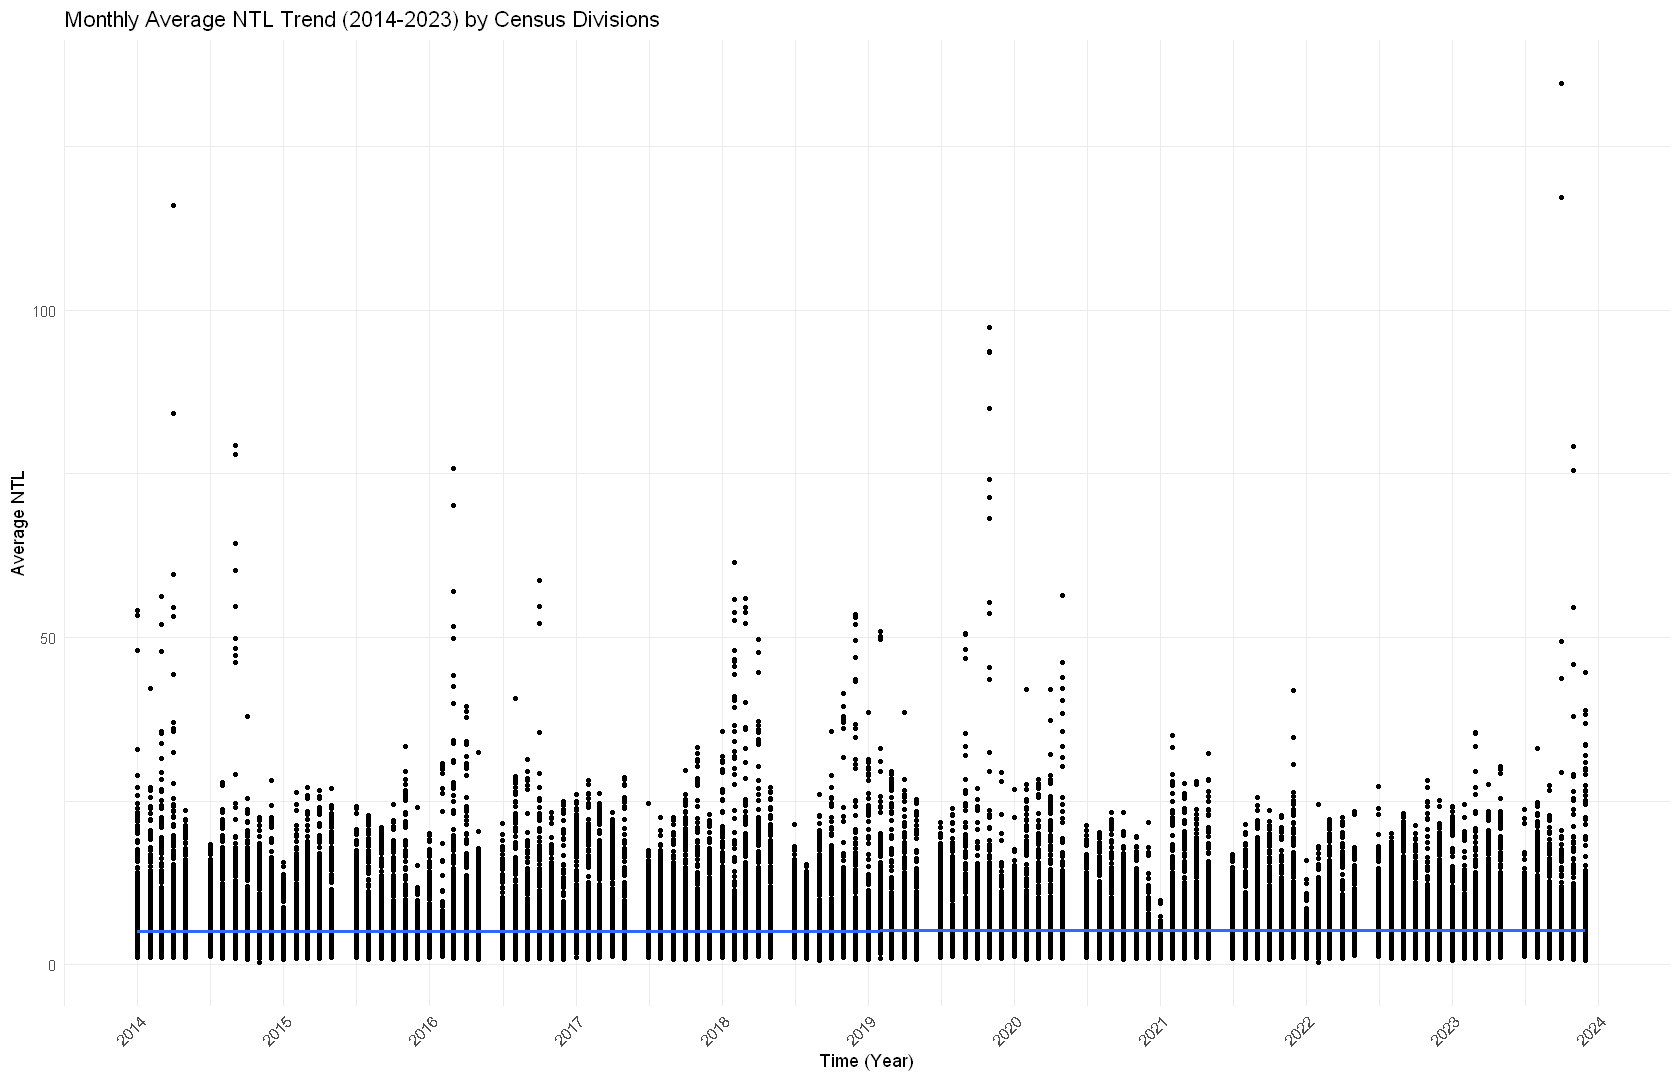

In [44]:
ggplot(census2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2014-2023) by Census Divisions") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

#### Census Divisions Models

In [45]:
library(plm)

In [46]:
model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual",
                             na.action = na.exclude)
                    
summary(model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = census2016_2021_panel_night, na.action = na.exclude, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-14.6077113  -0.1032458   0.0049142   0.0916115  15.9885402 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.01474048  0.00136713 -10.7821 < 2.2e-16 ***
year                 -0.05184995  0.00060082 -86.2982 < 2.2e-16 ***
month                 0.00896210  0.00047753  18.7677 < 2.2e-16 ***
ntl_mean:is_downtown  0.01199364  0.00178767   6.7091 1.968e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    35736
Residual Sum of Squares: 33165
R-Squared:      0.07195
Adj. R-Squared: 0.063259
F-statistic: 2059

In [47]:
model1 <- plm(expected_crime ~ ntl_mean * is_downtown  + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual",
                             na.action = na.exclude)

summary(model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + population_density + 
    income, data = census2016_2021_panel_night, na.action = na.exclude, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-14.556698  -0.094375  -0.012445   0.088277  15.953038 

Coefficients:
                        Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean             -2.0973e-02  1.3697e-03 -15.312 < 2.2e-16 ***
population_density    7.9349e-05  1.6639e-06  47.689 < 2.2e-16 ***
income               -1.1653e+00  1.8524e-02 -62.909 < 2.2e-16 ***
ntl_mean:is_downtown  1.9182e-02  1.7975e-03  10.672 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    35736
Residual Sum of Squares: 33773
R-Squared:      0.054946
Adj. R-Squared: 0.046096
F-statistic: 154

In [48]:
model2 <- plm(expected_crime ~ ntl_mean*is_downtown + expected_day_crime  + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual",
                             na.action = na.exclude)

summary(model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_night, 
    na.action = na.exclude, effect = "individual", model = "within", 
    index = c("name", "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-18.781232  -0.079445  -0.011582   0.070159  23.492549 

Coefficients:
                        Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean             -2.5440e-02  1.1511e-03 -22.100 < 2.2e-16 ***
expected_day_crime    4.5633e-01  2.1696e-03 210.328 < 2.2e-16 ***
population_density    5.7348e-05  1.4020e-06  40.904 < 2.2e-16 ***
income               -7.8811e-01  1.5668e-02 -50.299 < 2.2e-16 ***
ntl_mean:is_downtown  3.0536e-02  1.5113e-03  20.205 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    35736
Residual Sum 

##### White Test and RESET Test

We run the white test to check for heteroskedasticity, and we find that the model is heteroskedastic. We can use the robust standard error to correct for this.

In [49]:
# We run bptest to check for heteroskedasticity
bptest(model0, studentize = TRUE)


	studentized Breusch-Pagan test

data:  model0
BP = 5991.6, df = 5, p-value < 2.2e-16


The result shows the models are likely heteroskedastic, so we include a clustered standard error to correct for the significance.

In [50]:
clustered_se0 <- sqrt(diag(vcovHC(model0, type = "HC0", cluster = "group")))
clustered_se1 <- sqrt(diag(vcovHC(model1, type = "HC0", cluster = "group")))
clustered_se2 <- sqrt(diag(vcovHC(model2, type = "HC0", cluster = "group")))

To further study the quality of our models, I run wald and wooldridge tests on the model to check for its linearity.

In [51]:
wooldridge_result <- pwartest(model2)
wooldridge_result


	Wooldridge's test for serial correlation in FE panels

data:  model2
F = 793.65, df1 = 1, df2 = 106255, p-value < 2.2e-16
alternative hypothesis: serial correlation


In [52]:
census_test_panel <- pdata.frame(census2016_2021_panel_night, index = c("name", "date"))|>
    select(name, expected_crime, ntl_mean, expected_day_crime, population_density, income, is_downtown, date)

census_test_panel$y_hat <- fitted(model2)

model_reset <- plm(expected_crime ~ ntl_mean*is_downtown + expected_day_crime + population_density + income + y_hat + I(y_hat^2) + I(y_hat^3), 
                            index = c("name", "date"),
                             data = census_test_panel, 
                             model = "within", 
                             effect = "individual",
                             na.action = na.exclude)
                        
summary(model_reset)

clustered_se_reset <- sqrt(diag(vcovHC(model_reset, type = "HC0", cluster = "group")))

reset_test <- linearHypothesis(
  model_reset,
  c("y_hat = 0", "I(y_hat^2) = 0"),
  vcov   = vcovHC(model_reset, type = "HC0", cluster = "group"),
  test   = "F"
)

reset_test

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    population_density + income + y_hat + I(y_hat^2) + I(y_hat^3), 
    data = census_test_panel, na.action = na.exclude, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-18.369900  -0.076055  -0.011547   0.066149  22.431389 

Coefficients: (1 dropped because of singularities)
                      Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean           -3.7295e-03  8.0671e-04  -4.6231 3.786e-06 ***
expected_day_crime  1.8998e-01  2.1875e-02   8.6847 < 2.2e-16 ***
population_density -4.3252e-06  3.0387e-06  -1.4234  0.154627    
income              8.6936e-02  4.1668e-02   2.0864  0.036946 *  
y_hat               9.5095e-01  4.7655e-02  19.9549 < 2.2e-16 ***
I(y_hat^2)          4.0609e-03  1.2796e-03   3.1736  0.00

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,106252,NA,NA,NA
2,106250,2,13.04735,2.15925e-06


We want to have a better interpretability of how crime would change, so we are switching to a $log-log$ model.

In [53]:
model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + year + month + population_density + income, 
                            index = c("name", "date"),
                            data = census2016_2021_panel_night, 
                            model = "within", 
                            effect = "individual")
summary(model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    year + month + population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-0.730639 -0.112009 -0.010996  0.092388  0.848467 

Coefficients:
                             Estimate  Std. Error   t-value  Pr(>|t|)    
log(ntl_mean)             -5.8703e-02  2.1031e-03  -27.9123 < 2.2e-16 ***
year                      -5.0654e-02  2.3694e-04 -213.7825 < 2.2e-16 ***
month                      6.6449e-03  1.2298e-04   54.0318 < 2.2e-16 ***
population_density         4.9260e-05  4.2295e-07  116.4681 < 2.2e-16 ***
income                    -2.5323e-02  7.2067e-03   -3.5138 0.0004419 ***
log(ntl_mean):is_downtown  6.1991e-02  6.0460e-03   10.2532 < 2.2e-16 ***
---
Signif. codes:  0 

In [54]:
model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.8269430 -0.1233947  0.0016395  0.1015818  1.1201216 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -8.6645e-02  2.5021e-03  -34.629 < 2.2e-16 ***
population_density         4.3535e-05  5.0948e-07   85.450 < 2.2e-16 ***
income                    -1.1832e+00  5.6973e-03 -207.679 < 2.2e-16 ***
log(ntl_mean):is_downtown  9.5667e-02  7.2886e-03   13.126 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    4702.1
Residual Sum of Squares: 3166
R-Squared:      0.32669
Adj. R-Squared: 0.32039
F-

In [55]:
model_log2 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual",)

summary(model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.3012219 -0.1200399  0.0015233  0.0998955  1.2017684 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -9.2207e-02  2.4525e-03  -37.597 < 2.2e-16 ***
expected_day_crime         5.1753e-02  7.7436e-04   66.834 < 2.2e-16 ***
population_density         4.1028e-05  5.0051e-07   81.972 < 2.2e-16 ***
income                    -1.1394e+00  5.6196e-03 -202.754 < 2.2e-16 ***
log(ntl_mean):is_downtown  1.0461e-01  7.1414e-03   14.649 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squar

In [56]:
# We run bptest to check for heteroskedasticity
bptest(model_log0, studentize = TRUE)


	studentized Breusch-Pagan test

data:  model_log0
BP = 5422.9, df = 7, p-value < 2.2e-16


In [57]:
clustered_log_se0 <- sqrt(diag(vcovHC(model_log0, type = "HC0", cluster = "group")))
clustered_log_se1 <- sqrt(diag(vcovHC(model_log1, type = "HC0", cluster = "group")))
clustered_log_se2 <- sqrt(diag(vcovHC(model_log2, type = "HC0", cluster = "group")))

In [58]:
census_test_panel_log <- pdata.frame(census2016_2021_panel_night, index = c("name", "date"))|>
    select(name, expected_crime, ntl_mean, expected_day_crime, population_density, income, is_downtown, date)

census_test_panel_log$y_hat <- fitted(model_log2)

model_reset_log <- plm(log(expected_crime) ~ log(ntl_mean)*is_downtown + expected_day_crime + population_density + income + y_hat + I(y_hat^2) + I(y_hat^3), 
                            index = c("name", "date"),
                             data = census_test_panel_log, 
                             model = "within", 
                             effect = "individual",
                             na.action = na.exclude)
                        
summary(model_reset_log)

clustered_se_reset_log <- sqrt(diag(vcovHC(model_reset_log, type = "HC0", cluster = "group")))

reset_test <- linearHypothesis(
  model_reset_log,
  c("y_hat = 0", "I(y_hat^2) = 0"),
  vcov   = vcovHC(model_reset_log, type = "HC0", cluster = "group"),
  test   = "F"
)

reset_test

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + population_density + income + y_hat + 
    I(y_hat^2) + I(y_hat^3), data = census_test_panel_log, na.action = na.exclude, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-1.61826336 -0.11691819 -0.00022615  0.09711443  3.02666719 

Coefficients: (1 dropped because of singularities)
                      Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)      -1.5770e-02  5.7847e-03  -2.7262  0.006409 ** 
expected_day_crime  4.7826e-02  3.5814e-03  13.3542 < 2.2e-16 ***
population_density  1.4500e-05  2.7797e-06   5.2163 1.829e-07 ***
income             -9.3551e-02  7.6484e-02  -1.2231  0.221278    
y_hat               9.5203e-01  6.6696e-02  14.2741 < 2.2e-16 ***
I(y_hat^2)         -3.74

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,106252,NA,NA,NA
2,106250,2,32.71824,6.237704e-15


In [59]:
reset_summary <- stargazer(model_reset, model_reset_log,
          type = "latex",                   
          title = "RESET Test on the Scale of Census Divisions",
          dep.var.labels = c("Expected Crime", "log(Expected Crime)"),
        #   covariate.labels = c("Average NTL",
        #                        "log(Average NTL)",
        #                        "Expected Day Crime",
        #                        "Population Density",
        #                        "Income (in $100,000)",
        #                        "y_hat",
        #                        "y_hat^2",
        #                        "y_hat^3"),
          se = list(clustered_se_reset, clustered_se_reset_log),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))  


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: 周日, 4月 20, 2025 - 18:47:38
\begin{table}[!htbp] \centering 
  \caption{RESET Test on the Scale of Census Divisions} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lcc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{2}{c}{\textit{Dependent variable:}} \\ 
\cline{2-3} 
\\[-1.8ex] & Expected Crime & log(Expected Crime) \\ 
\\[-1.8ex] & (1) & (2)\\ 
\hline \\[-1.8ex] 
 ntl\_mean & $-$0.004 &  \\ 
  & (0.004) &  \\ 
  & & \\ 
 log(ntl\_mean) &  & $-$0.016 \\ 
  &  & (0.010) \\ 
  & & \\ 
 expected\_day\_crime & 0.190 & 0.048$^{***}$ \\ 
  & (0.131) & (0.014) \\ 
  & & \\ 
 population\_density & $-$0.00000 & 0.00001$^{**}$ \\ 
  & (0.00002) & (0.00001) \\ 
  & & \\ 
 income & 0.087 & $-$0.094 \\ 
  & (0.177) & (0.139) \\ 
  & & \\ 
 y\_hat & 0.951$^{***}$ & 0.952$^{***}$ \\ 
  & (0.186) & (0.118) \\ 
  & & \\ 
 I(y\_hat$\hat{\mkern6mu}$2) & 0.004 & $-$0.

We run robustness check on the unadjusted crime counts

In [60]:
model_count0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month + 
    population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-42.17685  -0.68375  -0.30666   0.48807  60.10702 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -1.2243e-03  4.2324e-03  -0.2893    0.7724    
year                 -4.4462e-02  2.8621e-03 -15.5350 < 2.2e-16 ***
month                 1.1030e-02  1.4764e-03   7.4711 8.013e-14 ***
population_density    7.1066e-06  5.1080e-06   1.3913    0.1642    
income               -8.7148e-03  8.6886e-02  -0.1003    0.9201    
ntl_mean:is_downtown  2.4452e-02  5.5311e-03   4.4207 9.847e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum

In [61]:
model_count1 <- plm(crime_count ~ ntl_mean * is_downtown + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + population_density + 
    income, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-42.15056  -0.68819  -0.32800   0.48706  60.07740 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -6.8365e-03  4.2024e-03  -1.6268    0.1038    
population_density    2.1028e-06  5.1049e-06   0.4119    0.6804    
income               -1.0249e+00  5.6833e-02 -18.0339 < 2.2e-16 ***
ntl_mean:is_downtown  3.0126e-02  5.5148e-03   5.4628 4.698e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    319050
Residual Sum of Squares: 317900
R-Squared:      0.0035957
Adj. R-Squared: -0.0057351
F-statistic: 95.8572 on 4 and 106253 DF, p-value: < 

In [62]:
model_count2 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count2)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-41.47568  -0.65656  -0.29498   0.53068  60.02379 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -1.7243e-02  3.9278e-03  -4.3901 1.134e-05 ***
day_crime_count       4.0581e-01  3.2663e-03 124.2419 < 2.2e-16 ***
population_density    6.2303e-06  4.7703e-06   1.3061    0.1915    
income               -7.5068e-01  5.3153e-02 -14.1232 < 2.2e-16 ***
ntl_mean:is_downtown  4.7599e-02  5.1551e-03   9.2334 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    319050
Residual Sum of Squares: 277570
R-Squared:

In [63]:
clustered_count_se0 <- sqrt(diag(vcovHC(model_count0, type = "HC0", cluster = "group")))
clustered_count_se1 <- sqrt(diag(vcovHC(model_count1, type = "HC0", cluster = "group")))
clustered_count_se2 <- sqrt(diag(vcovHC(model_count2, type = "HC0", cluster = "group")))

##### Summary Tables

In [64]:
models <- list(model0, model1, model2, model_log0, model_log1, model_log2)

census_summary1 <- stargazer(models,
          type = "latex",                   
          title = "Regression of Expected Crime on Average NTL in the Scale of Census Divisions",
          dep.var.labels = c("Expected Crime", "log(Expected Crime)"),
          covariate.labels = c("Average NTL",
                               "log(Average NTL)",
                               "Expected Day Crime",
                               "Population Density",
                               "Income (in $100,000)",
                               "Average NTL x is Downtown",
                               "log(Average NTL) x is Downtown"),
          se = list(clustered_se0, clustered_se1, clustered_se2, clustered_log_se0, clustered_log_se1, clustered_log_se2),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: 周日, 4月 20, 2025 - 18:47:43
\begin{table}[!htbp] \centering 
  \caption{Regression of Expected Crime on Average NTL in the Scale of Census Divisions} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lcccccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{6}{c}{\textit{Dependent variable:}} \\ 
\cline{2-7} 
\\[-1.8ex] & \multicolumn{3}{c}{Expected Crime} & \multicolumn{3}{c}{log(Expected Crime)} \\ 
\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6)\\ 
\hline \\[-1.8ex] 
 Average NTL & $-$0.015$^{***}$ & $-$0.021$^{***}$ & $-$0.025$^{***}$ &  &  &  \\ 
  & (0.004) & (0.004) & (0.003) &  &  &  \\ 
  & & & & & & \\ 
 log(Average NTL) &  &  &  & $-$0.059$^{***}$ & $-$0.087$^{***}$ & $-$0.092$^{***}$ \\ 
  &  &  &  & (0.003) & (0.004) & (0.004) \\ 
  & & & & & & \\ 
 Expected Day Crime &  &  & 0.456$^{***}$ &  &  & 0.052$^{***}$ \\ 
  &  &  & (0.130) &  &  & (

In [65]:
census_summary3 <- stargazer(list(model_count0, model_count1, model_count2),
          type = "latex",                   
          title = "Regression of Crime Counts on Average NTL in the Scale of Census Divisions",
          dep.var.labels = c("Crime Count"),
          covariate.labels = c("Average NTL",
                               "Daytime Crime Count",
                               "Population Density",
                               "Income (in $100,000)",
                               "Average NTL x is Downtown"),

          se = list(clustered_count_se0, clustered_count_se1),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: 周日, 4月 20, 2025 - 18:47:44
\begin{table}[!htbp] \centering 
  \caption{Regression of Crime Counts on Average NTL in the Scale of Census Divisions} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{3}{c}{\textit{Dependent variable:}} \\ 
\cline{2-4} 
\\[-1.8ex] & \multicolumn{3}{c}{Crime Count} \\ 
\\[-1.8ex] & (1) & (2) & (3)\\ 
\hline \\[-1.8ex] 
 Average NTL & $-$0.001 & $-$0.007 & $-$0.017$^{***}$ \\ 
  & (0.007) & (0.007) & (0.004) \\ 
  & & & \\ 
 Daytime Crime Count &  &  & 0.406$^{***}$ \\ 
  &  &  & (0.003) \\ 
  & & & \\ 
 Population Density & 0.00001 & 0.00000 & 0.00001 \\ 
  & (0.00001) & (0.00001) & (0.00000) \\ 
  & & & \\ 
 Income (in $100,000) & $-$0.009 & $-$1.025$^{***}$ & $-$0.751$^{***}$ \\ 
  & (0.154) & (0.153) & (0.053) \\ 
  & & & \\ 
 Average NTL x is Downtown & 0.024 & 0.030

#### Explorations on 22 Neighborhoods

In [66]:
neighborhood2016_2021_panel <- read_csv("neighborhood2016_2021_panel.csv")|>
    drop_na(crime_count, ntl_mean, population_density, income)

Rows: 5280 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): neighborhood, time_category
dbl  (12): year, month, population, area_sq_km, population_density, income, ...
lgl   (1): electric_index
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [67]:
neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(neighborhood = as.factor(neighborhood))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income))|>
    filter(!is.na(income))|>
    glimpse()

Rows: 2,420
Columns: 16
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 17, 13, 28, 24, 29, 20, 23, 15,…
$ electric_index     <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, 3…
$ n_pixels      

In [68]:
# Check if there are 0 value
sum(neighborhood2016_2021_panel_night$crime_count == 0)

[1] 0

In [69]:
# Adding day crime as a control
neighborhood2016_2021_panel_day <- neighborhood2016_2021_panel|>
    filter(time_category == "day")|>
    mutate(day_crime_count = crime_count)|>
    dplyr::select(neighborhood, date, day_crime_count)

neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel_night|>
    left_join(neighborhood2016_2021_panel_day, by = c("date", "neighborhood"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(neighborhood = as.factor(neighborhood))|>
    glimpse()

Rows: 2,420
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 17, 13, 28, 24, 29, 20, 23, 15,…
$ electric_index     <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, 3…
$ n_pixels      

In [70]:
# A balancing table of neighborhood panel
covariates <- c("is_downtown", "electric_index", "income", "expected_day_crime",
                "population_density")

# Here we assign "High" if above the median and "Low" otherwise.
neighborhood2016_2021_panel_night$treated <- ifelse(
 neighborhood2016_2021_panel_night$ntl_mean > median(neighborhood2016_2021_panel_night$ntl_mean, na.rm = TRUE), 
  "High", 
  "Low"
)

# Generate the balancing table using the CreateTableOne function.
bal_table <- CreateTableOne(vars = covariates, strata = "treated", 
                            data = neighborhood2016_2021_panel_night, test = TRUE)

# Print the table with standardized mean differences (SMD)
print(bal_table, smd = TRUE)

                                Stratified by treated
                                 High              Low               p     
  n                                 1210              1210                 
  is_downtown (mean (SD))           0.09 (0.29)       0.00 (0.00)    <0.001
  income (mean (SD))                0.74 (0.17)       0.95 (0.19)    <0.001
  population_density (mean (SD)) 8619.08 (5967.44) 4300.90 (1926.55) <0.001
                                Stratified by treated
                                 test SMD   
  n                                         
  is_downtown (mean (SD))              0.447
  income (mean (SD))                   1.136
  population_density (mean (SD))       0.974


In [113]:
# 0) 安装并加载必要包
# install.packages(c("plm","dplyr","splines"))
library(plm)
library(dplyr)
library(splines)

# 1) 构造 pdata.frame
panel <- pdata.frame(
  neighborhood2016_2021_panel_night,
  index = c("neighborhood","date")
)

# 2) 定义候选模型公式
model_list <- list(
  linear = log(crime_count) ~ log(ntl_mean) * is_downtown +
             day_crime_count + population_density + income,
  
  quad = log(crime_count) ~ log(ntl_mean) * is_downtown +
            I(log(ntl_mean)^2) +
            day_crime_count + population_density + income,
  
  cubic = log(crime_count) ~ log(ntl_mean) * is_downtown +
             I(log(ntl_mean)^2) + I(log(ntl_mean)^3) +
             day_crime_count + population_density + income,
  
  spline_df3 = log(crime_count) ~ ns(log(ntl_mean), df = 3) * is_downtown +
                 day_crime_count + population_density + income,
  
  spline_df4 = log(crime_count) ~ ns(log(ntl_mean), df = 4) * is_downtown +
                 day_crime_count + population_density + income
)

# 3) 循环拟合、计算 SSR、伪‑AIC/BIC
results <- lapply(names(model_list), function(name) {
  form  <- model_list[[name]]
  m     <- plm(form, data = panel, model = "within", effect = "individual", na.action = na.exclude)
  e     <- residuals(m)
  n_obs <- length(e)
  SSR   <- sum(e^2, na.rm = TRUE)
  k     <- length(coef(m))               # 自由参数个数
  AIC   <- n_obs * log(SSR / n_obs) + 2 * k
  BIC   <- n_obs * log(SSR / n_obs) + log(n_obs) * k
  data.frame(
    model = name,
    n     = n_obs,
    k     = k,
    SSR   = SSR,
    AIC   = AIC,
    BIC   = BIC,
    row.names = NULL
  )
}) |> bind_rows()

# 4) 按 BIC 排序，查看最优模型
results %>%
  arrange(BIC) %>%
  print()


best_by_AIC <- results$model[which.min(results$AIC)]
best_by_BIC <- results$model[which.min(results$BIC)]
cat("AIC Best Model:", best_by_AIC, "\n")
cat("BIC Best Model:", best_by_BIC, "\n")

       model    n  k      SSR       AIC       BIC
1     linear 2420  5 234.7337 -5636.032 -5607.075
2       quad 2420  6 234.6547 -5634.847 -5600.097
3      cubic 2420  7 234.5711 -5633.709 -5593.168
4 spline_df3 2420  9 233.5344 -5640.428 -5588.304
5 spline_df4 2420 10 233.5448 -5638.320 -5580.405
AIC Best Model: spline_df3 
BIC Best Model: linear 


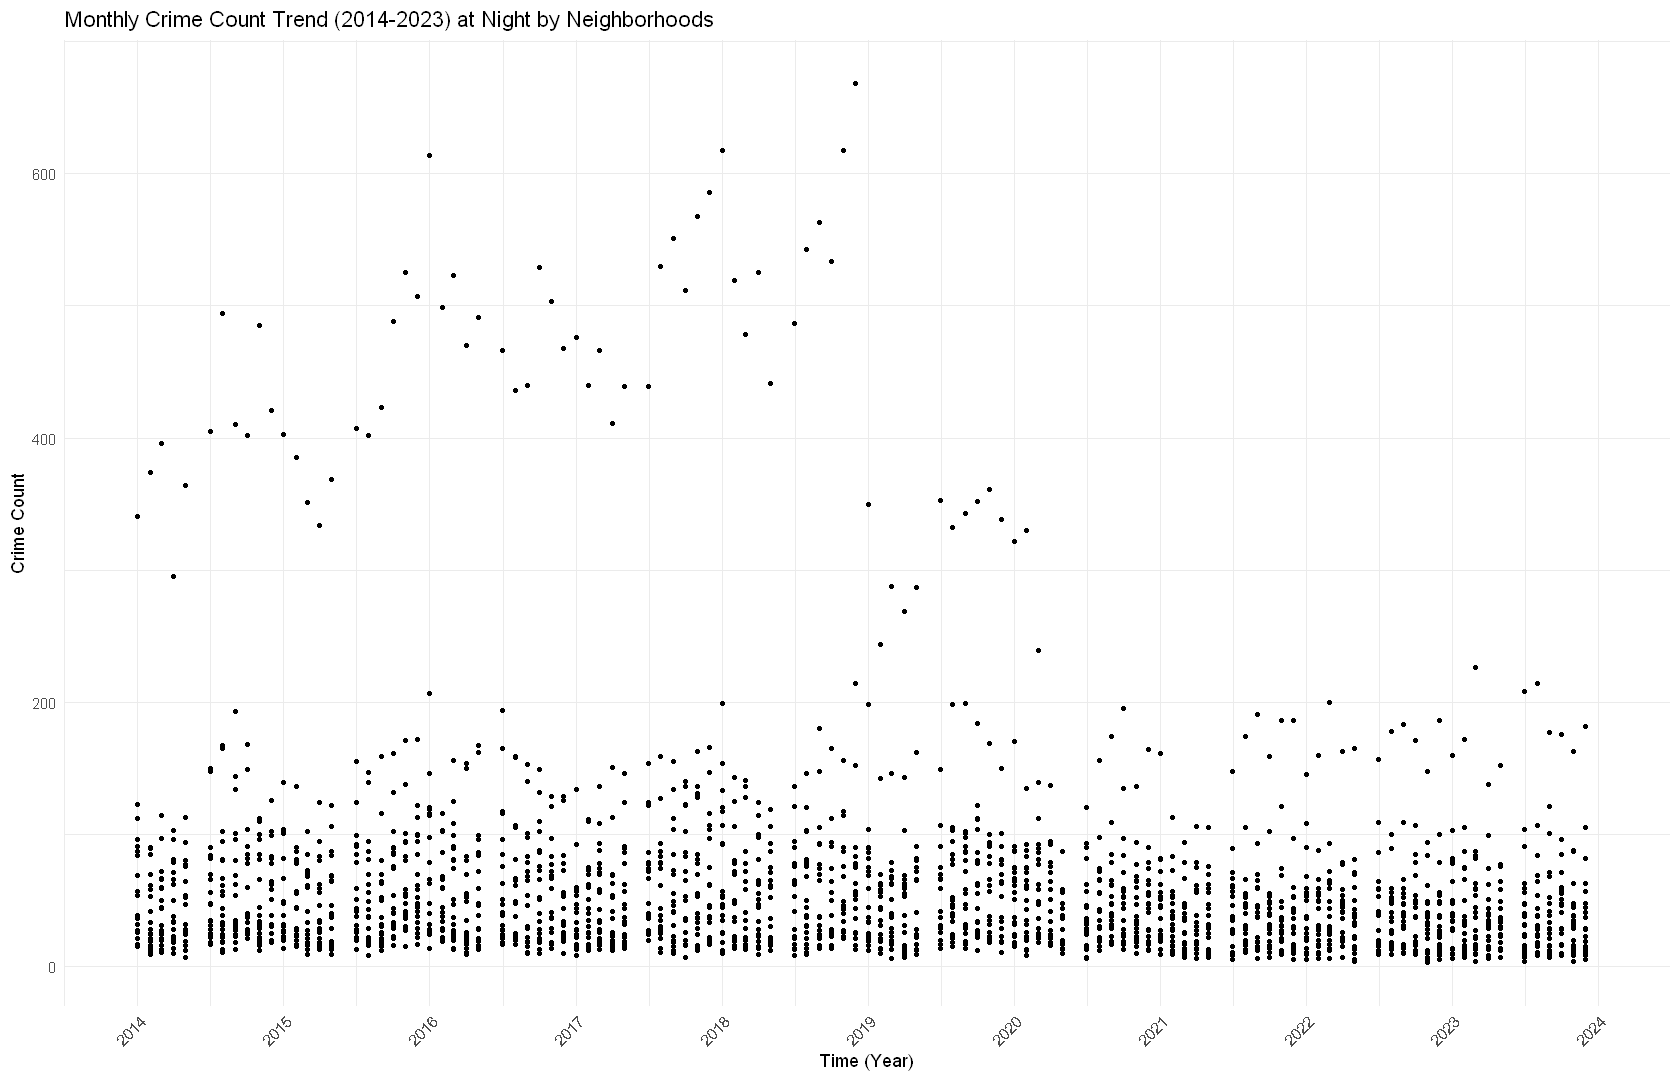

In [72]:
# Plot for crime count
options(repr.plot.width = 14, repr.plot.height = 9)

# Plot for actual crime count
neighborhood_night_count_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) at Night by Neighborhoods") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
neighborhood_night_count_dist

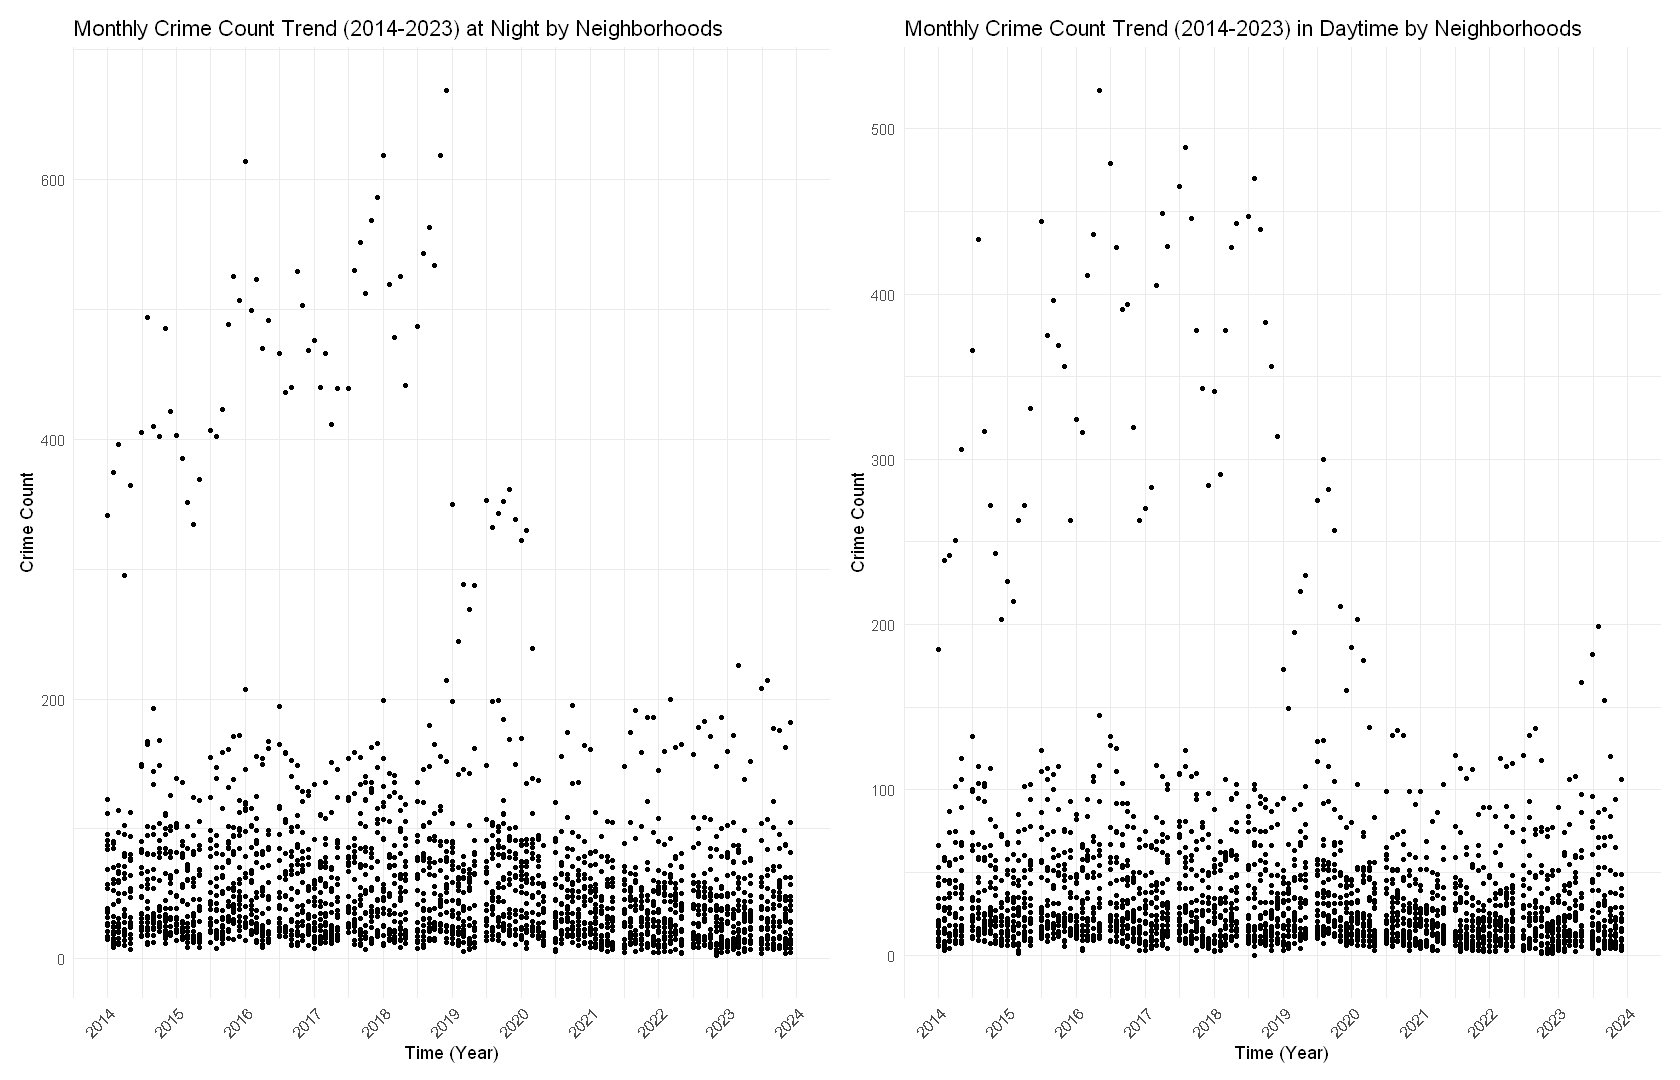

In [73]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

# Plot for actual crime count
neighborhood_day_count_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = day_crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) in Daytime by Neighborhoods") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
neighborhood_night_count_dist + neighborhood_day_count_dist

`geom_smooth()` using formula = 'y ~ x'


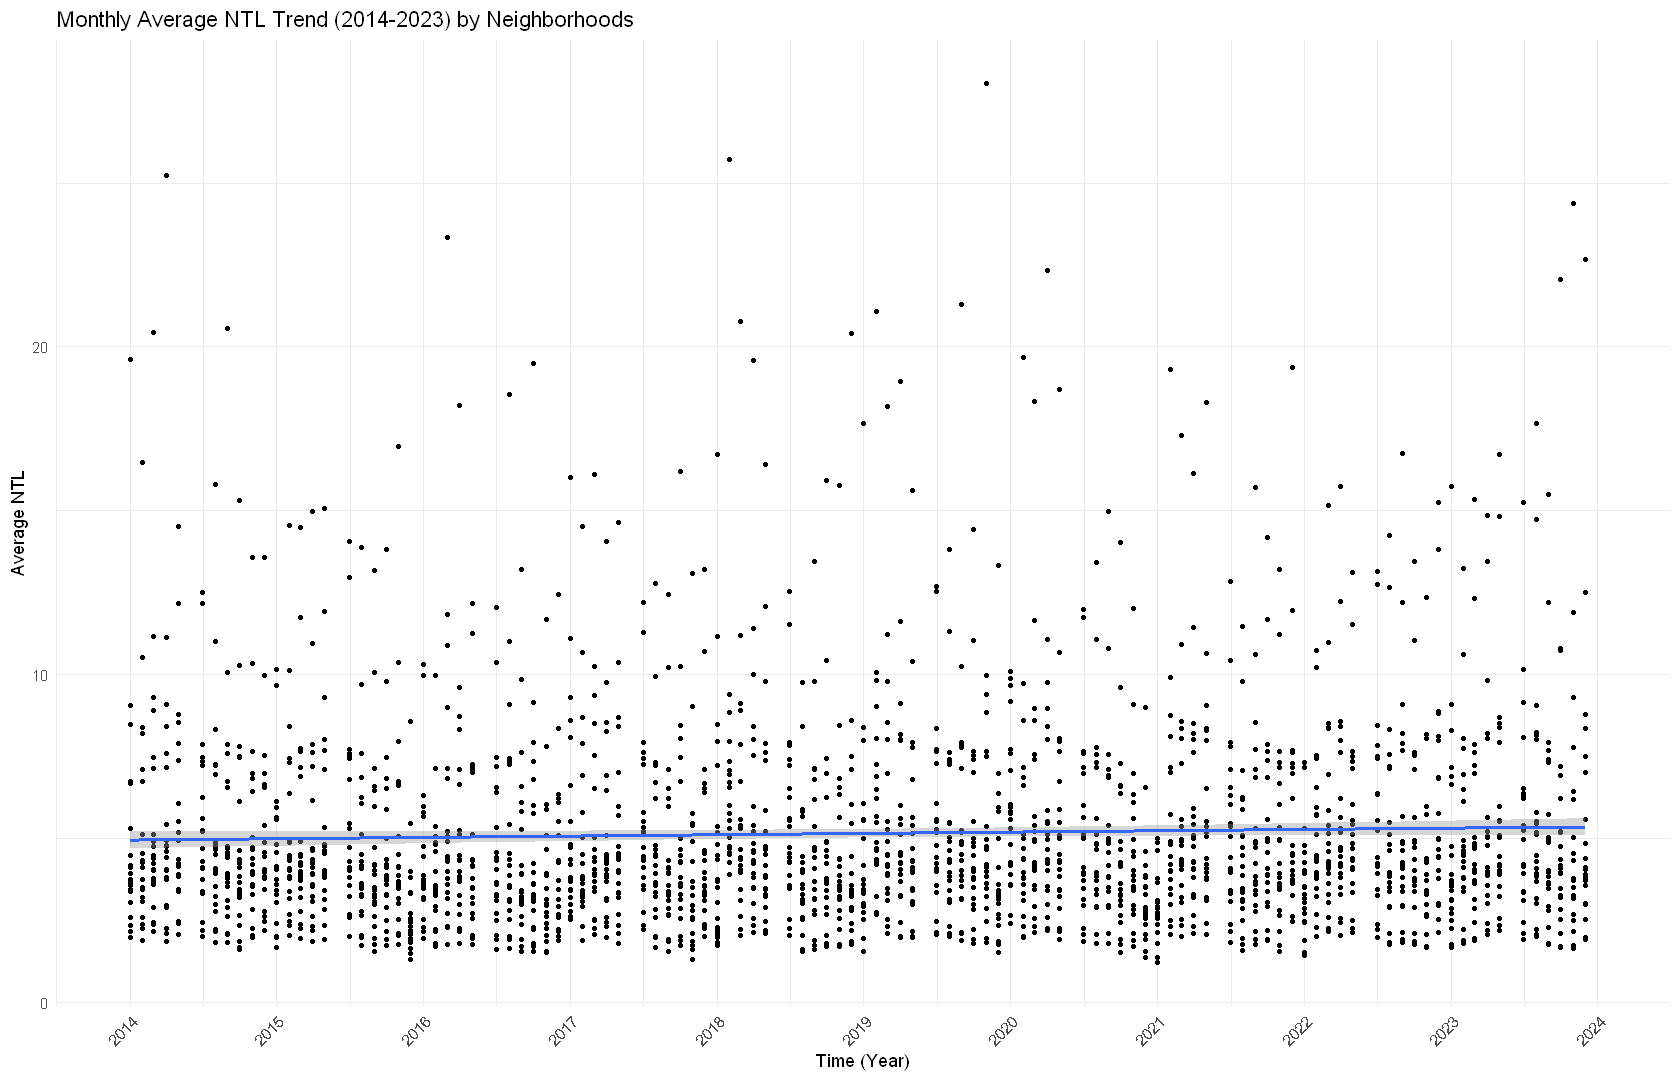

In [74]:
ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2014-2023) by Neighborhoods") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

#### Neighborhood Models

We check the robustness by running models on crime counts.

In [75]:
neighborhood_model0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month + 
    population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-207.26062  -11.61812   -0.68692   10.79329  287.94110 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean               0.3626971   0.9123966   0.3975 0.6910188    
year2015               2.2127812   2.8910051   0.7654 0.4441082    
year2016               9.6895529   2.9050884   3.3354 0.0008650 ***
year2017               6.4355544   2.8768112   2.2370 0.0253759 *  
year2018              10.4984537   2.8685290   3.6599 0.0002578 ***
year2019               3.2198774   7.5144017   0.4285 0.6683302    
year2020             -11.7636524   7.5272662  -1.5628 0.11823

In [76]:
neighborhood_model1 <- plm(crime_count ~ ntl_mean * is_downtown + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + population_density + 
    income, data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-211.0045  -11.9706   -1.2298   11.4025  295.9693 

Coefficients:
                       Estimate Std. Error  t-value Pr(>|t|)    
ntl_mean             -1.3184674  0.8442808  -1.5616   0.1185    
population_density   -0.0783988  0.0035029 -22.3810   <2e-16 ***
income               -7.3349943 10.0662575  -0.7287   0.4663    
ntl_mean:is_downtown  1.3096071  1.1475575   1.1412   0.2539    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    3385000
Residual Sum of Squares: 2544000
R-Squared:      0.24843
Adj. R-Squared: 0.24059
F-statistic: 197.838 on 4 and 2394 DF, p-value: < 2.22e-16

In [77]:
neighborhood_model2 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model2)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-123.99644   -8.10359   -0.87703    6.78161  255.07795 

Coefficients:
                       Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean             -3.4629988  0.5386616 -6.4289 1.546e-10 ***
day_crime_count       0.9423783  0.0158954 59.2861 < 2.2e-16 ***
population_density   -0.0177307  0.0024534 -7.2269 6.616e-13 ***
income               -8.5624659  6.4079328 -1.3362    0.1816    
ntl_mean:is_downtown  4.2740357  0.7322125  5.8372 6.030e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    3385000
Residual Sum of Squares: 1030500
R-Squared:

In [78]:
neighborhood_model_log0 <- plm(log(crime_count) ~ log(ntl_mean) * is_downtown + year + month + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) * is_downtown + 
    year + month + population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-1.40387 -0.17304  0.00910  0.19430  1.06348 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -4.9212e-02  4.4272e-02 -1.1116 0.2664279    
year2015                   2.4435e-02  2.7579e-02  0.8860 0.3757177    
year2016                   7.1077e-02  2.7774e-02  2.5592 0.0105541 *  
year2017                   2.8705e-02  2.7368e-02  1.0489 0.2943476    
year2018                   5.8294e-02  2.7270e-02  2.1377 0.0326469 *  
year2019                   1.8678e-02  7.1502e-02  0.2612 0.7939393    
year2020                  -1.5359e-01  7.16

In [79]:
neighborhood_model_log1 <- plm(log(crime_count) ~ log(ntl_mean) * is_downtown + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) * is_downtown + 
    population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.581316 -0.211567  0.009512  0.220873  1.036205 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -1.6225e-01  4.2512e-02  -3.8165 0.0001388 ***
population_density        -3.5961e-04  3.5713e-05 -10.0694 < 2.2e-16 ***
income                    -1.1374e+00  1.0274e-01 -11.0705 < 2.2e-16 ***
log(ntl_mean):is_downtown  2.0988e-01  1.2522e-01   1.6761 0.0938433 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    328.55
Residual Sum of Squares: 264.46
R-Squared:      0.19508
Adj. R-Squared: 0.18667
F-stati

In [80]:
neighborhood_model_log2 <- plm(log(crime_count) ~ log(ntl_mean) * is_downtown + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) * is_downtown + 
    day_crime_count + population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.581442 -0.187909  0.014773  0.203646  1.040810 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -2.1090e-01  4.0157e-02  -5.2520 1.638e-07 ***
day_crime_count            4.1755e-03  2.3985e-04  17.4087 < 2.2e-16 ***
population_density        -9.0735e-05  3.7028e-05  -2.4504   0.01434 *  
income                    -1.1416e+00  9.6813e-02 -11.7914 < 2.2e-16 ***
log(ntl_mean):is_downtown  2.6123e-01  1.1803e-01   2.2132   0.02698 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    328

##### White Test and RESET Test

In [81]:
n_clustered_se0 <- sqrt(diag(vcovHC(neighborhood_model0, type = "HC0", cluster = "group")))
n_clustered_se1 <- sqrt(diag(vcovHC(neighborhood_model1, type = "HC0", cluster = "group")))
n_clustered_se2 <- sqrt(diag(vcovHC(neighborhood_model2, type = "HC0", cluster = "group")))
n_clustered_log_se0 <- sqrt(diag(vcovHC(neighborhood_model_log0, type = "HC0", cluster = "group")))
n_clustered_log_se1 <- sqrt(diag(vcovHC(neighborhood_model_log1, type = "HC0", cluster = "group")))
n_clustered_log_se2 <- sqrt(diag(vcovHC(neighborhood_model_log2, type = "HC0", cluster = "group")))

We run reset test on the scale of neighborhoods.

In [82]:
neighborhood_test_panel_log <- pdata.frame(neighborhood2016_2021_panel_night, index = c("neighborhood", "date"))|>
    select(neighborhood, crime_count, ntl_mean, day_crime_count, population_density, income, is_downtown, date)

neighborhood_test_panel_log$y_hat <- fitted(neighborhood_model_log2)

model_reset_log <- plm(log(crime_count) ~ log(ntl_mean) + day_crime_count + population_density + income + y_hat + I(y_hat^2), 
                            index = c("name", "date"),
                             data = neighborhood_test_panel_log, 
                             model = "within", 
                             effect = "individual",
                             na.action = na.exclude)
                        
summary(model_reset_log)

clustered_se_reset <- sqrt(diag(vcovHC(model_reset_log, type = "HC0", cluster = "group")))

reset_test <- linearHypothesis(
  model_reset_log,
  c("y_hat = 0", "I(y_hat^2) = 0"),
  vcov   = vcovHC(model_reset_log, type = "HC0", cluster = "group"),
  test   = "F"
)

reset_test

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) + day_crime_count + 
    population_density + income + y_hat + I(y_hat^2), data = neighborhood_test_panel_log, 
    na.action = na.exclude, effect = "individual", model = "within", 
    index = c("name", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-1.58025 -0.18608  0.01040  0.19879  1.03916 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)      -1.4647e-01  9.0493e-02 -1.6186   0.10567    
day_crime_count     3.4844e-03  1.9173e-03  1.8174   0.06929 .  
population_density -3.0650e-05  5.4602e-05 -0.5613   0.57462    
income             -7.6522e-01  5.3115e-01 -1.4407   0.14980    
y_hat               3.2445e-01  4.5315e-01  0.7160   0.47407    
I(y_hat^2)         -7.8609e-01  9.5485e-02 -8.2326 2.976e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Su

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,2394,NA,NA,NA
2,2392,2,24.825,2.133083e-11


##### Summary Tables

In [83]:
models <- list(neighborhood_model0,  neighborhood_model1, neighborhood_model2, neighborhood_model_log0, neighborhood_model_log1, neighborhood_model_log2)

neighborhood_summary1 <- stargazer(models, 
    type = "latex",                   
    title = "Regression of Crime Count on Average NTL in the Scale of Neighborhoods",
    dep.var.labels = c("Crime Count", "log(Crime Count)"),
    covariate.labels = c("Average NTL",
                        "log(Average NTL)",
                        "Daytime Crime Count", 
                        "Population Density",
                        "Income (in $100,000)",
                        "Average NTL x is Downtown",
                        "log(Average NTL) x is Downtown"),
    se = list(n_clustered_se0, n_clustered_se1, n_clustered_se2, n_clustered_log_se0, n_clustered_log_se1, n_clustered_log_se2),
    omit = c("^(year)", "^(month)"),
    omit.labels = c("Year", "Month"),
    single.row = FALSE,
    omit.stat = c("f", "ser"),
    notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses. ",
    notes.align = "l",
    star.cutoffs = c(0.1, 0.05, 0.01))


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: 周日, 4月 20, 2025 - 18:47:48
\begin{table}[!htbp] \centering 
  \caption{Regression of Crime Count on Average NTL in the Scale of Neighborhoods} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lcccccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{6}{c}{\textit{Dependent variable:}} \\ 
\cline{2-7} 
\\[-1.8ex] & \multicolumn{3}{c}{Crime Count} & \multicolumn{3}{c}{log(Crime Count)} \\ 
\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6)\\ 
\hline \\[-1.8ex] 
 Average NTL & 0.363 & $-$1.318 & $-$3.463$^{***}$ &  &  &  \\ 
  & (1.604) & (0.994) & (0.521) &  &  &  \\ 
  & & & & & & \\ 
 log(Average NTL) &  &  &  & $-$0.049 & $-$0.162$^{***}$ & $-$0.211$^{***}$ \\ 
  &  &  &  & (0.042) & (0.039) & (0.038) \\ 
  & & & & & & \\ 
 Daytime Crime Count &  &  & 0.942$^{***}$ &  &  & 0.004$^{***}$ \\ 
  &  &  & (0.023) &  &  & (0.001) \\ 
  & & & & & & \\ 
 Populati

#### Heterougeneous Analysis on Two Scales

In [84]:
# Studying from the scale of census divisions
census2016_2021_panel_dt <- census2016_2021_panel_night|>
    filter(neighborhood == "Downtown")

census2016_2021_panel_ut <- census2016_2021_panel_night|>
    filter(neighborhood != "Downtown")

In [85]:
model_dt0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                            data = census2016_2021_panel_dt, 
                            model = "within", 
                            effect = "individual")

summary(model_dt0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_dt, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 53, T = 55-110, N = 5444

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-18.40362  -0.30078  -0.02153   0.28554  22.81658 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean            3.9241e-03  3.5358e-03  1.1098    0.2671    
expected_day_crime  4.2138e-01  9.7926e-03 43.0301 < 2.2e-16 ***
population_density  6.2022e-05  7.6979e-06  8.0570 9.547e-16 ***
income             -3.0974e+00  3.1392e-01 -9.8668 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    22036
Residual Sum of Squares: 15781
R-Squared:      0.28386
Adj. R-Squared: 0.27642
F-statistic: 533.83 on 4 and 5387 DF, p-value: < 2.22e-16

In [86]:
model_ut0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(model_ut0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_ut, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 937, T = 55-110, N = 101585

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-9.766180 -0.073919 -0.010613  0.065165 12.325862 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean           -2.6605e-02  6.7342e-04 -39.507 < 2.2e-16 ***
expected_day_crime  5.1398e-01  2.1901e-03 234.681 < 2.2e-16 ***
population_density  6.4795e-05  1.1279e-06  57.449 < 2.2e-16 ***
income             -6.7735e-01  9.4131e-03 -71.958 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    13503
Residual Sum of Squares: 7720.3
R-Squared:      0.42823
Adj. R-Squared: 0.42289
F-statistic: 18844.8 on 4 and 100644 DF, p-value: < 2.22e

In [87]:
model_dt_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(model_dt_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_dt, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 53, T = 55-110, N = 5444

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.6414617 -0.1216470  0.0066703  0.1067278  0.6145390 

Coefficients:
                      Estimate  Std. Error  t-value Pr(>|t|)    
log(ntl_mean)       4.5689e-03  6.9221e-03   0.6601   0.5092    
expected_day_crime  2.5139e-02  9.9760e-04  25.1991   <2e-16 ***
population_density  1.5022e-05  7.8506e-07  19.1347   <2e-16 ***
income             -1.0373e+00  3.2002e-02 -32.4154   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    226.09
Residual Sum of Squares: 164.07
R-Squared:      0.2743
Adj. R-Squared: 0.26676
F-statistic: 509.053 on 4 and 5387 DF, p

In [88]:
model_ut_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(model_ut_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_ut, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 937, T = 55-110, N = 101585

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-1.24647489 -0.11701540  0.00061619  0.09684545  1.15316260 

Coefficients:
                      Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)      -9.7644e-02  2.3962e-03  -40.750 < 2.2e-16 ***
expected_day_crime  1.0214e-01  1.3049e-03   78.277 < 2.2e-16 ***
population_density  6.1242e-05  6.7130e-07   91.229 < 2.2e-16 ***
income             -1.1169e+00  5.6331e-03 -198.269 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    4466
Residual Sum of Squares: 2735.1
R-Squared:      0.38757
Adj. R-Squared: 0.38185
F-statistic: 15922.6 on

In [89]:
clustered_dt_se0 <- sqrt(diag(vcovHC(model_dt0, type = "HC0", cluster = "group")))
clustered_ut_se0 <- sqrt(diag(vcovHC(model_ut0, type = "HC0", cluster = "group")))
clustered_dt_log_se0 <- sqrt(diag(vcovHC(model_dt_log0, type = "HC0", cluster = "group")))
clustered_ut_log_se0 <- sqrt(diag(vcovHC(model_ut_log0, type = "HC0", cluster = "group")))

##### Summary Table 1

In [90]:
census_hetero_summary <- stargazer(list(model_dt0, model_ut0, model_dt_log0, model_ut_log0), 
    type = "latex",                   
    column.labels = c("Downtown", "Urban Territory", "Downtown", "Urban Territory"),
    dep.var.labels = c("Expected Crime", "log(Expected Crime)"),
    model.numbers = FALSE,
    title = "Downtown-Urban Hetergonous Regression of Expected Crime on Average NTL in the Scale of Census Divisions",
    covariate.labels = c("Average NTL",
                         "log(Average NTL)",
                        "Expected Day Crime Count",
                        "Population Density",
                        "Income (in $100,000)"),
    se = list(clustered_dt_se0, clustered_ut_se0, clustered_dt_log_se0, clustered_ut_log_se0),
    single.row = FALSE,
    omit.stat = c("f", "ser"),
    notes = "Note: Data Source: VPD OPEN DATA. NASA's Black Marble. Clustered by group standard errors appear in parentheses.",
    notes.align = "l",
    star.cutoffs = c(0.1, 0.05, 0.01))


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: 周日, 4月 20, 2025 - 18:47:51
\begin{table}[!htbp] \centering 
  \caption{Downtown-Urban Hetergonous Regression of Expected Crime on Average NTL in the Scale of Census Divisions} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lcccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{4}{c}{\textit{Dependent variable:}} \\ 
\cline{2-5} 
\\[-1.8ex] & \multicolumn{2}{c}{Expected Crime} & \multicolumn{2}{c}{log(Expected Crime)} \\ 
 & Downtown & Urban Territory & Downtown & Urban Territory \\ 
\hline \\[-1.8ex] 
 Average NTL & 0.004 & $-$0.027$^{***}$ &  &  \\ 
  & (0.005) & (0.003) &  &  \\ 
  & & & & \\ 
 log(Average NTL) &  &  & 0.005 & $-$0.098$^{***}$ \\ 
  &  &  & (0.010) & (0.004) \\ 
  & & & & \\ 
 Expected Day Crime Count & 0.421$^{**}$ & 0.514$^{***}$ & 0.025$^{*}$ & 0.102$^{***}$ \\ 
  & (0.187) & (0.093) & (0.013) & (0.031) \\ 
  & & & & \\ 
 Popul

In [91]:
# Studying from the scale of neighborhoods
neighborhood2016_2021_panel_dt <- neighborhood2016_2021_panel_night|>
    filter(neighborhood == "Downtown")

neighborhood2016_2021_panel_ut <- neighborhood2016_2021_panel_night|>
    filter(neighborhood != "Downtown")

In [92]:
neighborhood_model_dt0 <- plm(crime_count ~ ntl_mean + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_dt0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean + day_crime_count + population_density + 
    income, data = neighborhood2016_2021_panel_dt, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 1, T = 110, N = 110

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-128.744  -44.034  -11.505   35.704  214.298 

Coefficients: (1 dropped because of singularities)
                    Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean            1.023675   1.595801  0.6415    0.5226    
day_crime_count     0.554245   0.089126  6.2187 1.012e-08 ***
population_density -0.161651   0.024670 -6.5525 2.095e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    2640800
Residual Sum of Squares: 473090
R-Squared:      0.82085
Adj. R-Squared: 0.81578
F-statistic: 161.896 on 3 and 106 DF, p-value: < 2.22e-16

In [93]:
neighborhood_model_ut0 <- plm(crime_count ~ ntl_mean + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_ut0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean + day_crime_count + population_density + 
    income, data = neighborhood2016_2021_panel_ut, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 21, T = 110, N = 2310

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-51.32126  -7.21322  -0.92327   6.03290  92.29688 

Coefficients:
                      Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean            -3.4908222   0.3374819 -10.3437 < 2.2e-16 ***
day_crime_count      0.8116670   0.0225980  35.9177 < 2.2e-16 ***
population_density  -0.0067171   0.0015975  -4.2049 2.713e-05 ***
income             -19.5958050   4.0508279  -4.8375 1.403e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    744210
Residual Sum of Squares: 383410
R-Squared:      0.48481
Adj. R-Squared: 0.4794
F-statistic: 537.56 on 4 and 2285 DF, p-value: < 2.22e-16

In [94]:
neighborhood_model_dt_log0 <- plm(log(crime_count) ~ log(ntl_mean) + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_dt_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) + day_crime_count + 
    population_density + income, data = neighborhood2016_2021_panel_dt, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 1, T = 110, N = 110

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.66776 -0.14281 -0.01428  0.15984  0.54668 

Coefficients: (1 dropped because of singularities)
                      Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)       5.1690e-02  8.4785e-02  0.6097    0.5434    
day_crime_count     2.0811e-03  3.1910e-04  6.5217 2.427e-09 ***
population_density -4.8906e-04  8.8324e-05 -5.5371 2.250e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    30.892
Residual Sum of Squares: 6.0632
R-Squared:      0.80373
Adj. R-Squared: 0.79817
F-statistic: 144.687 on 3 and 106 DF, p-value: < 2.22e-16

In [95]:
neighborhood_model_ut_log0 <- plm(log(crime_count) ~ log(ntl_mean) + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_ut_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) + day_crime_count + 
    population_density + income, data = neighborhood2016_2021_panel_ut, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 21, T = 110, N = 2310

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.5509766 -0.1795601  0.0086658  0.1931578  1.0269239 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)      -2.6576e-01  3.8728e-02 -6.8623 8.696e-12 ***
day_crime_count     1.1509e-02  5.2511e-04 21.9167 < 2.2e-16 ***
population_density  5.5379e-07  3.7090e-05  0.0149    0.9881    
income             -9.2931e-01  9.4175e-02 -9.8679 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    297.66
Residual Sum of Squares: 206.71
R-Squared:      0.30555
Adj. R-Squared: 0.29826
F-statistic: 251.349 on 4 and 2285 D

In [96]:
n_clustered_dt_se0 <- sqrt(diag(vcovHC(neighborhood_model_dt0, type = "HC0", cluster = "group")))
n_clustered_ut_se0 <- sqrt(diag(vcovHC(neighborhood_model_ut0, type = "HC0", cluster = "group")))
n_clustered_dt_log_se0 <- sqrt(diag(vcovHC(neighborhood_model_dt_log0, type = "HC0", cluster = "group")))
n_clustered_ut_log_se0 <- sqrt(diag(vcovHC(neighborhood_model_ut_log0, type = "HC0", cluster = "group")))

##### Summary Table 2

In [97]:
models <- list(neighborhood_model_dt0, neighborhood_model_ut0, neighborhood_model_dt_log0, neighborhood_model_ut_log0)

neighborhood_hetero_summary <- stargazer(models, 
    type = "latex",                   
    column.labels = c("Downtown", "Urban Territory", "Downtown", "Urban Territory"),
    dep.var.labels = c("Crime Count", "log(Crime Count)"),
    model.numbers = FALSE,
    title = "Downtown-Urban Hetergonous Regression of Crime Count on Average NTL in the Scale of Neighborhoods",
    covariate.labels = c("Average NTL",
                         "log(Average NTL)",
                        "Daytime Crime Count",
                        "Population Density",
                        "Income (in $100,000)"),
    se = list(n_clustered_dt_se0, n_clustered_ut_se0, n_clustered_dt_log_se0, n_clustered_ut_log_se0),
    single.row = FALSE,
    omit.stat = c("f", "ser"),
    notes = "Note: Data Source: VPD OPEN DATA. NASA's Black Marble. Clustered by group standard errors appear in parentheses.",
    notes.align = "l",
    star.cutoffs = c(0.1, 0.05, 0.01))


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: 周日, 4月 20, 2025 - 18:47:53
\begin{table}[!htbp] \centering 
  \caption{Downtown-Urban Hetergonous Regression of Crime Count on Average NTL in the Scale of Neighborhoods} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lcccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{4}{c}{\textit{Dependent variable:}} \\ 
\cline{2-5} 
\\[-1.8ex] & \multicolumn{2}{c}{Crime Count} & \multicolumn{2}{c}{log(Crime Count)} \\ 
 & Downtown & Urban Territory & Downtown & Urban Territory \\ 
\hline \\[-1.8ex] 
 Average NTL & 1.024$^{***}$ & $-$3.491$^{***}$ &  &  \\ 
  & (0.000) & (0.410) &  &  \\ 
  & & & & \\ 
 log(Average NTL) &  &  & 0.052$^{***}$ & $-$0.266$^{***}$ \\ 
  &  &  & (0.000) & (0.040) \\ 
  & & & & \\ 
 Daytime Crime Count & 0.554 & 0.812$^{***}$ & 0.002$^{***}$ & 0.012$^{***}$ \\ 
  &  & (0.061) & (0.000) & (0.001) \\ 
  & & & & \\ 
 Population Density

#### Heterogeneous Analysis on Different Crime Types

In [98]:
crime_all <- read_csv("Original_Crime_data/crime_in_vancouver.csv")|>
    mutate(date = as.Date(paste(year, month, day, sep = "-")))|>
    filter(!is.na(time_category))|>
    select(type, date, year, month, geo_local_area, time_category)|>
    glimpse()

Rows: 811320 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): type, hundred_block, geo_local_area, time_category
dbl (4): year, month, day, hour

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 811,320
Columns: 6
$ type           <chr> "Break and Enter Commercial", "Break and Enter Commerci…
$ date           <date> 2012-12-14, 2019-03-07, 2019-08-27, 2021-04-26, 2014-0…
$ year           <dbl> 2012, 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2005, 2…
$ month          <dbl> 12, 3, 8, 4, 8, 7, 11, 1, 11, 5, 7, 6, 4, 9, 1, 11, 2, …
$ geo_local_area <chr> "South Cambie", "Fairview", "West End", "West End", "We…
$ time_category  <chr> "day", "night", "night", "night", "night", "night", "ni…


In [99]:
ntl_12_24_monthly <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01"), format = "%Y-%m-%d"))|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 7
$ name               <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ geo_point_2d       <chr> "{ \"lon\": -123.11656700827415, \"lat\": 49.280747…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [100]:
distinct(crime_all, geo_local_area)
distinct(crime_all, type)

geo_local_area
<chr>
South Cambie
Fairview
West End
Shaughnessy
Downtown
Hastings-Sunrise
Strathcona
Grandview-Woodland
Kitsilano


type
<chr>
Break and Enter Commercial
Break and Enter Residential/Other
Mischief
Other Theft
Theft from Vehicle
Theft of Bicycle
Theft of Vehicle


In [101]:
library(plm)
BEC_crime_type_only <- crime_all |>
    filter(type %in% c("Break and Enter Commercial"))

BEC_crime_trend_all <- BEC_crime_type_only |>
    filter(!is.na(geo_local_area)) |>
    filter(time_category %in% c("night", "day")) |>
    group_by(year, month, geo_local_area, time_category) |>
    summarise(crime_count = n(), .groups = "drop") |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-"))) |>
    pivot_wider(names_from = time_category, values_from = crime_count, 
                names_prefix = "crime_")

BEC_panel_data <- BEC_crime_trend_all|>
    left_join(
        ntl_12_24_monthly |>
            select(date, name, ntl_mean),
        by = c("date" = "date", "geo_local_area" = "name")
    ) |>
    filter(!is.na(ntl_mean)) |> 
    mutate(
        log_crime_night = log(crime_night + 1),
        log_crime_day = log(crime_day + 1),
        log_ntl = log(ntl_mean),
        is_downtown = ifelse(geo_local_area == "Downtown", 1, 0)
    )

BEC_panel_data <- BEC_panel_data %>%
  left_join(
    neighborhood2016_2021_panel_night %>%
      select(neighborhood, date, population_density, income),
    by = c("geo_local_area" = "neighborhood", "date" = "date")
  )

BEC_panel_data_plm <- pdata.frame(BEC_panel_data, index = c("geo_local_area", "date"))

BEC_fe_model <- plm(log_crime_night ~ log_ntl * is_downtown + log_crime_day + population_density + income, 
                data = BEC_panel_data_plm, 
                model = "within", 
                effect = "individual")

summary(BEC_fe_model)

Oneway (individual) effect Within Model

Call:
plm(formula = log_crime_night ~ log_ntl * is_downtown + log_crime_day + 
    population_density + income, data = BEC_panel_data_plm, effect = "individual", 
    model = "within")

Unbalanced Panel: n = 22, T = 13-110, N = 1385

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.6878146 -0.2525451 -0.0083268  0.2782086  1.3164284 

Coefficients:
                       Estimate  Std. Error t-value  Pr(>|t|)    
log_ntl             -2.7843e-01  7.0869e-02 -3.9288 8.967e-05 ***
log_crime_day        2.3272e-01  2.8945e-02  8.0400 1.938e-15 ***
population_density   3.7207e-06  5.4943e-05  0.0677    0.9460    
income              -9.6403e-02  1.7670e-01 -0.5456    0.5855    
log_ntl:is_downtown  1.4929e-01  1.6348e-01  0.9132    0.3613    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    248.23
Residual Sum of Squares: 234.47
R-Squared:      0.055425
Adj. R-Squared: 0.037341
F-statist

In [102]:
BER_crime_type_only <- crime_all |>
    filter(type %in% c("Break and Enter Residential/Other"))

BER_crime_trend_all <- BER_crime_type_only |>
    filter(!is.na(geo_local_area)) |>
    filter(time_category %in% c("night", "day")) |>
    group_by(year, month, geo_local_area, time_category) |>
    summarise(crime_count = n(), .groups = "drop") |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-"))) |>
    pivot_wider(names_from = time_category, values_from = crime_count, 
                names_prefix = "crime_")

BER_panel_data <- BER_crime_trend_all |>
    left_join(
        ntl_12_24_monthly |>
            select(date, name, ntl_mean),
        by = c("date" = "date", "geo_local_area" = "name")
    ) |>
    filter(!is.na(ntl_mean)) |> 
    mutate(
        log_crime_night = log(crime_night + 1),
        log_crime_day = log(crime_day + 1),
        log_ntl = log(ntl_mean),
        is_downtown = ifelse(geo_local_area == "Downtown", 1, 0)
    )


BER_panel_data <- BER_panel_data %>%
  left_join(
    neighborhood2016_2021_panel_night %>%
      select(neighborhood, date, population_density, income),
    by = c("geo_local_area" = "neighborhood", "date" = "date")
  )

BER_panel_data_plm <- pdata.frame(BER_panel_data, index = c("geo_local_area", "date"))

BER_fe_model <- plm(log_crime_night ~ log_ntl * is_downtown + log_crime_day + population_density + income, 
                data = BER_panel_data_plm, 
                model = "within", 
                effect = "individual")

summary(BER_fe_model)


Oneway (individual) effect Within Model

Call:
plm(formula = log_crime_night ~ log_ntl * is_downtown + log_crime_day + 
    population_density + income, data = BER_panel_data_plm, effect = "individual", 
    model = "within")

Unbalanced Panel: n = 22, T = 69-110, N = 2082

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.401105 -0.282777  0.029671  0.334751  1.259455 

Coefficients:
                       Estimate  Std. Error t-value  Pr(>|t|)    
log_ntl             -1.8828e-01  6.2944e-02 -2.9913  0.002811 ** 
log_crime_day        2.6786e-01  2.2513e-02 11.8983 < 2.2e-16 ***
population_density   1.0047e-04  5.2773e-05  1.9038  0.057081 .  
income              -1.0979e+00  1.6423e-01 -6.6850 2.966e-11 ***
log_ntl:is_downtown  5.3867e-01  1.7390e-01  3.0976  0.001978 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    503.95
Residual Sum of Squares: 430
R-Squared:      0.14675
Adj. R-Squared: 0.13595
F-statistic: 70.6867 on 

In [103]:
OT_crime_type_only <- crime_all |>
    filter(type %in% c("Other Theft"))

OT_crime_trend_all <- OT_crime_type_only |>
    filter(!is.na(geo_local_area)) |>
    filter(time_category %in% c("night", "day")) |>
    group_by(year, month, geo_local_area, time_category) |>
    summarise(crime_count = n(), .groups = "drop") |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-"))) |>
    pivot_wider(names_from = time_category, values_from = crime_count, 
                names_prefix = "crime_")

OT_panel_data <- OT_crime_trend_all |>
    left_join(
        ntl_12_24_monthly |>
            select(date, name, ntl_mean),
        by = c("date" = "date", "geo_local_area" = "name")
    ) |>
    filter(!is.na(ntl_mean)) |> 
    mutate(
        log_crime_night = log(crime_night + 1),
        log_crime_day = log(crime_day + 1),
        log_ntl = log(ntl_mean),
        is_downtown = ifelse(geo_local_area == "Downtown", 1, 0)
    )


OT_panel_data <- OT_panel_data|>
  left_join(
    neighborhood2016_2021_panel_night|>
      select(neighborhood, date, population_density, income),
    by = c("geo_local_area" = "neighborhood", "date" = "date")
  )

OT_panel_data_plm <- pdata.frame(OT_panel_data, index = c("geo_local_area", "date"))

OT_fe_model <- plm(log_crime_night ~ log_ntl * is_downtown + log_crime_day + population_density + income,
                data = OT_panel_data_plm, 
                model = "within", 
                effect = "individual")

summary(OT_fe_model)


Oneway (individual) effect Within Model

Call:
plm(formula = log_crime_night ~ log_ntl * is_downtown + log_crime_day + 
    population_density + income, data = OT_panel_data_plm, effect = "individual", 
    model = "within")

Unbalanced Panel: n = 22, T = 85-110, N = 2308

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.416889 -0.238910  0.016413  0.242307  1.269217 

Coefficients:
                       Estimate  Std. Error t-value  Pr(>|t|)    
log_ntl             -1.7603e-01  5.0758e-02 -3.4681 0.0005338 ***
log_crime_day        3.0226e-01  1.9818e-02 15.2519 < 2.2e-16 ***
population_density  -9.6570e-05  4.1408e-05 -2.3322 0.0197781 *  
income               5.4843e-01  1.2123e-01  4.5238 6.386e-06 ***
log_ntl:is_downtown  1.7730e-01  1.4445e-01  1.2274 0.2197984    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    368.84
Residual Sum of Squares: 332.47
R-Squared:      0.098593
Adj. R-Squared: 0.088318
F-statistic: 49.8975

In [104]:
ToV_crime_type_only <- crime_all |>
    filter(type %in% c("Theft of Vehicle"))

ToV_crime_trend_all <- ToV_crime_type_only |>
    filter(!is.na(geo_local_area)) |>
    filter(time_category %in% c("night", "day")) |>
    group_by(year, month, geo_local_area, time_category) |>
    summarise(crime_count = n(), .groups = "drop") |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-"))) |>
    pivot_wider(names_from = time_category, values_from = crime_count, 
                names_prefix = "crime_")

ToV_panel_data <- ToV_crime_trend_all |>
    left_join(
        ntl_12_24_monthly |>
            select(date, name, ntl_mean),
        by = c("date" = "date", "geo_local_area" = "name")
    ) |>
    filter(!is.na(ntl_mean)) |> 
    mutate(
        log_crime_night = log(crime_night + 1),
        log_crime_day = log(crime_day + 1),
        log_ntl = log(ntl_mean),
        is_downtown = ifelse(geo_local_area == "Downtown", 1, 0)
    )


ToV_panel_data <- ToV_panel_data |>
  left_join(
    neighborhood2016_2021_panel_night |>
      select(neighborhood, date, population_density, income),
    by = c("geo_local_area" = "neighborhood", "date" = "date")
  )

ToV_panel_data_plm <- pdata.frame(ToV_panel_data, index = c("geo_local_area", "date"))

ToV_fe_model <- plm(log_crime_night ~ log_ntl * is_downtown + log_crime_day + population_density + income,
                data = ToV_panel_data_plm, 
                model = "within", 
                effect = "individual")

summary(ToV_fe_model)

Oneway (individual) effect Within Model

Call:
plm(formula = log_crime_night ~ log_ntl * is_downtown + log_crime_day + 
    population_density + income, data = ToV_panel_data_plm, effect = "individual", 
    model = "within")

Unbalanced Panel: n = 22, T = 11-105, N = 1310

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.357292 -0.290912  0.014588  0.300598  1.263409 

Coefficients:
                       Estimate  Std. Error t-value Pr(>|t|)    
log_ntl             -1.1746e-01  8.0303e-02 -1.4627   0.1438    
log_crime_day        2.1119e-01  3.1731e-02  6.6556 4.17e-11 ***
population_density   1.4453e-05  5.9274e-05  0.2438   0.8074    
income              -1.1768e+00  1.8390e-01 -6.3988 2.19e-10 ***
log_ntl:is_downtown -2.9540e-02  1.7563e-01 -0.1682   0.8665    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    263.15
Residual Sum of Squares: 238.59
R-Squared:      0.09332
Adj. R-Squared: 0.074946
F-statistic: 26.4105 on 5 

In [105]:
ToB_crime_type_only <- crime_all |>
    filter(type %in% c("Theft of Bicycle"))

ToB_crime_trend_all <- ToB_crime_type_only |>
    filter(!is.na(geo_local_area)) |>
    filter(time_category %in% c("night", "day")) |>
    group_by(year, month, geo_local_area, time_category) |>
    summarise(crime_count = n(), .groups = "drop") |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-"))) |>
    pivot_wider(names_from = time_category, values_from = crime_count, 
                names_prefix = "crime_")

ToB_panel_data <- ToB_crime_trend_all |>
    left_join(
        ntl_12_24_monthly |>
            select(date, name, ntl_mean),
        by = c("date" = "date", "geo_local_area" = "name")
    ) |>
    filter(!is.na(ntl_mean)) |> 
    mutate(
        log_crime_night = log(crime_night + 1),
        log_crime_day = log(crime_day + 1),
        log_ntl = log(ntl_mean),
        is_downtown = ifelse(geo_local_area == "Downtown", 1, 0)
    )


ToB_panel_data <- ToB_panel_data %>%
  left_join(
    neighborhood2016_2021_panel_night %>%
      select(neighborhood, date, population_density, income),
    by = c("geo_local_area" = "neighborhood", "date" = "date")
  )

ToB_panel_data_plm <- pdata.frame(ToB_panel_data, index = c("geo_local_area", "date"))

ToB_fe_model <- plm(log_crime_night ~ log_ntl * is_downtown + log_crime_day + population_density + income,
                data = ToB_panel_data_plm, 
                model = "within", 
                effect = "individual")

summary(ToB_fe_model)

Oneway (individual) effect Within Model

Call:
plm(formula = log_crime_night ~ log_ntl * is_downtown + log_crime_day + 
    population_density + income, data = ToB_panel_data_plm, effect = "individual", 
    model = "within")

Unbalanced Panel: n = 22, T = 16-110, N = 1354

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.6076653 -0.2750189  0.0055161  0.2763609  1.2946203 

Coefficients:
                       Estimate  Std. Error t-value Pr(>|t|)    
log_ntl             -8.8847e-02  7.7456e-02 -1.1471   0.2516    
log_crime_day        5.5523e-01  2.2371e-02 24.8196   <2e-16 ***
population_density  -7.1015e-05  5.7672e-05 -1.2314   0.2184    
income              -1.5296e-01  1.8343e-01 -0.8339   0.4045    
log_ntl:is_downtown -2.1041e-02  1.6991e-01 -0.1238   0.9015    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    364
Residual Sum of Squares: 241.28
R-Squared:      0.33715
Adj. R-Squared: 0.32417
F-statistic: 134.995

In [106]:
TfV_crime_type_only <- crime_all |>
    filter(type %in% c("Theft from Vehicle"))

TfV_crime_trend_all <- TfV_crime_type_only |>
    filter(!is.na(geo_local_area)) |>
    filter(time_category %in% c("night", "day")) |>
    group_by(year, month, geo_local_area, time_category) |>
    summarise(crime_count = n(), .groups = "drop") |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-"))) |>
    pivot_wider(names_from = time_category, values_from = crime_count, 
                names_prefix = "crime_")

TfV_panel_data <- TfV_crime_trend_all |>
    left_join(
        ntl_12_24_monthly |>
            select(date, name, ntl_mean),
        by = c("date" = "date", "geo_local_area" = "name")
    ) |>
    filter(!is.na(ntl_mean)) |> 
    mutate(
        log_crime_night = log(crime_night + 1),
        log_crime_day = log(crime_day + 1),
        log_ntl = log(ntl_mean),
        is_downtown = ifelse(geo_local_area == "Downtown", 1, 0)
    )


TfV_panel_data <- TfV_panel_data %>%
  left_join(
    neighborhood2016_2021_panel_night %>%
      select(neighborhood, date, population_density, income),
    by = c("geo_local_area" = "neighborhood", "date" = "date")
  )

TfV_panel_data_plm <- pdata.frame(TfV_panel_data, index = c("geo_local_area", "date"))

TfV_fe_model <- plm(log_crime_night ~ log_ntl * is_downtown + log_crime_day + population_density + income,
                data = TfV_panel_data_plm, 
                model = "within", 
                effect = "individual")

summary(TfV_fe_model)


Oneway (individual) effect Within Model

Call:
plm(formula = log_crime_night ~ log_ntl * is_downtown + log_crime_day + 
    population_density + income, data = TfV_panel_data_plm, effect = "individual", 
    model = "within")

Unbalanced Panel: n = 22, T = 89-110, N = 2311

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-1.52769 -0.23454  0.01489  0.26330  1.18541 

Coefficients:
                       Estimate  Std. Error t-value  Pr(>|t|)    
log_ntl             -2.2261e-01  4.9800e-02 -4.4701 8.201e-06 ***
log_crime_day        4.1711e-01  1.8111e-02 23.0311 < 2.2e-16 ***
population_density  -8.5348e-05  4.1641e-05 -2.0496   0.04052 *  
income              -7.7155e-01  1.2127e-01 -6.3621 2.397e-10 ***
log_ntl:is_downtown  3.0247e-01  1.4339e-01  2.1094   0.03502 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    439.31
Residual Sum of Squares: 328.91
R-Squared:      0.25132
Adj. R-Squared: 0.24279
F-statistic: 153.337 on 5 and 2

In [107]:
library(sandwich)
clustered_bec_se <- sqrt(diag(vcovHC(BEC_fe_model, type = "HC0", cluster = "group")))
clustered_ber_se <- sqrt(diag(vcovHC(BER_fe_model, type = "HC0", cluster = "group")))
clustered_ot_se <- sqrt(diag(vcovHC(OT_fe_model, type = "HC0", cluster = "group")))
clustered_tov_se <- sqrt(diag(vcovHC(ToV_fe_model, type = "HC0", cluster = "group")))
clustered_tob_se <- sqrt(diag(vcovHC(ToB_fe_model, type = "HC0", cluster = "group")))
clustered_tfv_se <- sqrt(diag(vcovHC(TfV_fe_model, type = "HC0", cluster = "group")))

##### Summary Table

In [108]:
models <- list(
    BEC_fe_model,
    BER_fe_model,
    OT_fe_model,
    ToV_fe_model,
    ToB_fe_model,
    TfV_fe_model
    )

summary_table <- stargazer(models,
    type = "latex",                   
    column.labels = c("Break and Enter Commercial", 
                      "Break and Enter Residential/Other", 
                      "Other Theft", "Theft of Vehicle", 
                      "Theft of Bicycle", 
                      "Theft from Vehicle"),
    dep.var.labels = "log(Crime Count)",
    model.numbers = FALSE,
    title = "log-log Hetergonous Regression of Different Crime Types on Average NTL in the Scale of Neighborhoods",
    covariate.labels = c("log(Average NTL)",
                        "Daytime Crime Count",
                        "Population Density",
                        "Income (in $100,000)",
                        "log(Average NTL) * Downtown"),
    se = list(
        clustered_bec_se,
        clustered_ber_se,
        clustered_ot_se,
        clustered_tov_se,
        clustered_tob_se,
        clustered_tfv_se),
    single.row = FALSE,
    omit.stat = c("f", "ser"),
    notes = "Note: Data Source: VPD OPEN DATA. NASA's Black Marble. Clustered by group standard errors appear in parentheses.",
    notes.align = "l",
    star.cutoffs = c(0.1, 0.05, 0.01))




% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: 周日, 4月 20, 2025 - 18:48:07
\begin{table}[!htbp] \centering 
  \caption{log-log Hetergonous Regression of Different Crime Types on Average NTL in the Scale of Neighborhoods} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lcccccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & \multicolumn{6}{c}{\textit{Dependent variable:}} \\ 
\cline{2-7} 
\\[-1.8ex] & \multicolumn{6}{c}{log(Crime Count)} \\ 
 & Break and Enter Commercial & Break and Enter Residential/Other & Other Theft & Theft of Vehicle & Theft of Bicycle & Theft from Vehicle \\ 
\hline \\[-1.8ex] 
 log(Average NTL) & $-$0.278$^{***}$ & $-$0.188$^{***}$ & $-$0.176$^{***}$ & $-$0.117 & $-$0.089 & $-$0.223$^{***}$ \\ 
  & (0.063) & (0.050) & (0.042) & (0.073) & (0.082) & (0.039) \\ 
  & & & & & & \\ 
 Daytime Crime Count & 0.233$^{***}$ & 0.268$^{***}$ & 0.302$^{***}$ & 0.211$^{***}$ & 0.555$^{***}$ & 0.417$^{

In [109]:
panel_list <- list(
  "Break and Enter Commercial"      = BEC_panel_data,
  "Break and Enter Residential/Other" = BER_panel_data,
  "Other Theft"                     = OT_panel_data,
  "Theft of Vehicle"                = ToV_panel_data,
  "Theft of Bicycle"                = ToB_panel_data,
  "Theft from Vehicle"              = TfV_panel_data
)

In [110]:
crime_panels <- panel_list
crime_maps_custom <- list()
for (i in seq_along(crime_panels)) {
  crime_type <- names(crime_panels)[i]
  df <- crime_panels[[i]]
  summary_dt <- df %>%
    st_drop_geometry() %>%
    mutate(crime_total = crime_night + crime_day) %>%
    group_by(geo_local_area) %>%
    summarise(
      total_crime = sum(crime_total, na.rm = TRUE),
      .groups     = "drop"
    )
  map_sf <- neighborhood_valid %>%
    rename(geo_local_area = neighborhood) %>%
    left_join(summary_dt, by = "geo_local_area")
  p <- ggplot(map_sf) +
    geom_sf(aes(fill = total_crime), color = "white", size = 0.2) +
    scale_fill_gradient2(midpoint = 0.5, low = "white", mid = "grey80", high = "grey40") + 
    labs(
      title    = sprintf("Aggregated %s", crime_type),
      subtitle = "Sum of incidents by neighborhood",
      fill     = "Crime count"
    ) +
    theme_minimal() +
    theme(
      panel.grid.major = element_line(color = "gray90"),
      panel.background = element_rect(fill = "gray95")
    )
  crime_maps_custom[[crime_type]] <- p
}
names(crime_maps_custom) <- names(crime_panels)

wrap_plots(crime_maps_custom, nrow = 2, ncol = 3) + plot_annotation(
  title = "Crime Count by Types and Neighborhood (2012 - 2024)",
  theme = theme(plot.title = element_text(size = 20, face = "bold")),
  caption = "Data Source: VPD OPEN DATA."
)

ERROR: Error: 找不到对象'neighborhood_valid'


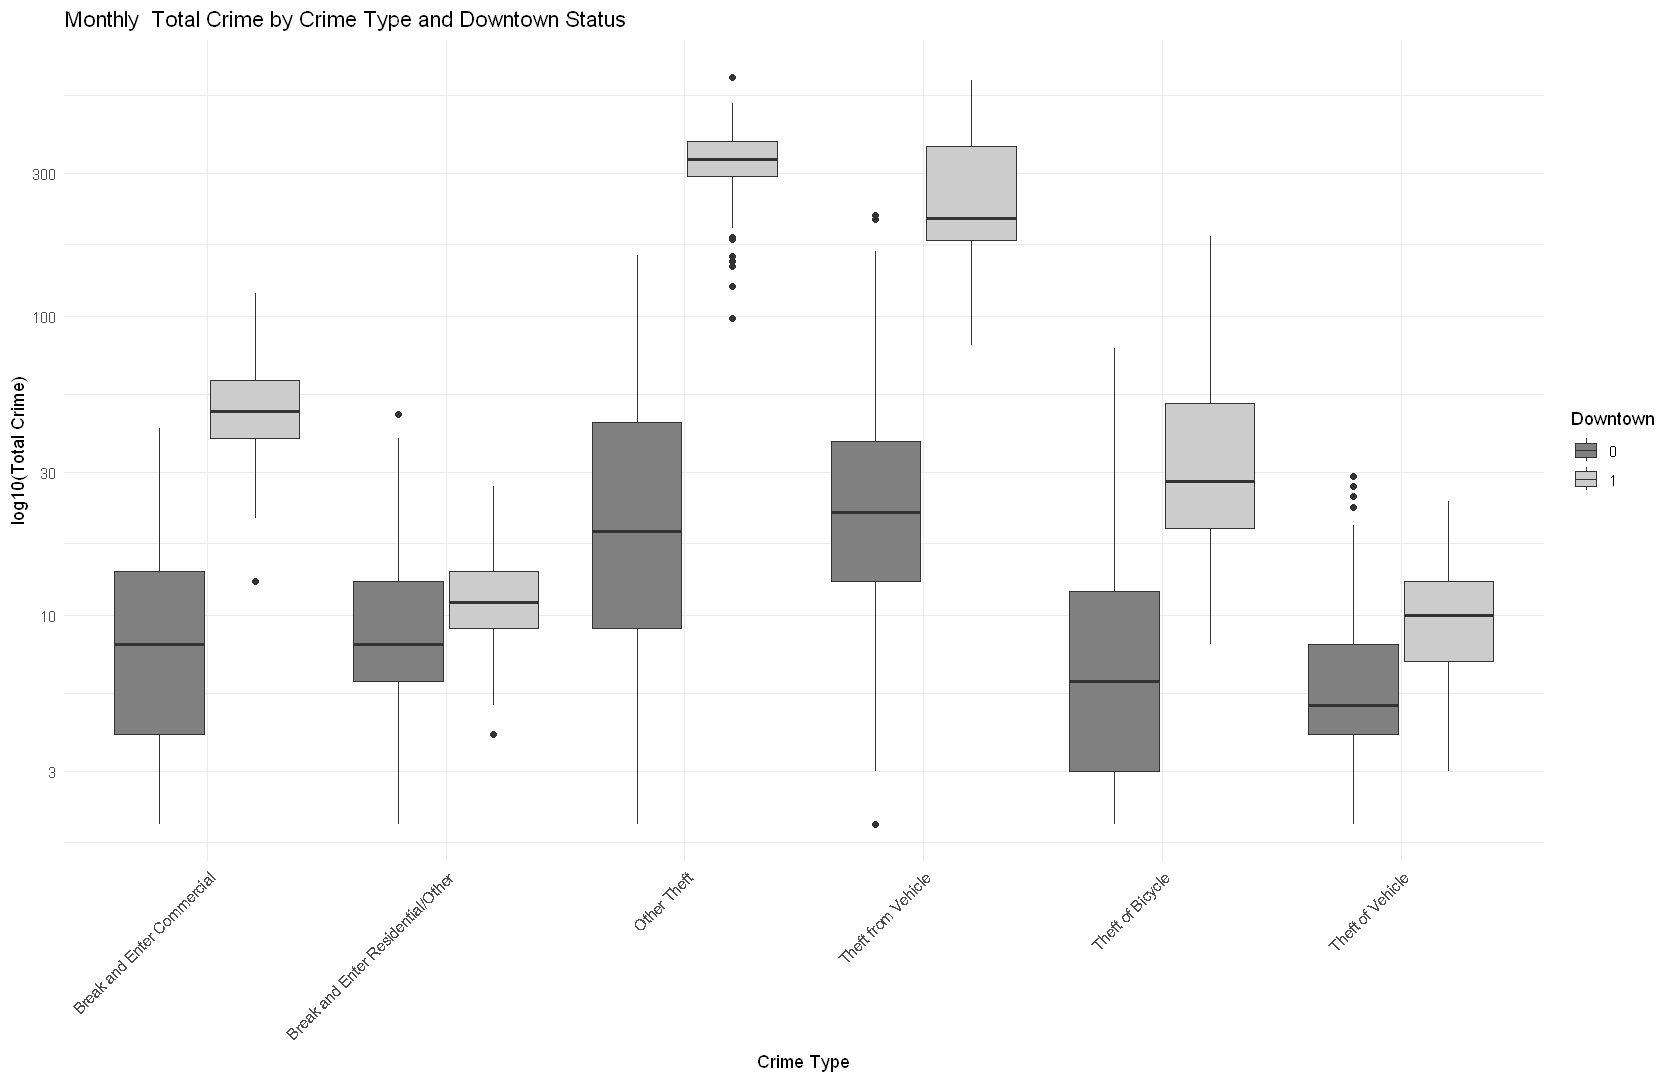

In [ ]:
combined_crime_data <- bind_rows(
  lapply(names(crime_panels), function(combine) {
    crime_panels[[combine]] %>% 
      mutate(crime_type = combine)
  })
)

combined_crime_data <- combined_crime_data %>%
  st_drop_geometry() %>%
  mutate(crime_total = crime_night + crime_day)

hetero_box_plot<- ggplot(combined_crime_data, 
                aes(x = crime_type, 
                    y = crime_total, 
                    fill = factor(is_downtown))) +
  scale_y_log10() +
  scale_fill_grey(start = 0.5, end = 0.8) + 
  geom_boxplot(position = position_dodge(width = 0.8)) +
  labs(
    title = "Monthly  Total Crime by Crime Type and Downtown Status",
    x     = "Crime Type",
    y     = "log10(Total Crime)",
    fill  = "Downtown"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

hetero_box_plot

`geom_smooth()` using formula = 'y ~ x'


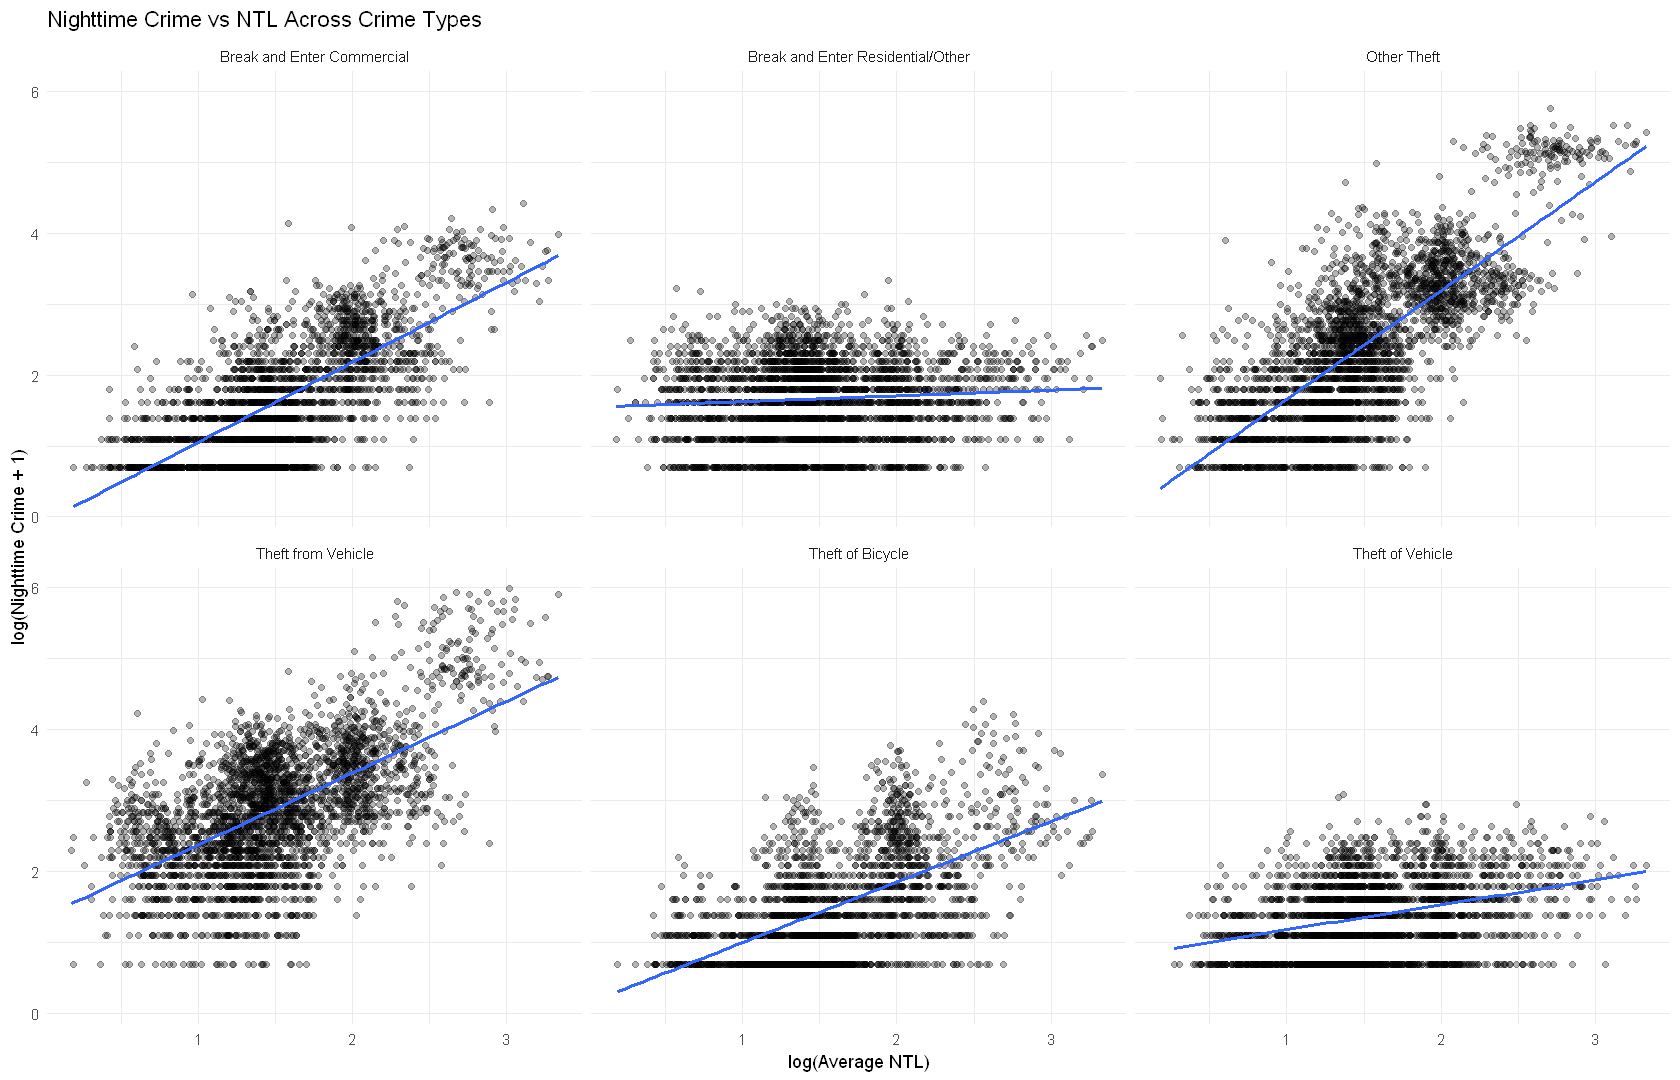

In [ ]:

hetero_scatter_plot <- ggplot(combined_crime_data, 
                    aes(x = log_ntl, 
                        y = log_crime_night)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~ crime_type) +
  labs(
    title = "Nighttime Crime vs NTL Across Crime Types",
    x     = "log(Average NTL)",
    y     = "log(Nighttime Crime + 1)"
  ) +
  theme_minimal()

hetero_scatter_plot

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


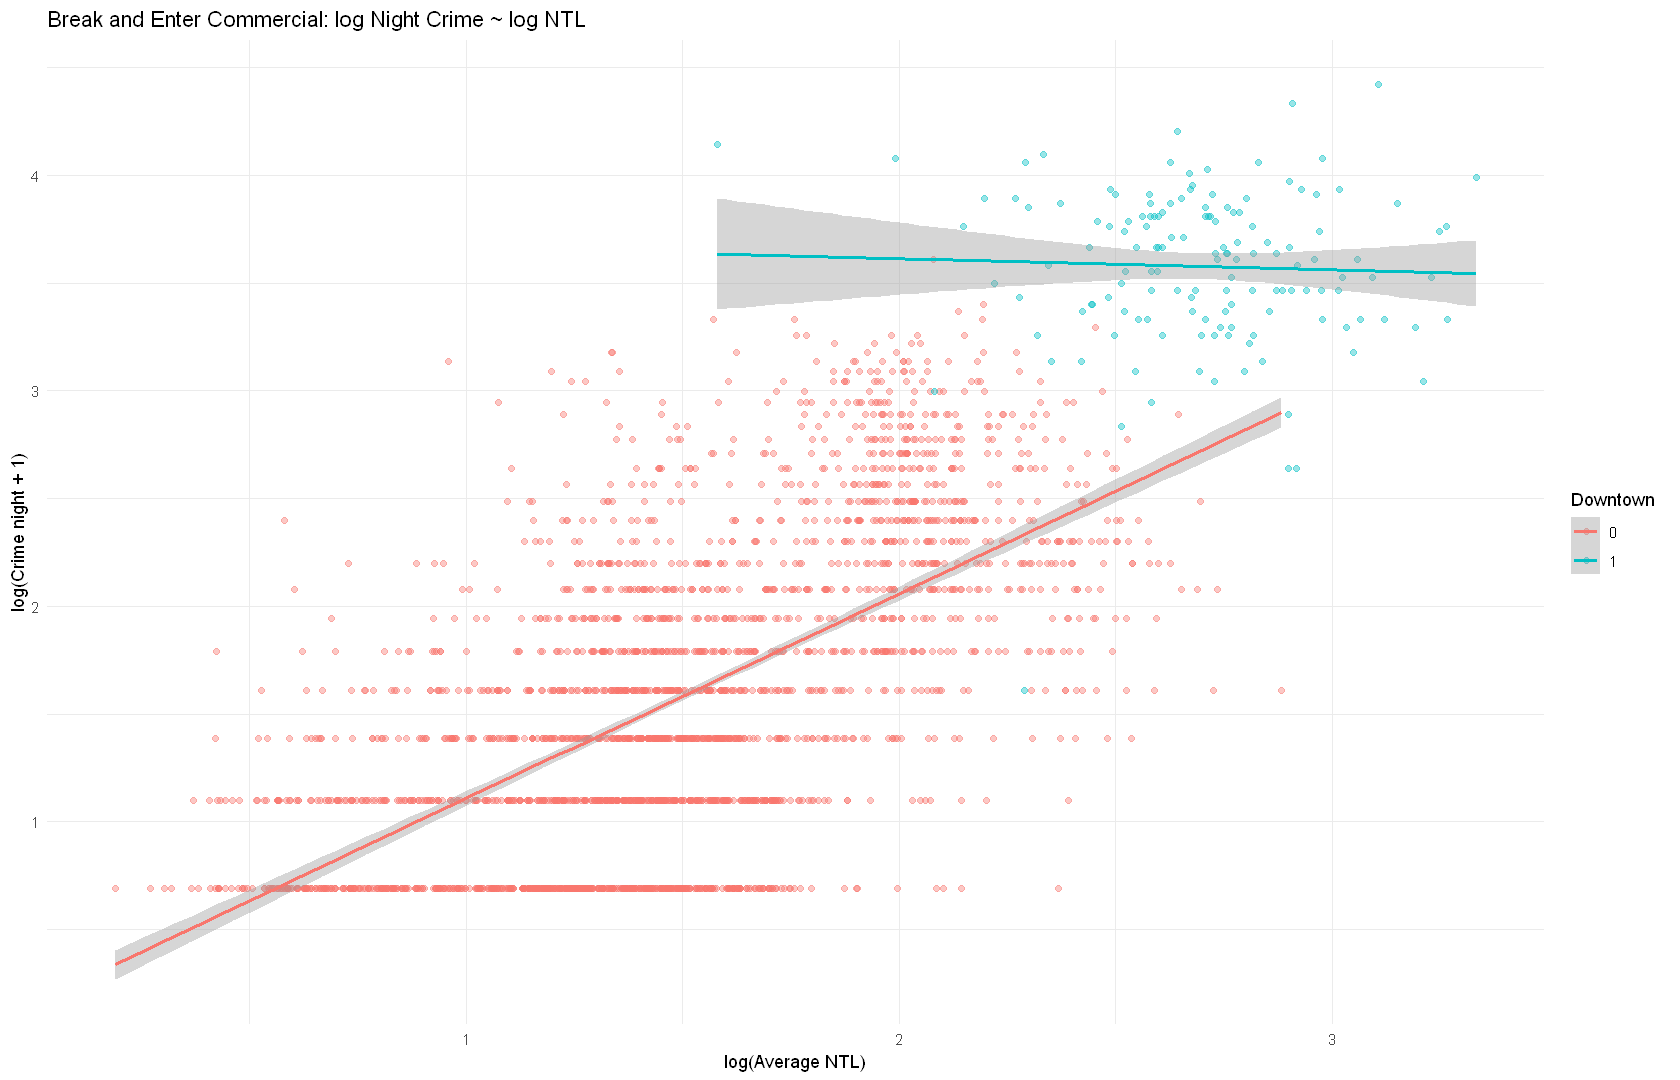

`geom_smooth()` using formula = 'y ~ x'


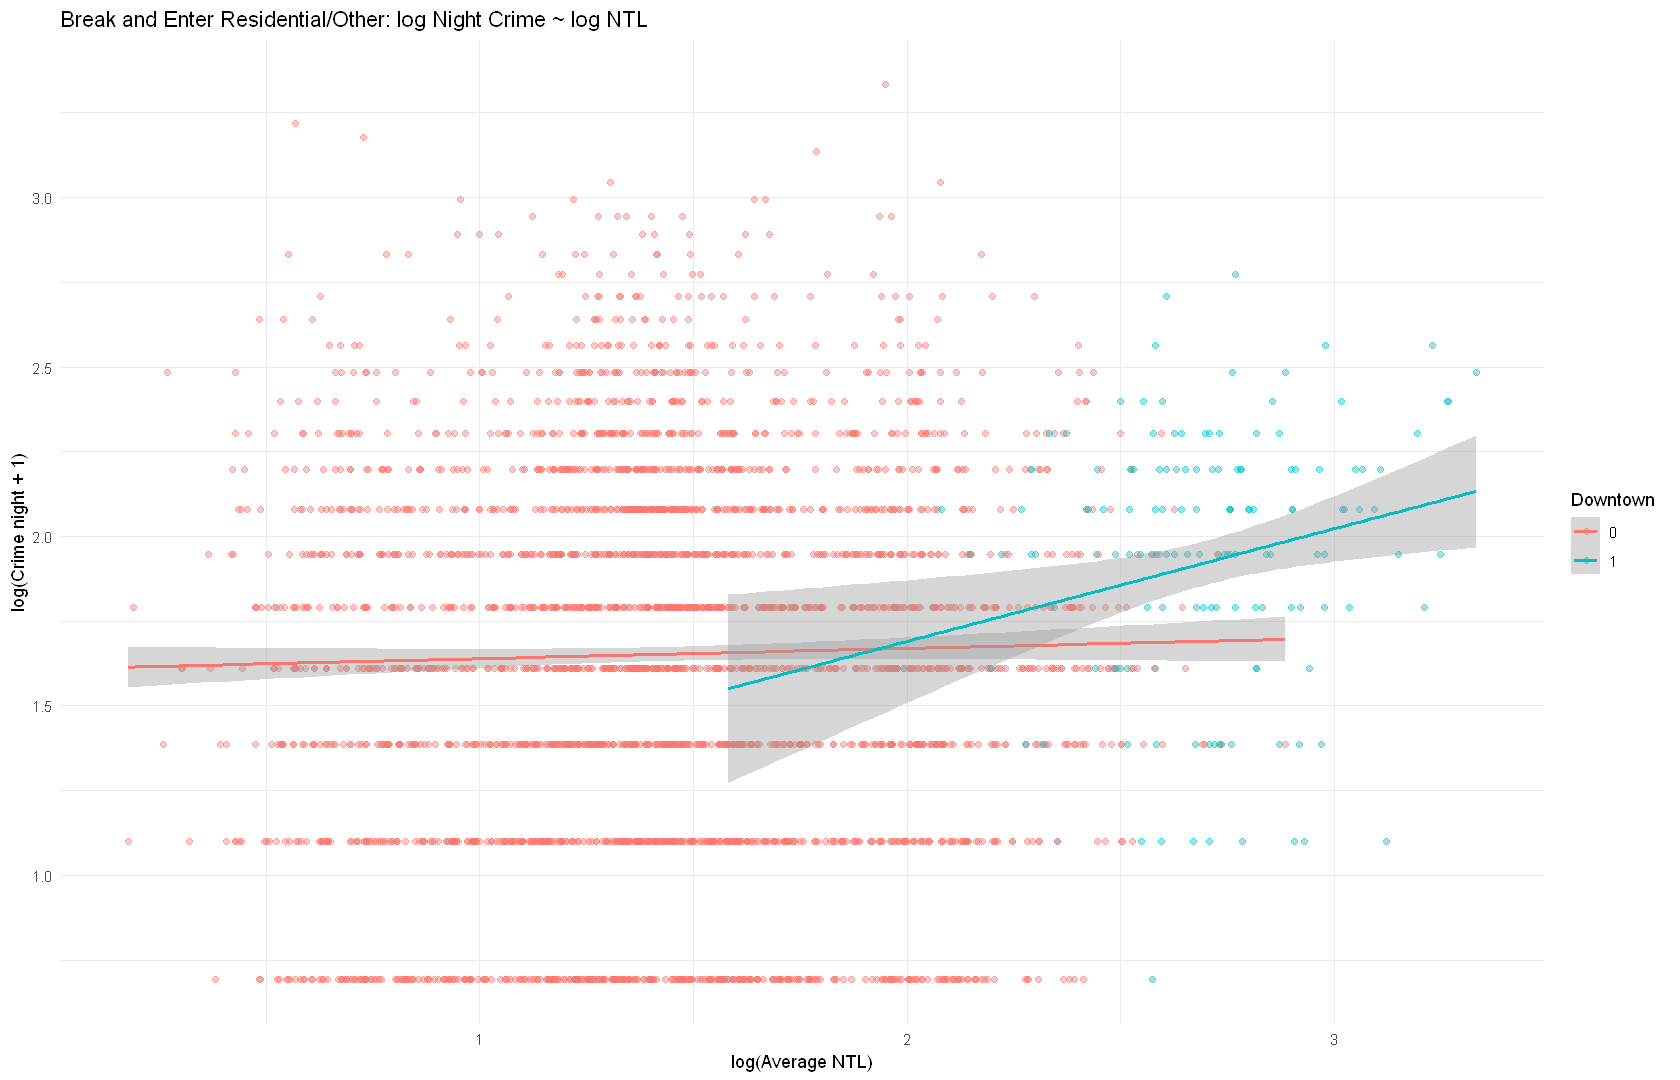

`geom_smooth()` using formula = 'y ~ x'


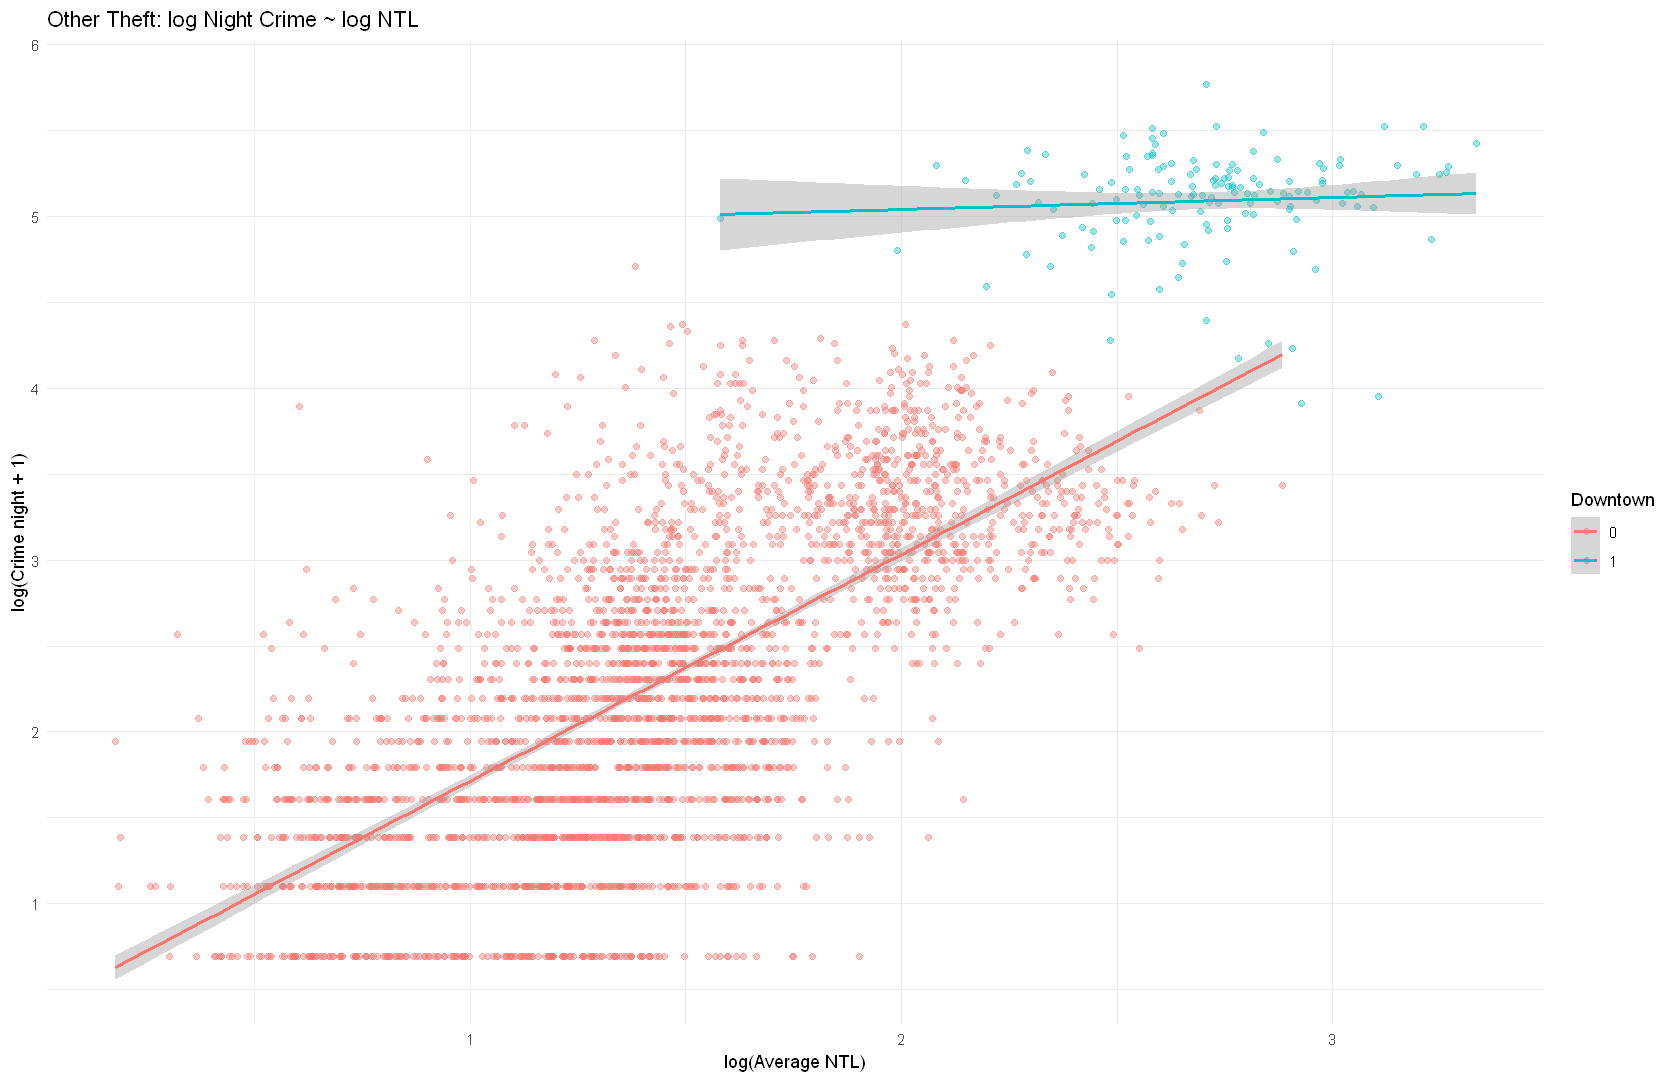

`geom_smooth()` using formula = 'y ~ x'


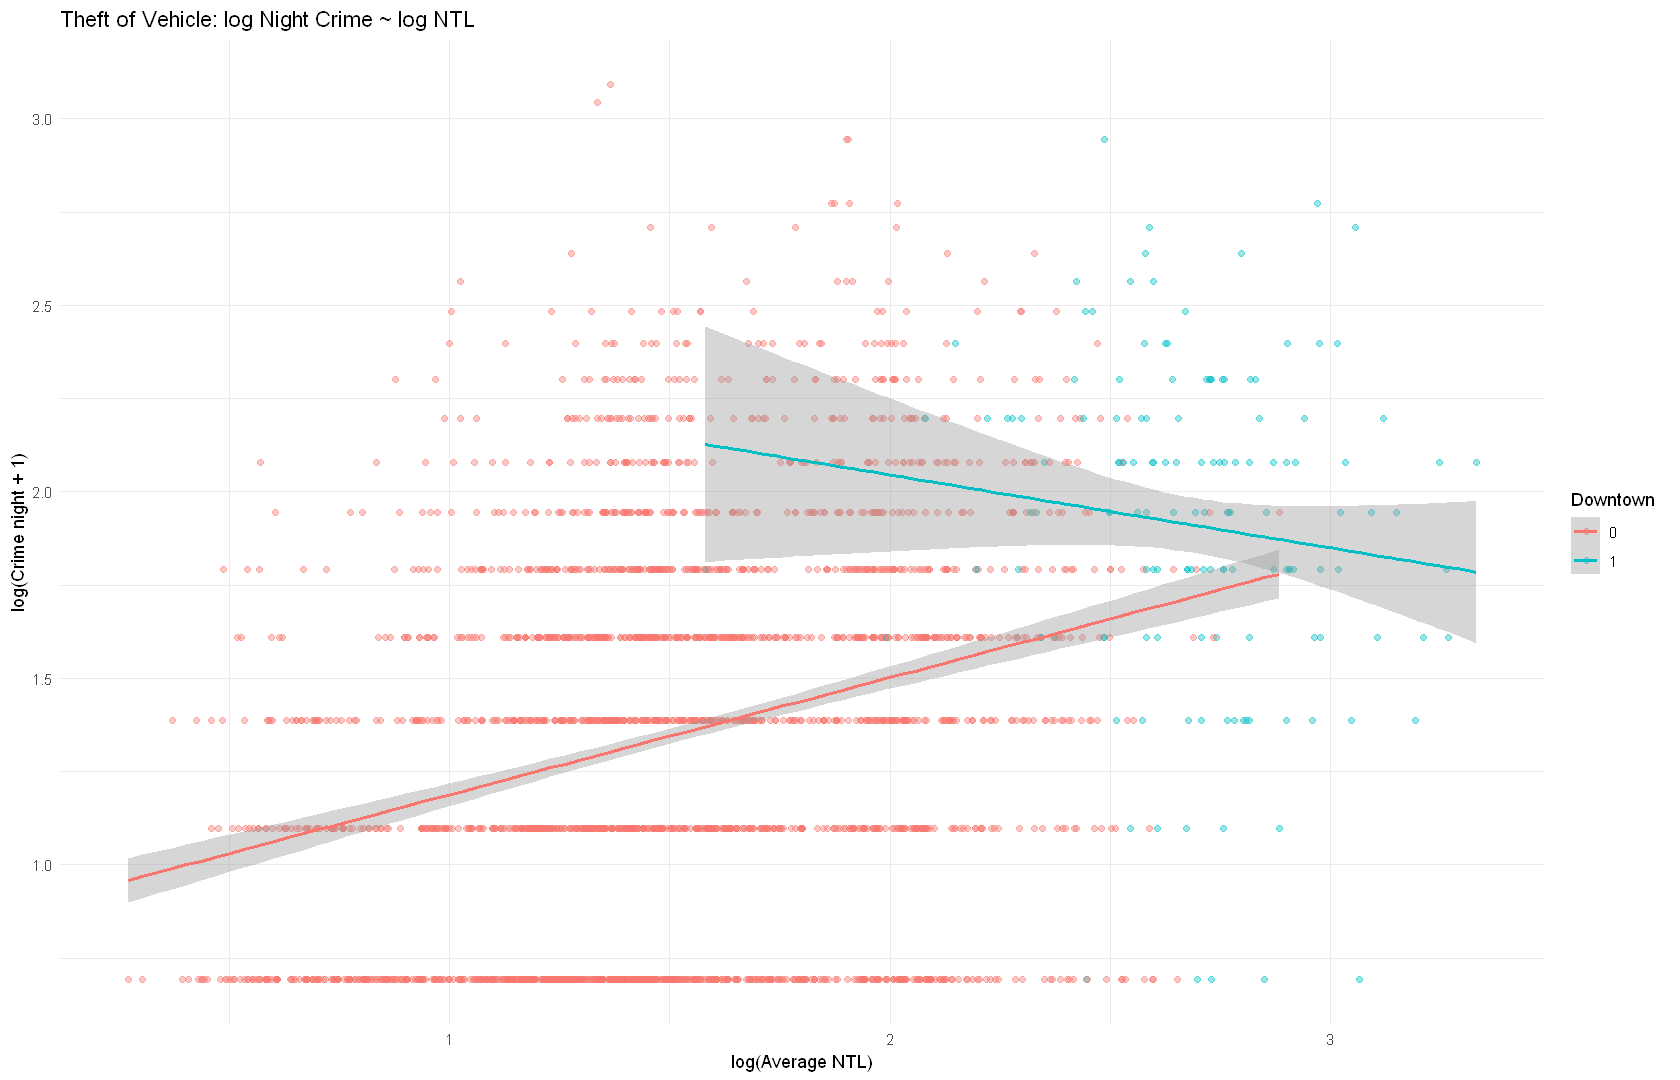

`geom_smooth()` using formula = 'y ~ x'


$`Break and Enter Commercial`

$`Break and Enter Residential/Other`

$`Other Theft`

$`Theft of Vehicle`

$`Theft of Bicycle`

$`Theft from Vehicle`


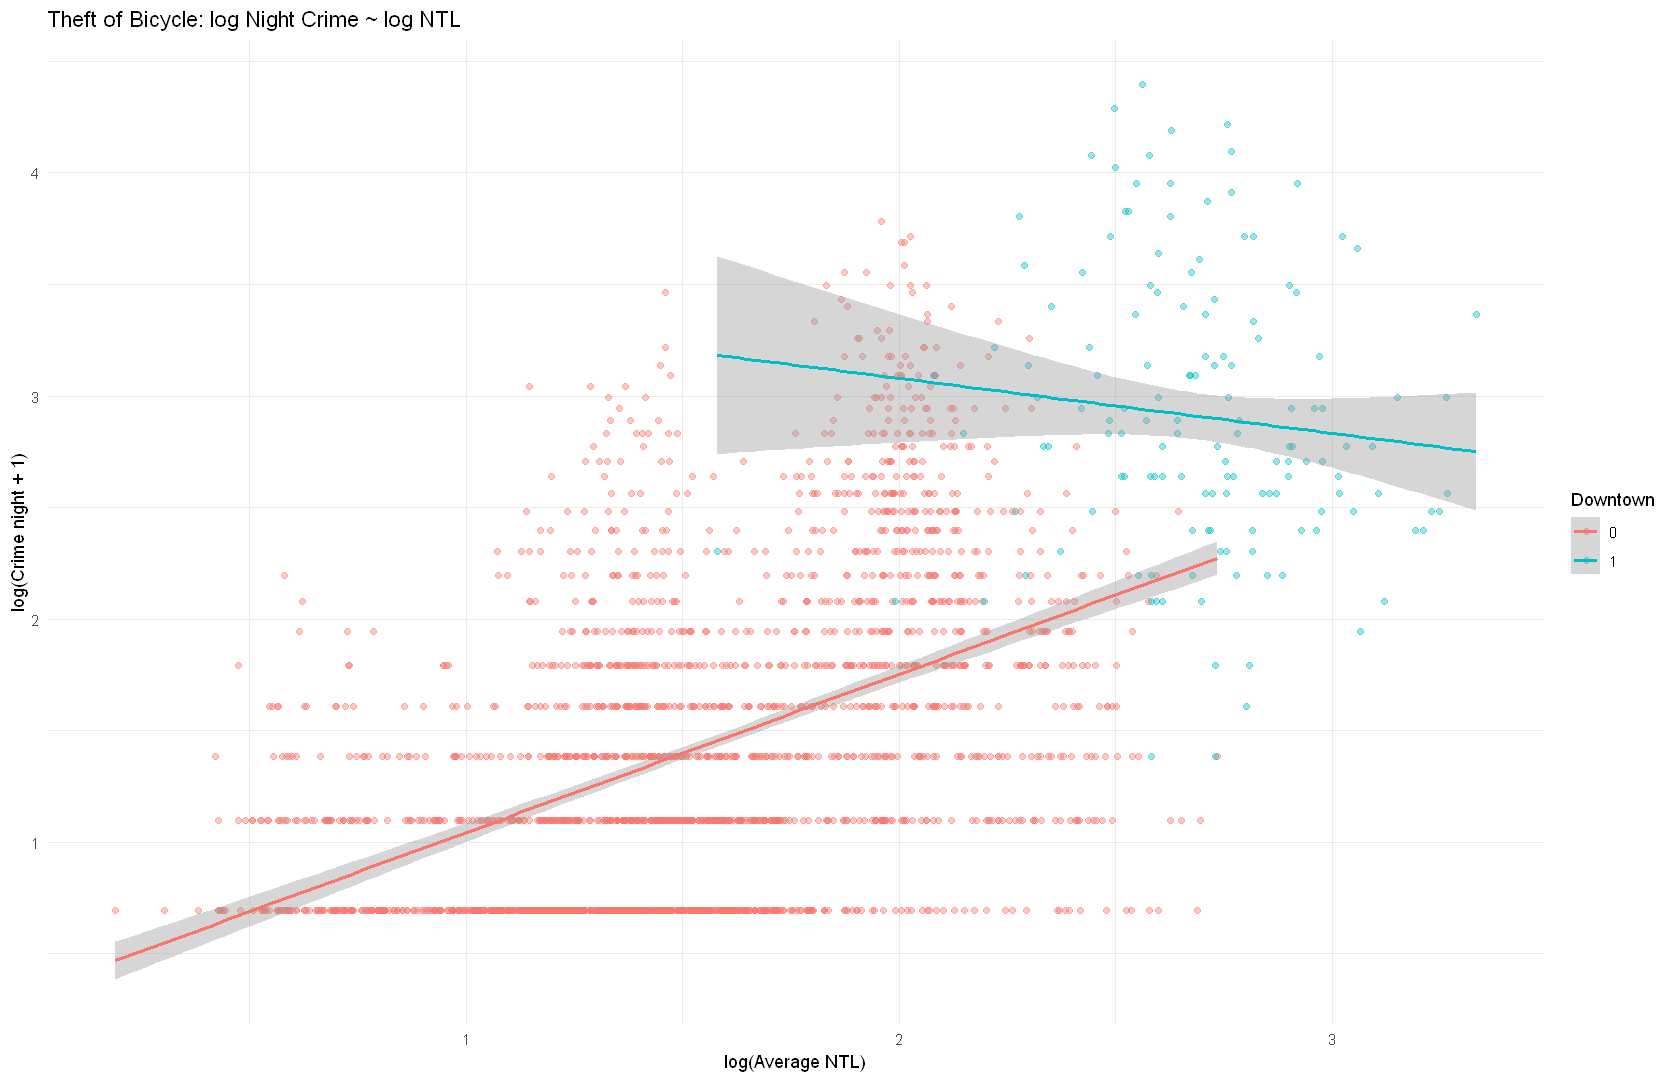

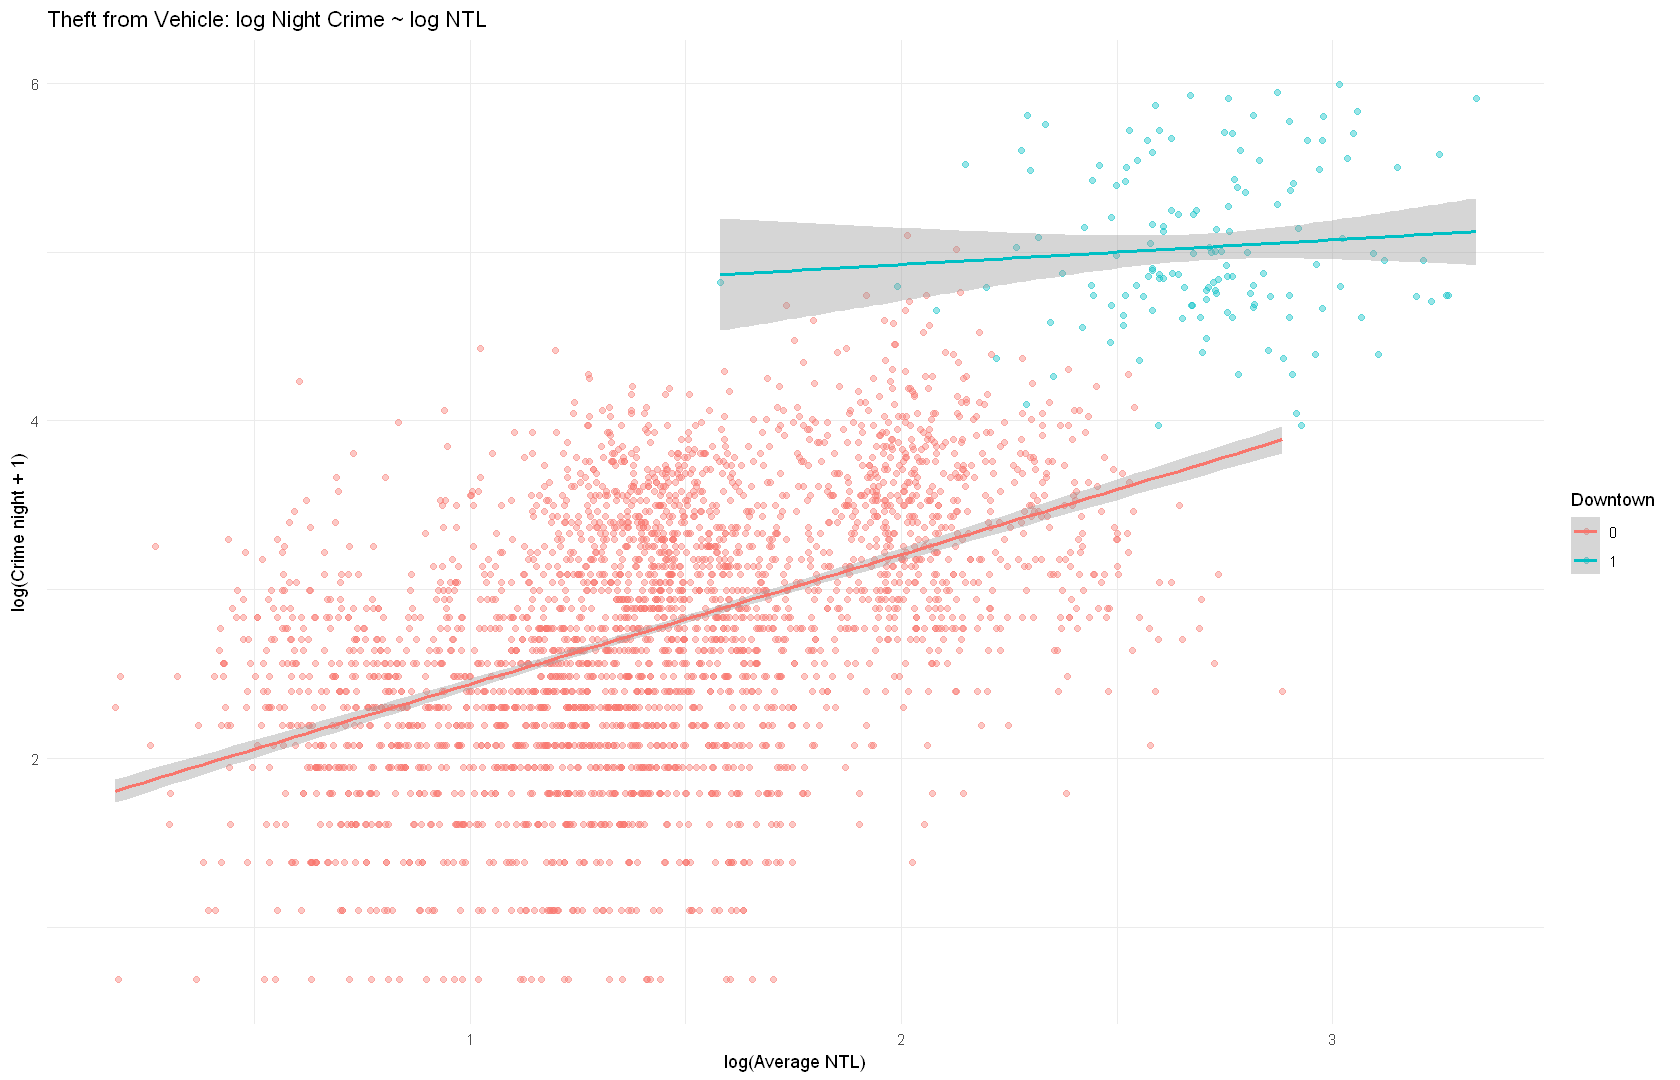

In [ ]:
scatter_plots <- lapply(names(panel_list), function(check) {
  df <- panel_list[[check]]
  
  ggplot(df, aes(x = log_ntl, y = log_crime_night,
                 color = factor(is_downtown))) +
    geom_point(alpha = 0.4) +
    geom_smooth(method = "lm", se = TRUE) +
    labs(
      title    = paste0(check, ": log Night Crime ~ log NTL"),
      x        = "log(Average NTL)",
      y        = "log(Crime night + 1)",
      color    = "Downtown"
    ) +
    theme_minimal()
})
names(scatter_plots) <- names(panel_list)

scatter_plots